# Comparación de modelos estadísticos y de Machine Learning para el pronóstico mensual del homicidio intencional en Colombia

**Tesis de Maestría en Ciencia de Datos**

Este notebook desarrolla un análisis exploratorio, el ajuste de modelos estadísticos clásicos (SARIMA, SARIMAX, VAR) y de modelos de aprendizaje automático (XGBoost, LightGBM, Random Forest, LSTM, GRU, Prophet) para pronosticar el número mensual de homicidios en Colombia, comparando su desempeño frente a los valores observados de enero-mayo de 2026.

**Estructura del notebook**

1. Análisis exploratorio de datos (dataset `db_delitos_norm.csv`)
2. Modelos estadísticos (dataset `ts_mensual_2005_2025.csv`)
3. Modelos de Machine Learning (datasets `ts_mensual_2005_2025.csv` y `ts_mensual_2026.csv`)
4. Comparación de modelos estadísticos y de Machine Learning

---

> ⚠️ **Nota metodológica importante — variables exógenas futuras.**
> Los modelos multivariados (SARIMAX, VAR, y los modelos de ML que usan variables exógenas) requieren valores de `INCAUTACION_KG`, `ISE`, `TASA DESEMPLEO`, `HURTO A PERSONAS`, `LESIONES PERSONALES` y `VIOLENCIA INTRAFAMILIAR` para el periodo de pronóstico (enero-mayo 2026). El dataset `ts_mensual_2026.csv` **solo** contiene el valor observado de `HOMICIDIOS` para verificar el pronóstico, no las exógenas futuras.
>
> Por defecto, este notebook usa el **método de "último valor observado"** (persistencia) para proyectar las exógenas durante el horizonte de pronóstico, dejándolo señalado explícitamente en cada tabla de resultados (columna `exog_metodo`). Si cuentas con proyecciones reales de esas variables para 2026 (p. ej. del DANE o Fedesarrollo), reemplázalas en la función `preparar_exogenas_futuras()` de la Sección 0 para obtener pronósticos más realistas.


## 0. Configuración del entorno

In [1]:

%matplotlib inline

# ---------------------------------------------------------------
# 0.1 Librerías
# ---------------------------------------------------------------
import os
import json
import warnings
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera

import xgboost as xgb
import lightgbm as lgb

import shap

from prophet import Prophet

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------------------------------------------
# 0.2 Estilo gráfico (Arial, paleta consistente)
# ---------------------------------------------------------------
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_style("whitegrid", {"font.family": "Arial"})

COLOR_HIST = "#2c3e50"
COLOR_FC = "#d62728"
COLOR_CI = "#d3d3d3"
COLOR_MAX = "#c0392b"
COLOR_MIN = "#2980b9"

PALETA_MODELOS = {
    "SARIMA(1,0,0)(2,1,2)[12]": "#1f77b4",
    "SARIMAX(1,0,0)(2,1,2)[12]": "#ff7f0e",
    "VAR HOMICIDIOS~ISE": "#2ca02c",
    "XGBoost": "#d62728",
    "LightGBM": "#9467bd",
    "Random Forest": "#8c564b",
    "LSTM": "#e377c2",
    "GRU": "#7f7f7f",
    "Prophet": "#bcbd22",
}

# ---------------------------------------------------------------
# 0.3 Rutas de archivos
# ---------------------------------------------------------------
RUTA_DATOS = Path(r"C:\Users\ASUS\OneDrive\Desktop\Maestria en Ciencia de datos\Monografia maestria\TS_model\Datos")
RUTA_RESULTADOS = Path(r"C:\Users\ASUS\OneDrive\Desktop\Maestria en Ciencia de datos\Monografia maestria\TS_model\Resultados")
RUTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

ARCHIVO_DELITOS = RUTA_DATOS / "db_delitos_norm.csv"
ARCHIVO_TS_HIST = RUTA_DATOS / "ts_mensual_2005_2025.csv"
ARCHIVO_TS_2026 = RUTA_DATOS / "ts_mensual_2026.csv"

# ---------------------------------------------------------------
# 0.4 Nombres de columnas (ajustar aquí si el CSV usa otros nombres)
# ---------------------------------------------------------------
COL_TEMATICA = "Temática"
COL_ANIO = "Año"
COL_MES = "Mes"
COL_GENERO = "Género"
COL_ZONA = "Zona"
COL_ARMAS = "Armas / Medios"
COL_CANTIDAD = "Cantidad"

MES_MAP = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}
MES_MAP_INV = {v: k for k, v in MES_MAP.items()}  # número -> nombre del mes en español


def formato_mes_es(fecha):
    """Evita depender del locale del sistema operativo (strftime('%B') suele salir en inglés en Windows)."""
    return f"{MES_MAP_INV[fecha.month]} {fecha.year}"

AÑO_INICIO = 2015
AÑO_FIN = 2025
HORIZONTE_PRONOSTICO = 5  # enero a mayo de 2026

# Diccionario global donde cada modelo guarda sus resultados para la Sección 4
resultados_modelos = {}


Importing plotly failed. Interactive plots will not work.


### 0.5 Carga de datasets

- `db_delitos_norm.csv`: delitos a nivel de caso/agregado municipal-mensual (dataset 1, EDA).
- `ts_mensual_2005_2025.csv`: serie mensual larga de indicadores 2005-2025 (dataset 2, modelos).
- `ts_mensual_2026.csv`: valores observados de homicidios enero-mayo 2026, usados como conjunto de prueba real (dataset 3).

In [2]:

# Dataset 1: delitos (para el EDA de la Sección 1)
db_delitos = pd.read_csv(ARCHIVO_DELITOS, sep=",", dtype=str, low_memory=False)
db_delitos[COL_ANIO] = pd.to_numeric(db_delitos[COL_ANIO], errors="coerce").astype("Int64")
db_delitos[COL_CANTIDAD] = pd.to_numeric(db_delitos[COL_CANTIDAD], errors="coerce")
db_delitos[COL_MES] = db_delitos[COL_MES].str.strip().str.title()
db_delitos["mes_num"] = db_delitos[COL_MES].map(MES_MAP)
db_delitos["fecha_mensual"] = pd.to_datetime(
    dict(year=db_delitos[COL_ANIO], month=db_delitos["mes_num"], day=1),
    errors="coerce"
)

print("db_delitos:", db_delitos.shape)
db_delitos.head()


db_delitos: (3785395, 20)


,Temática,Año,Mes,Departamento,Código Dane,Municipio,Armas / Medios,Agrupa Edad Persona,Género,Zona,Clase de Sitio,Día,Cantidad,armas_medios_raw,armas_medios_std,armas_medios_norm,genero_raw,genero_std,mes_num,fecha_mensual
0,HOMICIDIOS,2003,Enero,AMAZONAS,91001000,LETICIA (CT),ARMA BLANCA / CORTOPUNZANTE,JOVENES,MASCULINO,RURAL,CASAS DE HABITACION,mié.,1,ARMA BLANCA / CORTOPUNZANTE,ARMA BLANCA / CORTOPUNZANTE,ARMA BLANCA / CORTOPUNZANTE,MASCULINO,MASCULINO,1,2003-01-01
1,HOMICIDIOS,2003,Enero,ANTIOQUIA,05002000,ABEJORRAL,ARMA DE FUEGO,ADULTOS,MASCULINO,RURAL,FINCAS Y SIMILARES,mié.,1,ARMA DE FUEGO,ARMA DE FUEGO,ARMA DE FUEGO / TRAUMATICA,MASCULINO,MASCULINO,1,2003-01-01
2,HOMICIDIOS,2003,Enero,ANTIOQUIA,05002000,ABEJORRAL,ARMA DE FUEGO,ADULTOS,MASCULINO,RURAL,FINCAS Y SIMILARES,vie.,1,ARMA DE FUEGO,ARMA DE FUEGO,ARMA DE FUEGO / TRAUMATICA,MASCULINO,MASCULINO,1,2003-01-01
3,HOMICIDIOS,2003,Enero,ANTIOQUIA,05021000,ALEJANDRÍA,ARMA BLANCA / CORTOPUNZANTE,ADULTOS,MASCULINO,RURAL,RIOS,sáb.,1,ARMA BLANCA / CORTOPUNZANTE,ARMA BLANCA / CORTOPUNZANTE,ARMA BLANCA / CORTOPUNZANTE,MASCULINO,MASCULINO,1,2003-01-01
4,HOMICIDIOS,2003,Enero,ANTIOQUIA,05030000,AMAGÁ,ARMA DE FUEGO,ADULTOS,MASCULINO,RURAL,FINCAS Y SIMILARES,jue.,1,ARMA DE FUEGO,ARMA DE FUEGO,ARMA DE FUEGO / TRAUMATICA,MASCULINO,MASCULINO,1,2003-01-01


In [3]:

# Dataset 2: serie mensual larga 2005-2025 (para modelos estadísticos y de ML)
ts_hist_largo = pd.read_csv(ARCHIVO_TS_HIST, sep=",")
ts_hist_largo["fecha_mensual"] = pd.to_datetime(ts_hist_largo["fecha_mensual"], dayfirst=True)
ts_hist_largo["Cantidad"] = pd.to_numeric(ts_hist_largo["Cantidad"], errors="coerce")

# Pivot a formato ancho: una columna por Tematica/indicador
wide_hist = ts_hist_largo.pivot_table(
    index="fecha_mensual", columns="Tematica", values="Cantidad", aggfunc="sum"
).sort_index()
wide_hist = wide_hist.asfreq("MS")

print("ts_hist_largo:", ts_hist_largo.shape)
print("wide_hist:", wide_hist.shape, "->", list(wide_hist.columns))
print("Huecos (NaN) restantes por columna:")
print(wide_hist.isna().sum())
wide_hist.tail()


ts_hist_largo: (1764, 3)
wide_hist: (252, 7) -> ['HOMICIDIOS', 'HURTO A PERSONAS', 'INCAUTACION_KG', 'ISE', 'LESIONES PERSONALES', 'TASA DESEMPLEO', 'VIOLENCIA INTRAFAMILIAR']
Huecos (NaN) restantes por columna:
Tematica
HOMICIDIOS                 0
HURTO A PERSONAS           0
INCAUTACION_KG             0
ISE                        0
LESIONES PERSONALES        0
TASA DESEMPLEO             0
VIOLENCIA INTRAFAMILIAR    0
dtype: int64


Tematica,HOMICIDIOS,HURTO A PERSONAS,INCAUTACION_KG,ISE,LESIONES PERSONALES,TASA DESEMPLEO,VIOLENCIA INTRAFAMILIAR
fecha_mensual,,,,,,,
2025-08-01,1244.0,25256.0,78937.04,127.1,8242.0,8.60,14003.0
2025-09-01,1213.0,25479.0,63978.14,125.1,8371.0,8.17,14660.0
2025-10-01,1111.0,29340.0,60921.24,127.0,8497.0,8.20,13188.0
2025-11-01,1194.0,21378.0,53534.53,130.7,8236.0,7.02,11786.0
2025-12-01,1263.0,21467.0,34208.20,141.2,6927.0,7.98,6721.0


In [4]:

# Dataset 3: observado real enero-mayo 2026 (conjunto de prueba)
ts_2026 = pd.read_csv(ARCHIVO_TS_2026, sep=",")
ts_2026 = ts_2026.dropna(subset=["Tematica", "fecha_mensual"])  # quita la fila vacía final del CSV
ts_2026["fecha_mensual"] = pd.to_datetime(ts_2026["fecha_mensual"], format="%m/%d/%Y")  # este archivo viene en mes/día/año
ts_2026["Cantidad"] = pd.to_numeric(ts_2026["Cantidad"], errors="coerce")

y_test_2026 = (
    ts_2026[ts_2026["Tematica"] == "HOMICIDIOS"]
    .set_index("fecha_mensual")["Cantidad"]
    .sort_index()
)
print("Observado 2026 (HOMICIDIOS):")
y_test_2026


Observado 2026 (HOMICIDIOS):


fecha_mensual
2026-01-01    1203.0
2026-02-01    1083.0
2026-03-01    1170.0
2026-04-01    1156.0
2026-05-01    1188.0
Name: Cantidad, dtype: float64

### 0.6 Funciones auxiliares compartidas

Estas funciones se usan tanto en la Sección 2 (modelos estadísticos) como en la Sección 3 (modelos de Machine Learning), para evitar duplicar lógica: cálculo de métricas, evaluación de supuestos, construcción de tablas/gráficos de pronóstico y preparación de exógenas futuras.

In [5]:

# ---------------------------------------------------------------
# Métricas de desempeño (MAE, RMSE, MASE, ME, MAPE, R2)
# ---------------------------------------------------------------
def calcular_metricas(y_true, y_pred, y_train_hist=None, m=12):
    """
    Calcula MAE, RMSE, MASE, ME, MAPE y R2.
    y_train_hist: serie histórica de entrenamiento, usada como referencia
                  para el denominador de MASE (naive estacional de orden m).
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    error = y_true - y_pred
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    me = np.mean(error)
    mape = np.mean(np.abs(error / y_true)) * 100

    if y_train_hist is not None and len(y_train_hist) > m:
        y_train_hist = np.asarray(y_train_hist, dtype=float)
        denom_mase = np.mean(np.abs(y_train_hist[m:] - y_train_hist[:-m]))
        mase = mae / denom_mase if denom_mase > 0 else np.nan
    else:
        mase = np.nan

    # R2 con pocas observaciones (5 meses) es poco robusto, pero se reporta igual
    r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan

    return {
        "MAE": mae, "RMSE": rmse, "MASE": mase,
        "ME": me, "MAPE": mape, "R2": r2
    }


def tabla_metricas(dic_metricas, nombre_modelo):
    df = pd.DataFrame([dic_metricas])
    df.insert(0, "Modelo", nombre_modelo)
    return df.round(3)


# ---------------------------------------------------------------
# Evaluación de supuestos: Ljung-Box, Jarque-Bera, ARCH
# ---------------------------------------------------------------
def evaluar_supuestos(residuales, lags=12, alpha=0.05):
    """
    Evalúa independencia (Ljung-Box), normalidad (Jarque-Bera)
    y homocedasticidad (ARCH) de los residuales de un modelo.
    Retorna un dict con p-values y flags de si se cumple el supuesto (p > alpha).
    """
    residuales = np.asarray(pd.Series(residuales).dropna(), dtype=float)

    lb = acorr_ljungbox(residuales, lags=[lags], return_df=True)
    p_lb = float(lb["lb_pvalue"].iloc[0])

    jb_stat, jb_p, skew, kurt = jarque_bera(residuales)

    try:
        arch_stat, p_arch, _, _ = het_arch(residuales, nlags=lags)
    except Exception:
        p_arch = np.nan

    return {
        "p_ljung_box": p_lb,
        "independencia_ok": p_lb > alpha,
        "p_jarque_bera": float(jb_p),
        "normalidad_ok": float(jb_p) > alpha,
        "p_arch": p_arch,
        "homocedasticidad_ok": (p_arch > alpha) if not np.isnan(p_arch) else np.nan,
    }


def tabla_supuestos(dic_supuestos, nombre_modelo):
    df = pd.DataFrame([{
        "Modelo": nombre_modelo,
        "p (Ljung-Box)": dic_supuestos["p_ljung_box"],
        "Independencia": "SÍ" if dic_supuestos["independencia_ok"] else "NO",
        "p (Jarque-Bera)": dic_supuestos["p_jarque_bera"],
        "Normalidad": "SÍ" if dic_supuestos["normalidad_ok"] else "NO",
        "p (ARCH)": dic_supuestos["p_arch"],
        "Homocedasticidad": "SÍ" if dic_supuestos["homocedasticidad_ok"] else ("NO" if dic_supuestos["homocedasticidad_ok"] is False else "N/A"),
    }])
    return df.round(4)


# ---------------------------------------------------------------
# Preparación de exógenas futuras (ver nota metodológica en la portada)
# ---------------------------------------------------------------
def preparar_exogenas_futuras(wide_df, exog_vars, fechas_futuras, metodo="ultimo_valor",
                               valores_manuales=None):
    """
    Construye un DataFrame con las variables exógenas proyectadas para el
    horizonte de pronóstico.

    metodo:
      - "ultimo_valor": se repite el último valor observado (persistencia). Es el
        valor por defecto porque no se cuenta con proyecciones reales de estas
        variables para 2026 en los datasets suministrados.
      - "manual": se usan los valores entregados en `valores_manuales`
        (dict {variable: lista de valores en el mismo orden que fechas_futuras}).
    """
    fut = pd.DataFrame(index=fechas_futuras, columns=exog_vars, dtype=float)

    if metodo == "manual" and valores_manuales is not None:
        for var in exog_vars:
            fut[var] = valores_manuales[var]
    else:
        metodo = "ultimo_valor"
        for var in exog_vars:
            fut[var] = wide_df[var].dropna().iloc[-1]

    fut["exog_metodo"] = metodo
    return fut


# ---------------------------------------------------------------
# Tabla y gráfico de pronóstico (usados por todos los modelos)
# ---------------------------------------------------------------
def tabla_pronostico(fechas, punto, lo95, hi95, nombre_modelo):
    df = pd.DataFrame({
        "Modelo": nombre_modelo,
        "fecha_mensual": fechas,
        "pronostico": np.round(punto, 1),
        "lim_inf_95": np.round(lo95, 1),
        "lim_sup_95": np.round(hi95, 1),
    })
    return df


def graficar_pronostico(serie_hist, fechas_fc, punto_fc, lo_fc, hi_fc,
                         titulo, n_meses_hist=36, color_fc=COLOR_FC):
    hist_plot = serie_hist.dropna().iloc[-n_meses_hist:]

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(hist_plot.index, hist_plot.values, color=COLOR_HIST,
            linewidth=1.4, label="Histórico")
    ax.plot(fechas_fc, punto_fc, color=color_fc, linewidth=1.8,
            marker="o", label="Pronóstico")
    ax.fill_between(fechas_fc, lo_fc, hi_fc, color=COLOR_CI, alpha=0.6,
                     label="IC 95%")

    ax.set_title(titulo)
    ax.set_xlabel("Fecha mensual")
    ax.set_ylabel("Homicidios (casos)")
    ax.legend(loc="best")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
    fig.tight_layout()
    return fig


def graficar_comparacion_modelos(serie_hist, dict_pronosticos, titulo, n_meses_hist=36):
    """
    dict_pronosticos: {nombre_modelo: (fechas, punto)}
    """
    hist_plot = serie_hist.dropna().iloc[-n_meses_hist:]

    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.plot(hist_plot.index, hist_plot.values, color=COLOR_HIST,
            linewidth=1.6, label="Histórico (2015-2025)")

    for nombre, (fechas, punto) in dict_pronosticos.items():
        color = PALETA_MODELOS.get(nombre, None)
        ax.plot(fechas, punto, marker="o", linewidth=1.6, label=nombre, color=color)

    ax.set_title(titulo)
    ax.set_xlabel("Fecha mensual")
    ax.set_ylabel("Homicidios (casos)")
    ax.legend(loc="best", fontsize=8, ncol=2)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
    fig.tight_layout()
    return fig


## 1. Análisis exploratorio de datos

Se usa el dataset `db_delitos_norm.csv`, filtrado a la temática **HOMICIDIOS** y al periodo **2015-2025**.

In [6]:

db_hom = db_delitos[
    (db_delitos[COL_TEMATICA] == "HOMICIDIOS") &
    (db_delitos[COL_ANIO] >= AÑO_INICIO) &
    (db_delitos[COL_ANIO] <= AÑO_FIN)
].copy()

print("Registros HOMICIDIOS 2015-2025:", len(db_hom))
print("Total casos:", db_hom[COL_CANTIDAD].sum())


Registros HOMICIDIOS 2015-2025: 110381
Total casos: 141774


### 1.1 Serie mensual de homicidios (2015-2025)

Gráfico de línea con la serie mensual de homicidios. Se etiquetan los **5 puntos más altos** y los **5 puntos más bajos** de la serie con la cantidad, el mes y el año correspondientes.

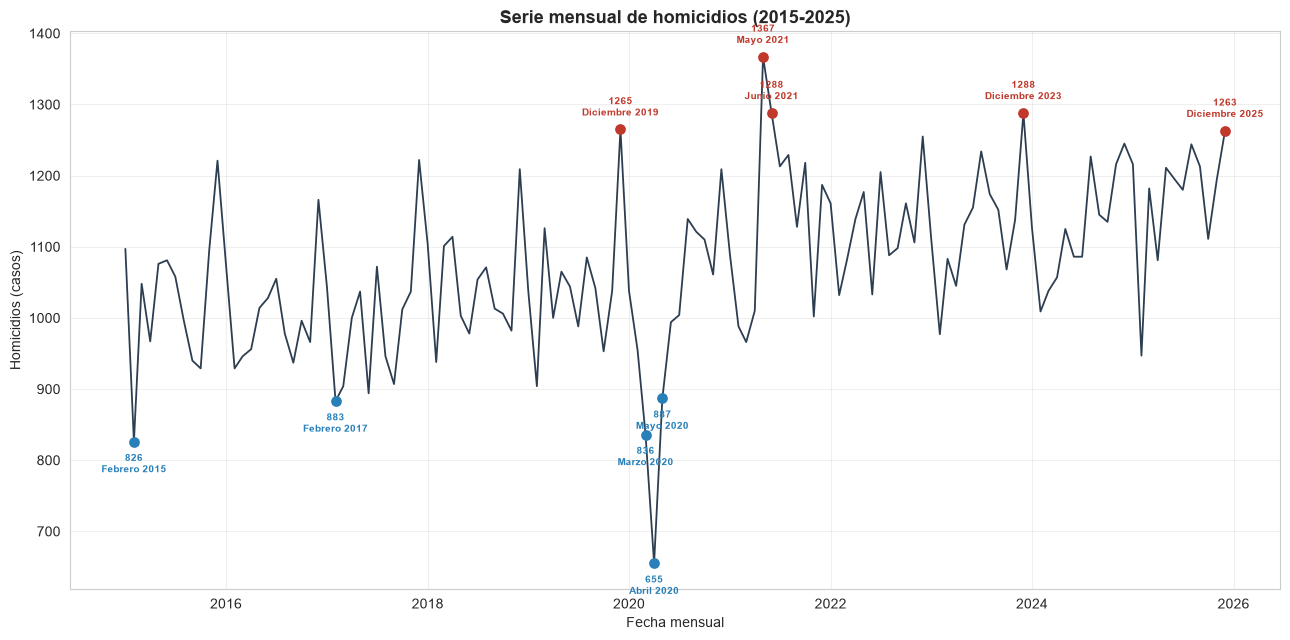

In [7]:

serie_mensual_hom = (
    db_hom.groupby("fecha_mensual", as_index=True)[COL_CANTIDAD]
    .sum()
    .sort_index()
    .asfreq("MS")
)

df_serie = serie_mensual_hom.reset_index()
df_serie.columns = ["fecha_mensual", "Cantidad"]
df_serie["Mes"] = df_serie["fecha_mensual"].dt.month.map(MES_MAP_INV)
df_serie["Año"] = df_serie["fecha_mensual"].dt.year

top5 = df_serie.nlargest(5, "Cantidad")
bottom5 = df_serie.nsmallest(5, "Cantidad")

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.plot(df_serie["fecha_mensual"], df_serie["Cantidad"], color=COLOR_HIST, linewidth=1.3)

ax.scatter(top5["fecha_mensual"], top5["Cantidad"], color=COLOR_MAX, zorder=5, s=45)
ax.scatter(bottom5["fecha_mensual"], bottom5["Cantidad"], color=COLOR_MIN, zorder=5, s=45)

rango_y = df_serie["Cantidad"].max() - df_serie["Cantidad"].min()

for _, row in top5.iterrows():
    etiqueta = f'{int(row["Cantidad"])}\n{row["Mes"]} {row["Año"]}'
    ax.annotate(etiqueta, (row["fecha_mensual"], row["Cantidad"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=7.5, fontweight="bold", color=COLOR_MAX)

for _, row in bottom5.iterrows():
    etiqueta = f'{int(row["Cantidad"])}\n{row["Mes"]} {row["Año"]}'
    ax.annotate(etiqueta, (row["fecha_mensual"], row["Cantidad"]),
                textcoords="offset points", xytext=(0, -22),
                ha="center", fontsize=7.5, fontweight="bold", color=COLOR_MIN)

ax.set_title(f"Serie mensual de homicidios ({AÑO_INICIO}-{AÑO_FIN})")
ax.set_xlabel("Fecha mensual")
ax.set_ylabel("Homicidios (casos)")
fig.tight_layout()
plt.savefig(RUTA_RESULTADOS / "fig_1_1_serie_mensual_homicidios.png", dpi=150)
plt.show()


*Interpretación (1.1):* la serie mensual de homicidios entre 2015 y 2025 muestra la evolución del fenómeno a nivel nacional, con los meses de mayor y menor incidencia señalados directamente sobre el gráfico. Los picos más altos permiten identificar periodos de recrudecimiento de la violencia homicida —útiles para contrastar con eventos coyunturales (económicos, de orden público o estacionales)—, mientras que los valles señalan los meses de menor incidencia registrada en la serie, que sirven como referencia para evaluar la magnitud de las fluctuaciones y la posible presencia de estacionalidad o de una tendencia de largo plazo que los modelos de las secciones siguientes deberán capturar.

### 1.2 Homicidios por género (2015-2025)

Gráfico de pie con el porcentaje y la cantidad de homicidios para las categorías **Masculino** y **Femenino** (se excluye "No reportado").

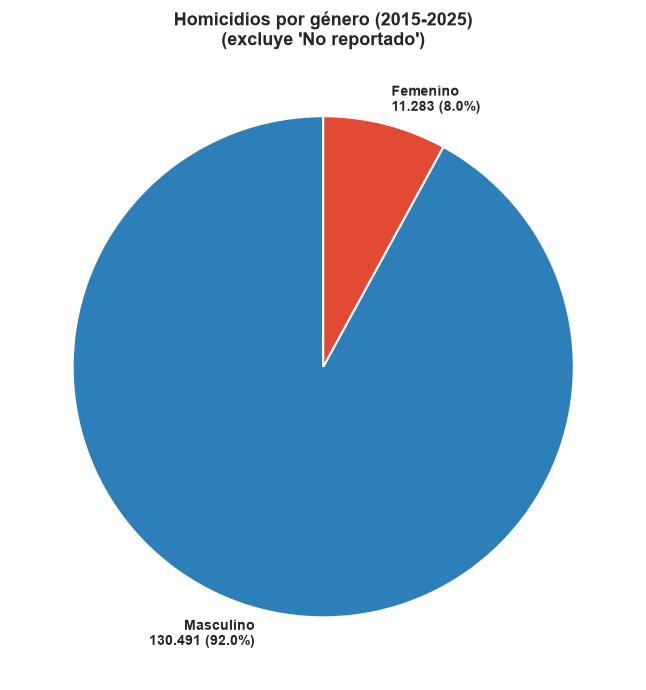

In [8]:

genero_hom = (
    db_hom[db_hom[COL_GENERO].str.upper().isin(["MASCULINO", "FEMENINO"])]
    .groupby(db_hom[COL_GENERO].str.upper())[COL_CANTIDAD]
    .sum()
    .sort_values(ascending=False)
)

etiquetas_pct = [
    f"{cat.title()}\n{val:,.0f} ({val / genero_hom.sum() * 100:.1f}%)".replace(",", ".")
    for cat, val in genero_hom.items()
]

fig, ax = plt.subplots(figsize=(7, 7))
colores_genero = ["#2c7fb8", "#e34a33"]
ax.pie(
    genero_hom.values,
    labels=etiquetas_pct,
    colors=colores_genero,
    autopct=None,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 10, "fontweight": "bold"}
)
ax.set_title(f"Homicidios por género ({AÑO_INICIO}-{AÑO_FIN})\n(excluye 'No reportado')")
fig.tight_layout()
plt.savefig(RUTA_RESULTADOS / "fig_1_2_genero_homicidios.png", dpi=150)
plt.show()


*Interpretación (1.2):* la distribución de homicidios por género evidencia una marcada disparidad entre hombres y mujeres como víctimas, un patrón consistente con la literatura criminológica sobre violencia letal en América Latina. Esta brecha sugiere que los factores de riesgo y los contextos en los que ocurre el homicidio afectan de forma muy distinta a cada grupo, lo que resulta relevante para el diseño de estrategias de prevención diferenciadas.

### 1.3 Homicidios por zona (2015-2025)

Gráfico de barras horizontales con el porcentaje y la cantidad de homicidios para las categorías **Urbana** y **Rural** (se excluye "Otras").

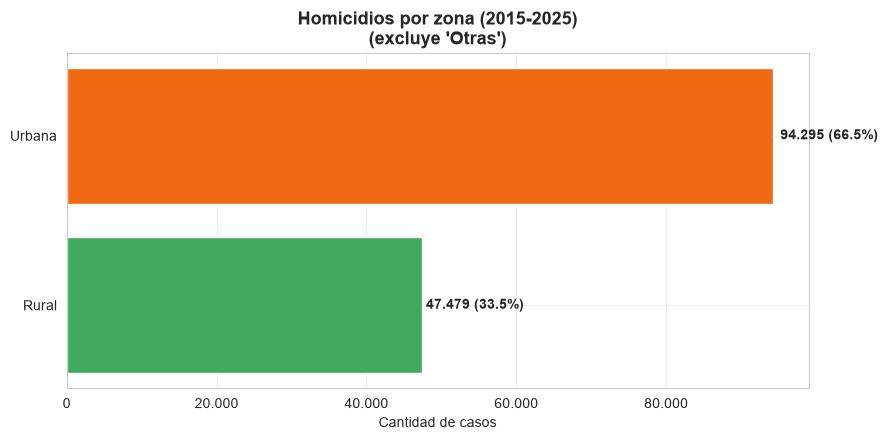

In [9]:

zona_hom = (
    db_hom[db_hom[COL_ZONA].str.upper().isin(["URBANA", "RURAL"])]
    .groupby(db_hom[COL_ZONA].str.upper())[COL_CANTIDAD]
    .sum()
    .sort_values()
)
zona_pct = 100 * zona_hom / zona_hom.sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.barh(zona_hom.index.str.title(), zona_hom.values, color=["#41ab5d", "#f16913"])

for barra, cant, pct in zip(barras, zona_hom.values, zona_pct.values):
    ax.text(barra.get_width() * 1.01, barra.get_y() + barra.get_height() / 2,
            f"{cant:,.0f} ({pct:.1f}%)".replace(",", "."),
            va="center", fontsize=10, fontweight="bold")

ax.set_title(f"Homicidios por zona ({AÑO_INICIO}-{AÑO_FIN})\n(excluye 'Otras')")
ax.set_xlabel("Cantidad de casos")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
fig.tight_layout()
plt.savefig(RUTA_RESULTADOS / "fig_1_3_zona_homicidios.png", dpi=150)
plt.show()


*Interpretación (1.3):* la comparación entre zona urbana y rural permite dimensionar en qué entorno se concentra el homicidio en Colombia entre 2015 y 2025. Este resultado es clave para orientar el enfoque territorial de las políticas de seguridad y para interpretar con cautela los modelos de pronóstico agregados a nivel nacional, que no distinguen entre estas dos dinámicas territoriales potencialmente distintas.

### 1.4 Homicidios por armas/medios (2015-2025)

Gráfico de barras verticales con el porcentaje y la cantidad de homicidios para todas las categorías de **Armas/Medios**.

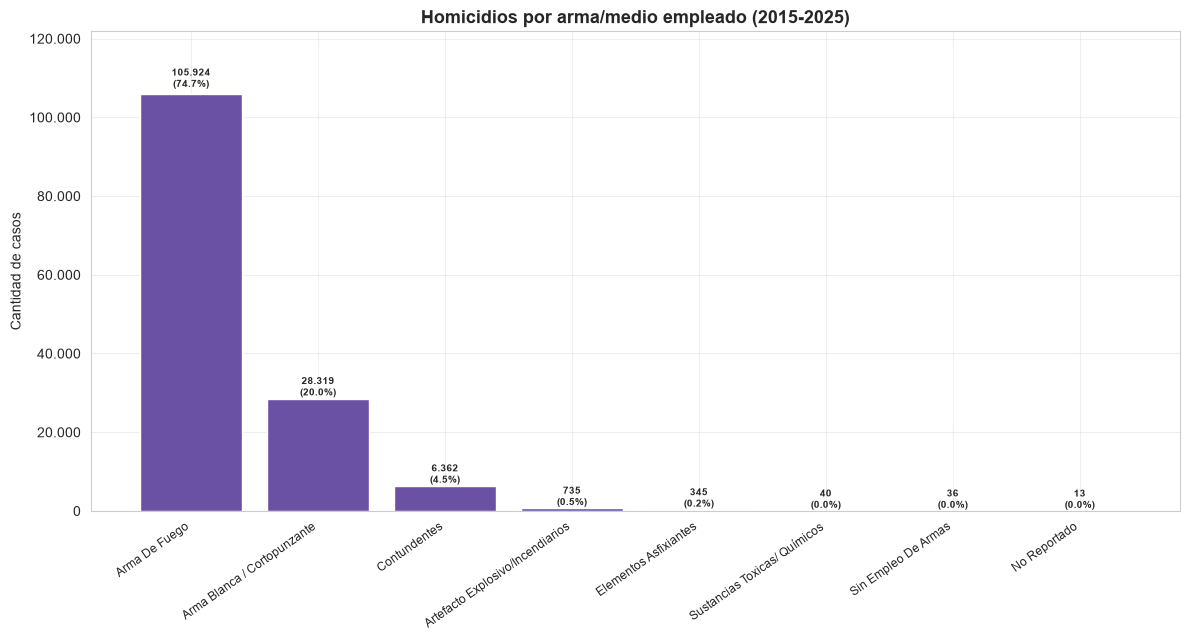

In [10]:

armas_hom = (
    db_hom.groupby(db_hom[COL_ARMAS].str.upper().str.strip())[COL_CANTIDAD]
    .sum()
    .sort_values(ascending=False)
)
armas_pct = 100 * armas_hom / armas_hom.sum()

fig, ax = plt.subplots(figsize=(12, 6.5))
barras = ax.bar(range(len(armas_hom)), armas_hom.values, color="#6a51a3")

for i, (cant, pct) in enumerate(zip(armas_hom.values, armas_pct.values)):
    ax.text(i, cant * 1.01, f"{cant:,.0f}\n({pct:.1f}%)".replace(",", "."),
            ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_xticks(range(len(armas_hom)))
ax.set_xticklabels([c.title() for c in armas_hom.index], rotation=35, ha="right", fontsize=8.5)
ax.set_title(f"Homicidios por arma/medio empleado ({AÑO_INICIO}-{AÑO_FIN})")
ax.set_ylabel("Cantidad de casos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
ax.margins(y=0.15)
fig.tight_layout()
plt.savefig(RUTA_RESULTADOS / "fig_1_4_armas_homicidios.png", dpi=150)
plt.show()


*Interpretación (1.4):* la distribución por arma/medio empleado evidencia cuál es el mecanismo predominante en la comisión del homicidio en Colombia, lo que suele estar asociado con el tipo de criminalidad (organizada, interpersonal, etc.) detrás de cada caso. Esta información es un insumo relevante para contrastar los resultados de los modelos de pronóstico con hipótesis sobre los determinantes estructurales de la violencia homicida, más allá de su comportamiento puramente temporal.

## 2. Modelos estadísticos

Se usa el dataset `ts_mensual_2005_2025.csv` (formato ancho `wide_hist`), restringido a 2015-2025 para el entrenamiento, y `ts_mensual_2026.csv` (enero-mayo de 2026) como conjunto de prueba real.

In [11]:

y_full = wide_hist.loc[f"{AÑO_INICIO}-01-01":f"{AÑO_FIN}-12-01", "HOMICIDIOS"].astype(float)
y_full = y_full.asfreq("MS")

fechas_fc = pd.date_range("2026-01-01", periods=HORIZONTE_PRONOSTICO, freq="MS")

print("Serie de entrenamiento HOMICIDIOS:", y_full.index.min(), "->", y_full.index.max(), f"(n={len(y_full)})")
print("Horizonte de pronóstico:", fechas_fc.min(), "->", fechas_fc.max())


Serie de entrenamiento HOMICIDIOS: 2015-01-01 00:00:00 -> 2025-12-01 00:00:00 (n=132)
Horizonte de pronóstico: 2026-01-01 00:00:00 -> 2026-05-01 00:00:00


### 2.1 Descomposición de la serie de homicidios (2015-2025)

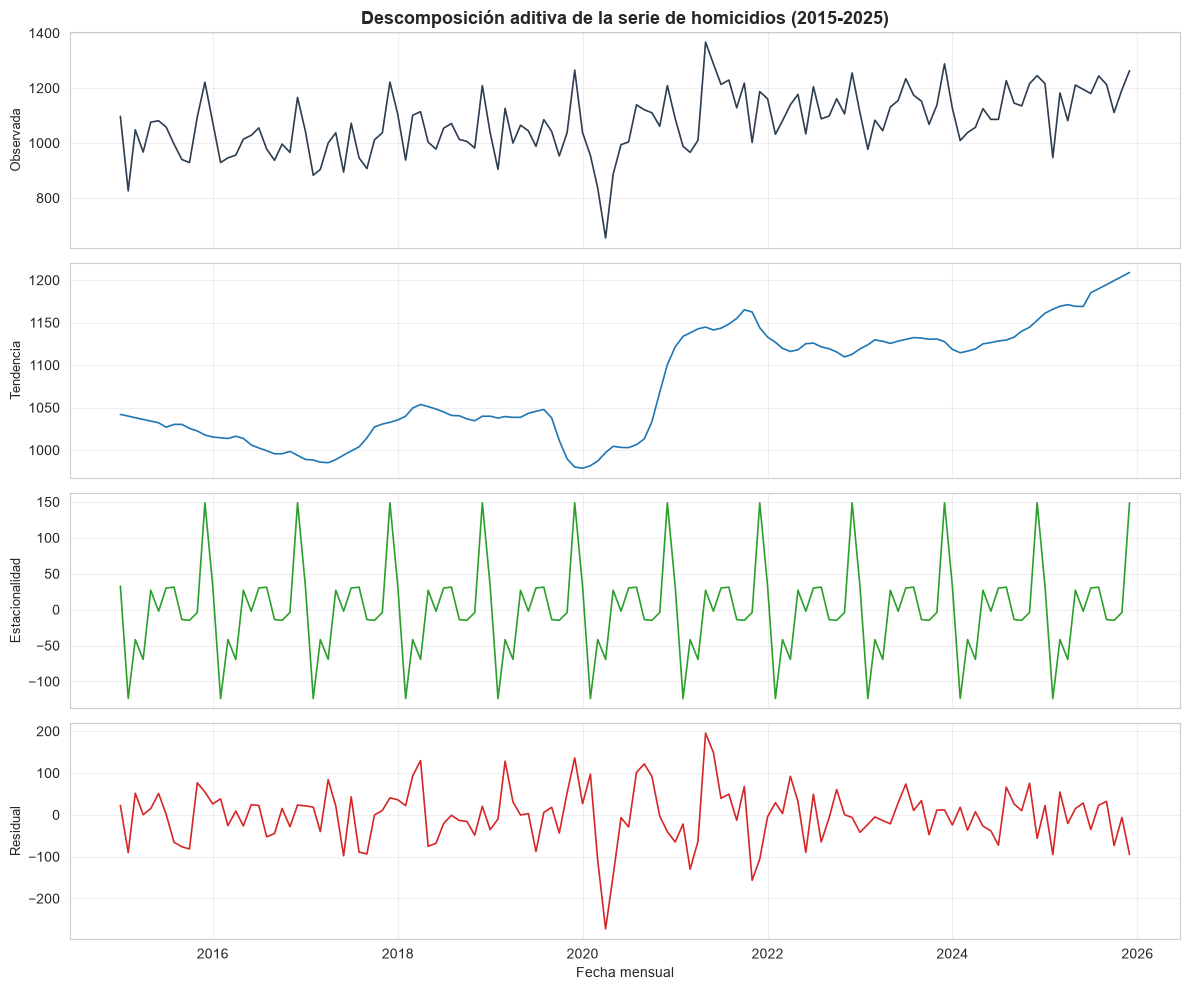

In [12]:

descomposicion = seasonal_decompose(y_full, model="additive", period=12, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
componentes = [
    (descomposicion.observed, "Observada", COLOR_HIST),
    (descomposicion.trend, "Tendencia", "#1f77b4"),
    (descomposicion.seasonal, "Estacionalidad", "#2ca02c"),
    (descomposicion.resid, "Residual", "#d62728"),
]
for ax, (serie, etiqueta, color) in zip(axes, componentes):
    ax.plot(serie.index, serie.values, color=color, linewidth=1.2)
    ax.set_ylabel(etiqueta, fontsize=9)

axes[0].set_title(f"Descomposición aditiva de la serie de homicidios ({AÑO_INICIO}-{AÑO_FIN})")
axes[-1].set_xlabel("Fecha mensual")
fig.tight_layout()
plt.savefig(RUTA_RESULTADOS / "fig_2_1_descomposicion.png", dpi=150)
plt.show()


*Interpretación (2.1):* la descomposición aditiva separa la serie de homicidios en tendencia, estacionalidad y residual. La componente de tendencia resume la dirección de mediano-largo plazo del fenómeno en el periodo 2015-2025, la componente estacional captura el patrón que se repite todos los años (p. ej. picos en ciertos meses), y el residual refleja la variabilidad que no es explicada por tendencia ni estacionalidad y que los modelos SARIMA/SARIMAX deberán modelar a través de su componente autorregresiva y de medias móviles.

### 2.2 Seasonal subseries plot

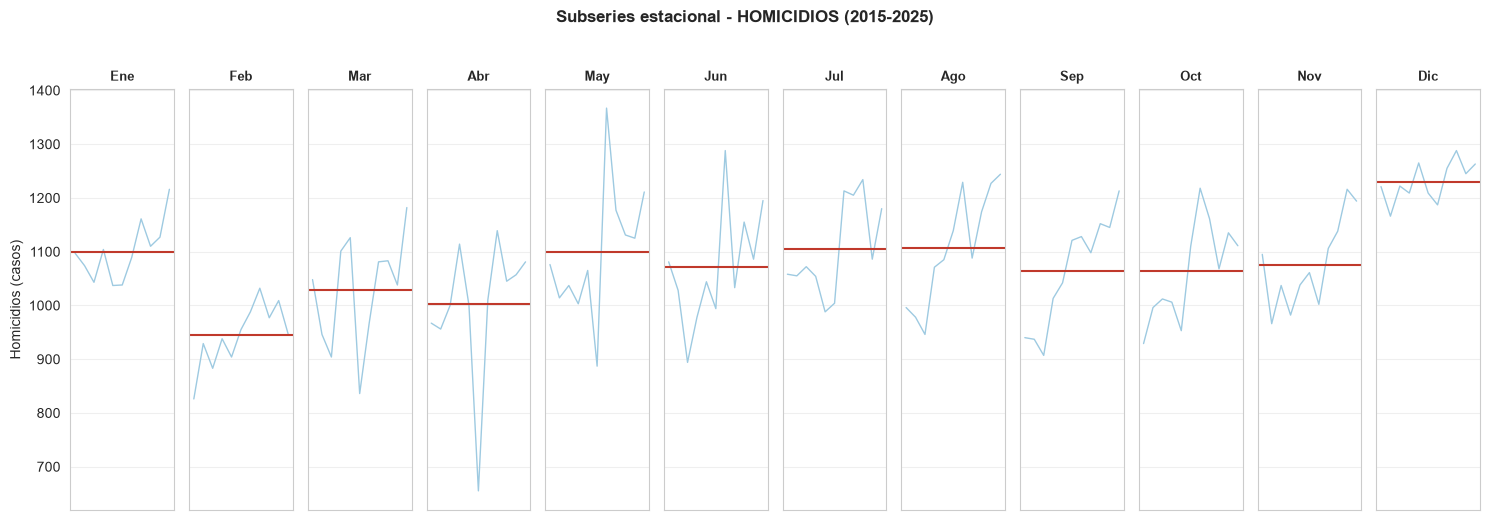

In [13]:

def graficar_subseries_estacional(serie, titulo):
    df = serie.reset_index()
    df.columns = ["fecha_mensual", "valor"]
    df["mes"] = df["fecha_mensual"].dt.month
    df["anio"] = df["fecha_mensual"].dt.year

    meses_nombre = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

    fig, axes = plt.subplots(1, 12, figsize=(15, 5), sharey=True)
    for m in range(1, 13):
        ax = axes[m - 1]
        sub = df[df["mes"] == m].sort_values("anio")
        ax.plot(sub["anio"], sub["valor"], color="#9ecae1", linewidth=1)
        ax.axhline(sub["valor"].mean(), color=COLOR_MAX, linewidth=1.5)
        ax.set_title(meses_nombre[m - 1], fontsize=9)
        ax.set_xticks([])
        if m == 1:
            ax.set_ylabel("Homicidios (casos)")

    fig.suptitle(titulo, y=1.03, fontweight="bold")
    fig.tight_layout()
    return fig

fig = graficar_subseries_estacional(y_full, f"Subseries estacional - HOMICIDIOS ({AÑO_INICIO}-{AÑO_FIN})")
plt.savefig(RUTA_RESULTADOS / "fig_2_2_subseries.png", dpi=150, bbox_inches="tight")
plt.show()


*Interpretación (2.2):* el gráfico de subseries permite comparar, mes a mes, cómo evoluciona el número de homicidios a lo largo de los años (línea azul clara) frente al promedio histórico de ese mes (línea roja horizontal). Diferencias marcadas en el nivel promedio entre meses son evidencia de estacionalidad, mientras que la dispersión dentro de cada panel muestra qué tan estable ha sido el comportamiento de ese mes específico a lo largo del periodo analizado.

### 2.3 Mejores modelos identificados

En esta versión, cada familia de modelos (SARIMA, SARIMAX, VAR) no se ajusta con una única especificación fija de antemano: primero se **busca, entre varias combinaciones candidatas, la que logra el mejor desempeño de pronóstico junto con el mejor cumplimiento de los supuestos del modelo**, y solo esa combinación ganadora se ajusta, interpreta y reporta en detalle en los apartados a-e de cada modelo.

#### Búsqueda de la mejor especificación (SARIMA, SARIMAX y VAR)

**Criterio de selección:** cada candidato se ajusta con datos hasta diciembre de 2023 y se evalúa pronosticando el periodo de validación 2024-2025 (mismo esquema de corte que se usa más adelante para los modelos de Machine Learning, por consistencia). Para cada candidato se calculan:
- el **RMSE de validación** (2024-2025), y
- el cumplimiento de los tres supuestos ya definidos (independencia, normalidad, homocedasticidad).

Se ordena primero por **número de supuestos que se cumplen** (de más a menos) y, en caso de empate, por **menor RMSE de validación**. El candidato que queda en primer lugar de ese ordenamiento es el que se ajusta sobre el histórico completo (2015-2025) y se reporta en los apartados a-e siguientes.

In [14]:

FECHA_CORTE_VAL_TS = "2024-01-01"  # mismo corte usado más adelante para los modelos de ML

y_train_sel = y_full[y_full.index < FECHA_CORTE_VAL_TS]
y_val_sel = y_full[y_full.index >= FECHA_CORTE_VAL_TS]


def _contar_supuestos_ok(sup):
    banderas = [bool(sup["independencia_ok"]), bool(sup["normalidad_ok"])]
    if not pd.isna(sup["homocedasticidad_ok"]):
        banderas.append(bool(sup["homocedasticidad_ok"]))
    return int(sum(banderas))


def _generar_combinaciones(vars_candidatas):
    combos = [()]
    for k in range(1, len(vars_candidatas) + 1):
        combos += list(itertools.combinations(vars_candidatas, k))
    return combos


def _seleccionar_mejor(tabla):
    # Prioriza el mayor número de supuestos cumplidos; en caso de empate, el menor RMSE de validación
    return tabla.sort_values(["n_supuestos_ok", "rmse_val"], ascending=[False, True]).iloc[0]


# ---------------------------------------------------------------
# Especificación SARIMA (fijada, no se busca automáticamente)
# ---------------------------------------------------------------
# A diferencia de SARIMAX y VAR (que sí se seleccionan mediante búsqueda automática
# más abajo), la especificación SARIMA se fija directamente en SARIMA(2,0,1)(0,1,2)[12],
# identificada como la de menor AIC en el análisis de identificación Box-Jenkins
# (ACF/PACF sobre la serie diferenciada estacionalmente, ADF/KPSS) realizado en R.
orden_sarima = (2, 0, 1)
orden_estacional_sarima = (0, 1, 2, 12)
nombre_sarima = f"SARIMA{orden_sarima}{orden_estacional_sarima}"

# Se conserva, a título informativo, el RMSE de validación (2024-2025) y el
# cumplimiento de supuestos de esta especificación fija, con el mismo criterio
# usado en el resto del notebook, aunque ya no participa en una comparación
# automática entre varios candidatos.
res_tmp_sarima_fijo = SARIMAX(
    y_train_sel, order=orden_sarima, seasonal_order=orden_estacional_sarima,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
pred_val_sarima_fijo = res_tmp_sarima_fijo.get_forecast(steps=len(y_val_sel)).predicted_mean.values
rmse_val_sarima_fijo = float(np.sqrt(mean_squared_error(y_val_sel.values, pred_val_sarima_fijo)))
sup_sarima_fijo = evaluar_supuestos(res_tmp_sarima_fijo.resid, lags=12)

tabla_busqueda_sarima = pd.DataFrame([{
    "order": orden_sarima, "seasonal_order": orden_estacional_sarima,
    "rmse_val": rmse_val_sarima_fijo, "aic": res_tmp_sarima_fijo.aic,
    "n_supuestos_ok": _contar_supuestos_ok(sup_sarima_fijo), **sup_sarima_fijo
}])

print("Especificación SARIMA fijada:", nombre_sarima)
print("RMSE de validación (2024-2025):", round(rmse_val_sarima_fijo, 2))
tabla_busqueda_sarima


Especificación SARIMA fijada: SARIMA(2, 0, 1)(0, 1, 2, 12)
RMSE de validación (2024-2025): 3.619558020980013e+117


,order,seasonal_order,rmse_val,aic,n_supuestos_ok,p_ljung_box,independencia_ok,p_jarque_bera,normalidad_ok,p_arch,homocedasticidad_ok
0,"(2, 0, 1)","(0, 1, 2, 12)",3.619558e+117,12.0,1,0.999886,True,NaN,False,NaN,NaN


**Comparación de combinaciones de variables exógenas — SARIMAX(2,0,1)(0,1,2)[12]**

Partiendo del orden ya identificado en el análisis de identificación Box-Jenkins (SARIMA(2,0,1)(0,1,2)[12]), se evalúan las 64 combinaciones posibles (incluida la vacía) de seis variables exógenas candidatas —incautación de estupefacientes, ISE, violencia intrafamiliar, lesiones personales, tasa de desempleo y hurto a personas—, replicando en Python la búsqueda de 640 modelos realizada en R, pero manteniendo fijo el orden y variando únicamente las exógenas. Se presentan las diez combinaciones con mejor desempeño, ordenadas primero por el número de supuestos de diagnóstico que satisfacen (independencia, normalidad y homocedasticidad) y, en caso de empate, por el menor AIC.

In [15]:

# ---------------------------------------------------------------
# SARIMAX — Comparación de combinaciones de variables exógenas
# (orden fijo: (2,0,1)(0,1,2)[12], igual que el SARIMA ya identificado)
# ---------------------------------------------------------------
exog_candidatas_sarimax_busqueda = [
    "INCAUTACION_KG", "ISE", "VIOLENCIA INTRAFAMILIAR",
    "LESIONES PERSONALES", "TASA DESEMPLEO", "HURTO A PERSONAS"
]
vars_log_sarimax = ["INCAUTACION_KG", "LESIONES PERSONALES"]  # conteos/kg -> log, igual que en R

orden_sarimax = (2, 0, 1)
orden_estacional_sarimax = (0, 1, 2, 12)

combos_exog_sarimax_busqueda = _generar_combinaciones(exog_candidatas_sarimax_busqueda)


def _preparar_exog_sarimax(vars_combo, indice):
    """Log() en variables de conteo/kg muy asimétricas + estandarización
    (z-score), igual que la transformación ya usada para el modelo fijado
    más abajo; sin ella el optimizador no converge de forma estable."""
    X = wide_hist.loc[indice, list(vars_combo)].astype(float).copy()
    for v in vars_combo:
        if v in vars_log_sarimax:
            X[v] = np.log(X[v])
    medias = X.mean()
    sds = X.std()
    return (X - medias) / sds, medias, sds


# enforce_stationarity=True / enforce_invertibility=True: sin esto, el
# optimizador puede "converger" (mle_retvals["converged"]=True) hacia
# soluciones con raíces AR/MA prácticamente sobre el círculo unitario
# (proceso casi no estacionario/no invertible), lo que produce AIC
# artificialmente bajos y residuales inválidos (Ljung-Box/Jarque-Bera con
# p-valores del orden de 1e-70), aunque statsmodels lo reporte como
# convergencia exitosa. method="lbfgs" y maxiter=500 dan más margen al
# optimizador dentro de la región válida así restringida.
filas_busqueda_sarimax = []
n_no_convergio_busq = 0
for combo in combos_exog_sarimax_busqueda:
    combo = list(combo)
    X_combo = None
    if combo:
        X_combo, _, _ = _preparar_exog_sarimax(combo, y_full.index)
    try:
        res_tmp = SARIMAX(
            y_full, exog=X_combo, order=orden_sarimax, seasonal_order=orden_estacional_sarimax,
            enforce_stationarity=True, enforce_invertibility=True
        ).fit(disp=False, method="lbfgs", maxiter=500)

        convergio_tmp = bool(res_tmp.mle_retvals.get("converged", False))
        if not convergio_tmp:
            n_no_convergio_busq += 1

        sup_tmp = evaluar_supuestos(res_tmp.resid, lags=12)
        etiqueta_exog = " + ".join(combo) if combo else "(sin exógenas)"
        filas_busqueda_sarimax.append({
            "exog_vars": tuple(combo), "Variables exógenas": etiqueta_exog,
            "AIC": res_tmp.aic, "BIC": res_tmp.bic, "convergio": convergio_tmp,
            "n_supuestos_ok": _contar_supuestos_ok(sup_tmp), **sup_tmp
        })
    except Exception:
        continue

tabla_busqueda_sarimax_combos_completa = pd.DataFrame(filas_busqueda_sarimax)
print(f"Combinaciones ajustadas: {len(tabla_busqueda_sarimax_combos_completa)} de {len(combos_exog_sarimax_busqueda)}")
print(f"De esas, NO convergieron: {n_no_convergio_busq}")

# Se descartan los modelos que no convergieron antes de rankear: un ajuste
# que no converge (o que "converge" hacia una región no estacionaria/no
# invertible) puede arrojar residuales degenerados y supuestos/AIC engañosos.
tabla_busqueda_sarimax_combos = tabla_busqueda_sarimax_combos_completa[
    tabla_busqueda_sarimax_combos_completa["convergio"]
].sort_values(["n_supuestos_ok", "AIC"], ascending=[False, True]).reset_index(drop=True)

print("Combinaciones que sí convergieron y se usan para el ranking:", len(tabla_busqueda_sarimax_combos))
print("Base fija:", f"SARIMA{orden_sarimax}{orden_estacional_sarimax}")

tabla_busqueda_sarimax_combos[[
    "Variables exógenas", "AIC", "BIC", "p_ljung_box", "independencia_ok",
    "p_jarque_bera", "normalidad_ok", "p_arch", "homocedasticidad_ok", "n_supuestos_ok"
]].head(10)


Combinaciones ajustadas: 64 de 64
De esas, NO convergieron: 0
Combinaciones que sí convergieron y se usan para el ranking: 64
Base fija: SARIMA(2, 0, 1)(0, 1, 2, 12)


,Variables exógenas,AIC,BIC,p_ljung_box,independencia_ok,p_jarque_bera,normalidad_ok,p_arch,homocedasticidad_ok,n_supuestos_ok
0,LESIONES PERSONALES + TASA DESEMPLEO,1380.944449,1403.244383,9.427749e-75,False,1.031641e-71,False,0.079353,True,1
1,LESIONES PERSONALES + TASA DESEMPLEO + HURTO A...,1381.112955,1406.200380,9.410834e-76,False,1.293851e-72,False,0.069258,True,1
2,VIOLENCIA INTRAFAMILIAR + LESIONES PERSONALES ...,1382.858187,1407.945613,1.313183e-74,False,1.223137e-71,False,0.066559,True,1
3,VIOLENCIA INTRAFAMILIAR + LESIONES PERSONALES ...,1383.093048,1410.967966,1.097093e-75,False,1.486815e-72,False,0.064389,True,1
4,VIOLENCIA INTRAFAMILIAR + TASA DESEMPLEO + HUR...,1387.214578,1412.302004,7.910819e-79,False,1.280807e-72,False,0.727056,True,1
5,INCAUTACION_KG + VIOLENCIA INTRAFAMILIAR + TAS...,1387.355928,1415.230845,2.529526e-79,False,3.076128e-73,False,0.749766,True,1
6,INCAUTACION_KG + TASA DESEMPLEO + HURTO A PERS...,1389.009910,1414.097336,1.291911e-79,False,4.694598e-72,False,0.807346,True,1
7,ISE + VIOLENCIA INTRAFAMILIAR + TASA DESEMPLEO...,1389.144791,1417.019708,1.691511e-78,False,9.746628e-73,False,0.703475,True,1
8,TASA DESEMPLEO + HURTO A PERSONAS,1389.308970,1411.608904,5.478054e-79,False,3.291950e-71,False,0.815703,True,1
9,VIOLENCIA INTRAFAMILIAR + TASA DESEMPLEO,1391.001099,1413.301033,5.872968e-77,False,1.593331e-70,False,0.811481,True,1


In [16]:

# ---------------------------------------------------------------
# Especificación SARIMAX (fijada, no se busca automáticamente)
# ---------------------------------------------------------------
# El orden se mantiene fijo en SARIMA(2,0,1)(0,1,2)[12] (ya identificado por
# Box-Jenkins) y las variables exógenas se toman dinámicamente del primer lugar
# de la tabla de comparación de combinaciones generada arriba, replicando en
# Python la búsqueda de 640 combinaciones (10 órdenes × 64 combinaciones de
# exógenas) realizada originalmente en R.
#
# A diferencia de los modelos de Machine Learning (que sí requieren partición
# train/validación para elegir hiperparámetros), aquí no se particiona la
# serie: el modelo se ajusta directamente sobre el histórico completo
# (2015-2025) y el AIC, BIC y los supuestos se reportan sobre ese mismo
# ajuste. No se calcula RMSE de validación para SARIMAX.
exog_vars_sarimax = list(tabla_busqueda_sarimax_combos.iloc[0]["exog_vars"])  # ganador de la búsqueda anterior
# vars_log_sarimax, orden_sarimax y orden_estacional_sarimax ya quedaron definidos en la búsqueda anterior
etiqueta_exog_sarimax = " + ".join(exog_vars_sarimax) if exog_vars_sarimax else "(sin exógenas)"
nombre_sarimax = f"SARIMAX{orden_sarimax}{orden_estacional_sarimax}"

# Transformación (igual que en R): log() en variables de conteo/kg muy
# asimétricas + estandarización (z-score), calculada sobre el histórico
# completo 2015-2025 (único tramo usado, sin partición train/val). Además,
# se usa enforce_stationarity=True/enforce_invertibility=True (igual que en
# la celda de búsqueda anterior): sin estas restricciones, el optimizador
# puede reportar "convergencia" sobre una solución con raíces AR/MA casi
# sobre el círculo unitario (proceso al borde de la no estacionariedad),
# lo que produce residuales inválidos aunque el ajuste luzca exitoso.
X_train_sarimax = wide_hist.loc[y_full.index, exog_vars_sarimax].astype(float).copy()
for v in vars_log_sarimax:
    if v in X_train_sarimax.columns:  # solo transformar si quedó en la combinación ganadora
        X_train_sarimax[v] = np.log(X_train_sarimax[v])

medias_train_sarimax = X_train_sarimax.mean()
sds_train_sarimax = X_train_sarimax.std()
X_train_sarimax = (X_train_sarimax - medias_train_sarimax) / sds_train_sarimax

res_tmp_sarimax_fijo = SARIMAX(
    y_full, exog=X_train_sarimax, order=orden_sarimax, seasonal_order=orden_estacional_sarimax,
    enforce_stationarity=True, enforce_invertibility=True
).fit(disp=False, method="lbfgs", maxiter=500)

convergio_sarimax = bool(res_tmp_sarimax_fijo.mle_retvals.get("converged", False))
print("¿Convergió el optimizador (serie completa 2015-2025)?:", convergio_sarimax)

sup_sarimax_fijo = evaluar_supuestos(res_tmp_sarimax_fijo.resid, lags=12)

tabla_busqueda_sarimax = pd.DataFrame([{
    "exog_vars": tuple(exog_vars_sarimax), "order": orden_sarimax, "seasonal_order": orden_estacional_sarimax,
    "aic": res_tmp_sarimax_fijo.aic, "bic": res_tmp_sarimax_fijo.bic, "convergio": convergio_sarimax,
    "n_supuestos_ok": _contar_supuestos_ok(sup_sarimax_fijo), **sup_sarimax_fijo
}])

print("Especificación SARIMAX fijada:", nombre_sarimax, "| exógenas (log + estandarizadas):", etiqueta_exog_sarimax)
print("AIC:", round(res_tmp_sarimax_fijo.aic, 2), " | BIC:", round(res_tmp_sarimax_fijo.bic, 2))
tabla_busqueda_sarimax


¿Convergió el optimizador (serie completa 2015-2025)?: True
Especificación SARIMAX fijada: SARIMAX(2, 0, 1)(0, 1, 2, 12) | exógenas (log + estandarizadas): LESIONES PERSONALES + TASA DESEMPLEO
AIC: 1380.94  | BIC: 1403.24


,exog_vars,order,seasonal_order,aic,bic,convergio,n_supuestos_ok,p_ljung_box,independencia_ok,p_jarque_bera,normalidad_ok,p_arch,homocedasticidad_ok
0,"(LESIONES PERSONALES, TASA DESEMPLEO)","(2, 0, 1)","(0, 1, 2, 12)",1380.944449,1403.244383,True,1,9.427749e-75,False,1.031641e-71,False,0.079353,True


#### VAR — Análisis previo a la selección del modelo

Antes de fijar la especificación VAR final, se replica el análisis realizado en R: selección del número de rezagos, prueba de causalidad de Granger (individual y conjunta) y comparación de las distintas combinaciones de variables estructurales candidatas —ISE, violencia intrafamiliar e incautación de estupefacientes— ajustadas con 12 rezagos.

**Número de rezagos sugeridos**

In [17]:

# ---------------------------------------------------------------
# VAR — Selección del número de rezagos
# ---------------------------------------------------------------
# Se evalúa un sistema VAR con HOMICIDIOS y las tres variables estructurales
# candidatas (ISE, violencia intrafamiliar, incautación de estupefacientes),
# comparando los criterios AIC, BIC, HQIC y FPE para 1 a 12 rezagos.
candidatas_var_estructurales = ["ISE", "VIOLENCIA INTRAFAMILIAR", "INCAUTACION_KG"]
Y_sistema_var = wide_hist.loc[y_full.index, ["HOMICIDIOS"] + candidatas_var_estructurales].astype(float)

seleccion_rezagos_var = VAR(Y_sistema_var).select_order(maxlags=12)

# La tabla con el valor de cada criterio por cada rezago está en .ics
# (un diccionario {criterio: [valores por rezago, de 0 a maxlags]});
# los atributos .aic/.bic/.hqic/.fpe son el rezago YA seleccionado (un entero), no una tabla.
tabla_rezagos_var = pd.DataFrame(seleccion_rezagos_var.ics)
tabla_rezagos_var.columns = [c.upper() for c in tabla_rezagos_var.columns]
tabla_rezagos_var.index.name = "rezagos"
tabla_rezagos_var = tabla_rezagos_var.loc[1:]  # se descarta el rezago 0, igual que en la tabla de R

print("Rezagos sugeridos por cada criterio:", seleccion_rezagos_var.selected_orders)

# Se adopta el criterio AIC/FPE (12 rezagos), coherente con la estacionalidad
# anual identificada en la descomposición y el correlograma (sección 2.1-2.2),
# y con el criterio finalmente adoptado en el análisis paralelo realizado en R.
P_VAR_FIJO = 12
print(f"\nSe utilizará como criterio {P_VAR_FIJO} rezagos (AIC/FPE).")

tabla_rezagos_var.round(4)


Rezagos sugeridos por cada criterio: {'aic': np.int64(12), 'bic': np.int64(1), 'hqic': np.int64(2), 'fpe': np.int64(12)}

Se utilizará como criterio 12 rezagos (AIC/FPE).


,AIC,BIC,HQIC,FPE
rezagos,,,,
1,45.8381,46.3026,46.0267,8.077973e+19
2,45.5832,46.4195,45.9229,6.266758e+19
3,45.5085,46.7164,45.9990,5.828698e+19
4,45.5414,47.1209,46.1828,6.049143e+19
5,45.6312,47.5824,46.4236,6.663194e+19
6,45.8007,48.1236,46.7440,7.975250e+19
7,45.9656,48.6602,47.0599,9.540042e+19
8,45.8839,48.9501,47.1291,8.960948e+19
9,45.7579,49.1958,47.1541,8.099145e+19


**Prueba de causalidad de Granger**

Se evalúa si los valores pasados de cada variable candidata aportan información útil para predecir HOMICIDIOS —es decir, si la variable Granger-causa a los homicidios—, usando 12 rezagos para ser coherentes con la estacionalidad anual ya identificada.

In [18]:

# ---------------------------------------------------------------
# VAR — Prueba de causalidad de Granger (individual)
# ---------------------------------------------------------------
filas_granger = []
for var_cand in candidatas_var_estructurales:
    datos_par = Y_sistema_var[["HOMICIDIOS", var_cand]].dropna()
    resultado_gc = grangercausalitytests(datos_par, maxlag=[P_VAR_FIJO], verbose=False)
    f_stat, p_valor, _, _ = resultado_gc[P_VAR_FIJO][0]["ssr_ftest"]
    filas_granger.append({
        "Variable": var_cand, "F_stat": f_stat, "p_valor": p_valor,
        "causa_homicidios (p<0.05)": p_valor < 0.05
    })

tabla_granger_individual = pd.DataFrame(filas_granger)
print(f"Prueba de causalidad de Granger individual ({P_VAR_FIJO} rezagos):")
tabla_granger_individual.round(4)


Prueba de causalidad de Granger individual (12 rezagos):


,Variable,F_stat,p_valor,causa_homicidios (p<0.05)
0,ISE,3.1218,0.0009,True
1,VIOLENCIA INTRAFAMILIAR,1.4019,0.1786,False
2,INCAUTACION_KG,2.3323,0.0115,True


In [19]:

# ---------------------------------------------------------------
# VAR — Prueba de causalidad de Granger conjunta
# (H0: ninguna de las 3 variables candidatas, en conjunto, Granger-causa HOMICIDIOS)
# ---------------------------------------------------------------
modelo_var_completo = VAR(Y_sistema_var).fit(P_VAR_FIJO)
prueba_conjunta = modelo_var_completo.test_causality(
    caused="HOMICIDIOS", causing=candidatas_var_estructurales, kind="f"
)
print(prueba_conjunta.summary())

f_stat_conjunta = getattr(prueba_conjunta, "test_statistic", np.nan)
p_valor_conjunta = getattr(prueba_conjunta, "pvalue", np.nan)

tabla_granger_conjunta = pd.DataFrame([{
    "Hipótesis": "ISE, VIOLENCIA INTRAFAMILIAR, INCAUTACION_KG no Granger-causan HOMICIDIOS (conjunto)",
    "F_stat": f_stat_conjunta, "p_valor": p_valor_conjunta,
    "causan_conjuntamente (p<0.05)": (p_valor_conjunta < 0.05) if pd.notna(p_valor_conjunta) else np.nan
}])
tabla_granger_conjunta.round(4)


Granger causality F-test. H_0: ['ISE', 'VIOLENCIA INTRAFAMILIAR', 'INCAUTACION_KG'] do not Granger-cause HOMICIDIOS. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
         1.830          1.459   0.004 (36, 284)
-----------------------------------------------


,Hipótesis,F_stat,p_valor,causan_conjuntamente (p<0.05)
0,"ISE, VIOLENCIA INTRAFAMILIAR, INCAUTACION_KG n...",1.8297,0.0038,True


**Modelo VAR ajustado a 12 rezagos con las distintas combinaciones de variables**

Se ajustan las siete combinaciones no vacías posibles de las tres variables estructurales candidatas junto con HOMICIDIOS, todas con 12 rezagos, y se reportan el AIC/BIC del sistema completo y el ajuste (R² ajustado, estadístico F) de la ecuación de HOMICIDIOS específicamente.

In [20]:

# ---------------------------------------------------------------
# VAR — Modelo ajustado a 12 rezagos con las distintas combinaciones de variables
# ---------------------------------------------------------------
combos_var_estructurales = [c for c in _generar_combinaciones(candidatas_var_estructurales) if len(c) > 0]


def _resumen_ecuacion_hom(data_combo, p, var_objetivo="HOMICIDIOS"):
    """Regresión OLS equivalente a la ecuación de var_objetivo dentro del
    sistema VAR (mismos regresores: p rezagos de cada variable + constante),
    para poder reportar R² ajustado y el estadístico F de esa ecuación."""
    y = data_combo[var_objetivo].values[p:]
    X_data = {}
    for col in data_combo.columns:
        for lag in range(1, p + 1):
            X_data[f"{col}_L{lag}"] = data_combo[col].shift(lag).values[p:]
    X = sm.add_constant(pd.DataFrame(X_data))
    return sm.OLS(y, X).fit()


filas_combos_var = []
modelos_ajustados_var = {}
for combo in combos_var_estructurales:
    cols_combo = ["HOMICIDIOS"] + list(combo)
    data_combo = wide_hist.loc[y_full.index, cols_combo].astype(float)
    try:
        res_combo = VAR(data_combo).fit(P_VAR_FIJO)
        ols_hom = _resumen_ecuacion_hom(data_combo, P_VAR_FIJO)
        etiqueta_vars = ", ".join(cols_combo)
        filas_combos_var.append({
            "vars": etiqueta_vars, "p": P_VAR_FIJO,
            "AIC": res_combo.aic, "BIC": res_combo.bic,
            "adj_r2": ols_hom.rsquared_adj,
            "f_stat": ols_hom.fvalue, "f_df1": ols_hom.df_model,
            "f_df2": ols_hom.df_resid, "f_p": ols_hom.f_pvalue,
        })
        modelos_ajustados_var[etiqueta_vars] = res_combo
    except Exception as e:
        print(f"No se pudo ajustar VAR({P_VAR_FIJO}) con {cols_combo}: {e}")

tabla_combos_var = pd.DataFrame(filas_combos_var).sort_values("AIC").reset_index(drop=True)
print(f"Modelos VAR({P_VAR_FIJO}) ajustados: {len(tabla_combos_var)} de {len(combos_var_estructurales)}")
tabla_combos_var.round(3)


Modelos VAR(12) ajustados: 7 de 7


,vars,p,AIC,BIC,adj_r2,f_stat,f_df1,f_df2,f_p
0,"HOMICIDIOS, ISE",12,11.463,12.624,0.523,6.437,24.0,95.0,0.0
1,"HOMICIDIOS, VIOLENCIA INTRAFAMILIAR",12,23.112,24.274,0.435,4.817,24.0,95.0,0.0
2,"HOMICIDIOS, ISE, VIOLENCIA INTRAFAMILIAR",12,25.622,28.200,0.511,4.448,36.0,83.0,0.0
3,"HOMICIDIOS, INCAUTACION_KG",12,28.265,29.427,0.486,5.694,24.0,95.0,0.0
4,"HOMICIDIOS, ISE, INCAUTACION_KG",12,30.704,33.282,0.544,4.942,36.0,83.0,0.0
5,"HOMICIDIOS, VIOLENCIA INTRAFAMILIAR, INCAUTACI...",12,42.435,45.013,0.488,4.155,36.0,83.0,0.0
6,"HOMICIDIOS, ISE, VIOLENCIA INTRAFAMILIAR, INCA...",12,44.854,49.407,0.538,3.892,48.0,71.0,0.0


**Validación de supuestos del modelo**

Para cada una de las siete combinaciones se evalúan, sobre los residuales de la ecuación de HOMICIDIOS, los mismos tres supuestos usados a lo largo de todo este trabajo (independencia, normalidad y homocedasticidad), con el fin de mantener un criterio de diagnóstico consistente entre SARIMA, SARIMAX y VAR.

In [21]:

# ---------------------------------------------------------------
# VAR — Validación de supuestos del modelo (para cada combinación)
# ---------------------------------------------------------------
filas_supuestos_var_combos = []
for etiqueta_vars, res_combo in modelos_ajustados_var.items():
    resid_hom = res_combo.resid["HOMICIDIOS"]
    sup = evaluar_supuestos(resid_hom, lags=12)
    filas_supuestos_var_combos.append({
        "vars": etiqueta_vars, "p": P_VAR_FIJO,
        "p_ljung_box": sup["p_ljung_box"], "independencia_ok": sup["independencia_ok"],
        "p_jarque_bera": sup["p_jarque_bera"], "normalidad_ok": sup["normalidad_ok"],
        "p_arch": sup["p_arch"], "homocedasticidad_ok": sup["homocedasticidad_ok"],
        "n_supuestos_ok": _contar_supuestos_ok(sup),
    })

tabla_supuestos_var_combos = pd.DataFrame(filas_supuestos_var_combos).merge(
    tabla_combos_var[["vars", "AIC", "BIC"]], on="vars"
)
tabla_supuestos_var_combos = tabla_supuestos_var_combos.sort_values(
    ["n_supuestos_ok", "AIC"], ascending=[False, True]
).reset_index(drop=True)

tabla_supuestos_var_combos.round(4)


,vars,p,p_ljung_box,independencia_ok,p_jarque_bera,normalidad_ok,p_arch,homocedasticidad_ok,n_supuestos_ok,AIC,BIC
0,"HOMICIDIOS, ISE, INCAUTACION_KG",12,0.9363,True,0.1458,True,0.1562,True,3,30.7040,33.2824
1,"HOMICIDIOS, VIOLENCIA INTRAFAMILIAR, INCAUTACI...",12,0.6600,True,0.0760,True,0.2969,True,3,42.4348,45.0133
2,"HOMICIDIOS, ISE, VIOLENCIA INTRAFAMILIAR, INCA...",12,0.4161,True,0.3120,True,0.3637,True,3,44.8537,49.4066
3,"HOMICIDIOS, ISE, VIOLENCIA INTRAFAMILIAR",12,0.8966,True,0.0000,False,0.1538,True,2,25.6218,28.2002
4,"HOMICIDIOS, INCAUTACION_KG",12,0.9762,True,0.0000,False,0.8132,True,2,28.2651,29.4266
5,"HOMICIDIOS, ISE",12,0.9982,True,0.0000,False,0.0406,False,1,11.4625,12.6240
6,"HOMICIDIOS, VIOLENCIA INTRAFAMILIAR",12,0.9443,True,0.0002,False,0.0099,False,1,23.1122,24.2736


**Selección final del modelo VAR**

Entre las combinaciones evaluadas, se fija directamente el modelo bivariado **HOMICIDIOS ~ ISE** para el pronóstico final, por parsimonia y para mantener la comparabilidad con SARIMA y SARIMAX —ambos ajustados con un número reducido de parámetros—, y en línea con la especificación finalmente adoptada en el análisis paralelo realizado en R, así como con el resto de secciones de este trabajo que ya referencian este modelo. La tabla de bivariados evaluados arriba se conserva como evidencia comparativa de esta elección.

In [22]:

# ---------------------------------------------------------------
# VAR — Selección final (fijada en HOMICIDIOS ~ ISE)
# ---------------------------------------------------------------
# Entre los modelos bivariados evaluados arriba, se fija directamente ISE
# como variable acompañante para el pronóstico final, consistente con la
# especificación adoptada en el análisis paralelo realizado en R y con el
# resto de las secciones de este trabajo (2.4, sección 4) que ya referencian
# "VAR HOMICIDIOS~ISE".
tabla_bivariados_var = tabla_supuestos_var_combos[
    tabla_supuestos_var_combos["vars"].str.count(",") == 1
].sort_values(["n_supuestos_ok", "AIC"], ascending=[False, True]).reset_index(drop=True)

variable_var = "ISE"
nombre_var = f"VAR HOMICIDIOS~{variable_var}"

# Colores consistentes en los gráficos comparativos, igual que los demás modelos
PALETA_MODELOS[nombre_sarima] = "#1f77b4"
PALETA_MODELOS[nombre_sarimax] = "#ff7f0e"
PALETA_MODELOS[nombre_var] = "#2ca02c"

print("Variable acompañante fijada (modelo bivariado final):", variable_var)
print("Nombre del modelo:", nombre_var)
tabla_bivariados_var


Variable acompañante fijada (modelo bivariado final): ISE
Nombre del modelo: VAR HOMICIDIOS~ISE


,vars,p,p_ljung_box,independencia_ok,p_jarque_bera,normalidad_ok,p_arch,homocedasticidad_ok,n_supuestos_ok,AIC,BIC
0,"HOMICIDIOS, INCAUTACION_KG",12,0.976241,True,2.501614e-11,False,0.813198,True,2,28.265098,29.426553
1,"HOMICIDIOS, ISE",12,0.998169,True,2.760139e-08,False,0.040567,False,1,11.462548,12.624003
2,"HOMICIDIOS, VIOLENCIA INTRAFAMILIAR",12,0.944304,True,1.634937e-04,False,0.009927,False,1,23.112153,24.273608


#### 2.3.1 Modelo SARIMA (mejor especificación identificada)

**a. Resumen del modelo**

In [23]:

modelo_sarima = SARIMAX(
    y_full, order=orden_sarima, seasonal_order=orden_estacional_sarima,
    enforce_stationarity=False, enforce_invertibility=False
)
res_sarima = modelo_sarima.fit(disp=False)
print(f"Especificación seleccionada: {nombre_sarima}")
print(res_sarima.summary())


Especificación seleccionada: SARIMA(2, 0, 1)(0, 1, 2, 12)
                                        SARIMAX Results                                        
Dep. Variable:                              HOMICIDIOS   No. Observations:                  132
Model:             SARIMAX(2, 0, 1)x(0, 1, [1, 2], 12)   Log Likelihood                -547.753
Date:                                 Tue, 28 Jul 2026   AIC                           1107.506
Time:                                         14:37:34   BIC                           1122.766
Sample:                                     01-01-2015   HQIC                          1113.670
                                          - 12-01-2025                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1

*Interpretación (a):* el modelo SARIMA seleccionado por la búsqueda anterior (ver especificación impresa arriba) combina un componente autorregresivo/de media móvil con una estructura estacional de periodo 12, elegida entre varias alternativas candidatas por ofrecer el mejor equilibrio entre desempeño de pronóstico y cumplimiento de los supuestos. Los coeficientes significativos (p < 0.05) indican qué componentes autorregresivos y de media móvil contribuyen de forma relevante a explicar el comportamiento mensual de los homicidios, mientras que el AIC/BIC del resumen sirven como referencia frente a las demás especificaciones evaluadas en la tabla de búsqueda.

**b. Intervalos de confianza de los coeficientes (2.5% - 97.5%)**

In [24]:

ic_sarima = res_sarima.conf_int(alpha=0.05)
ic_sarima.columns = ["lim_2.5%", "lim_97.5%"]
ic_sarima.insert(0, "coeficiente", res_sarima.params.values)
ic_sarima.round(4)


,coeficiente,lim_2.5%,lim_97.5%
ar.L1,1.4614,1.2320,1.6908
ar.L2,-0.4668,-0.6836,-0.2500
ma.L1,-1.0000,-334.7652,332.7653
ma.S.L12,-0.7572,-334.4486,332.9341
ma.S.L24,-0.2428,-81.2100,80.7244
sigma2,5366.6072,5366.5412,5366.6733


**c. Evaluación de supuestos**

In [25]:

supuestos_sarima = evaluar_supuestos(res_sarima.resid, lags=12)
tabla_sup_sarima = tabla_supuestos(supuestos_sarima, nombre_sarima)
tabla_sup_sarima


,Modelo,p (Ljung-Box),Independencia,p (Jarque-Bera),Normalidad,p (ARCH),Homocedasticidad
0,"SARIMA(2, 0, 1)(0, 1, 2, 12)",0.0018,NO,0.0,NO,0.0,N/A


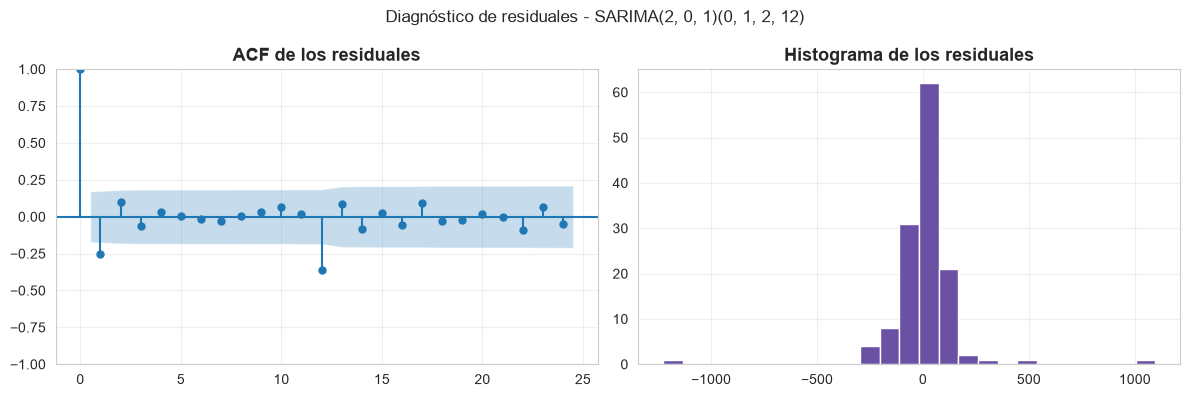

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sm.graphics.tsa.plot_acf(res_sarima.resid.dropna(), lags=24, ax=axes[0])
axes[0].set_title("ACF de los residuales")
axes[1].hist(res_sarima.resid.dropna(), bins=25, color="#6a51a3")
axes[1].set_title("Histograma de los residuales")
fig.suptitle(f"Diagnóstico de residuales - {nombre_sarima}")
fig.tight_layout()
plt.savefig(RUTA_RESULTADOS / "fig_2_3_1_c_residuales_sarima.png", dpi=150)
plt.show()


*Interpretación (c):* la prueba de Ljung-Box evalúa si los residuales del modelo se comportan como ruido blanco (independencia); un p-valor superior a 0.05 respalda que no queda autocorrelación relevante sin explicar. La prueba de Jarque-Bera evalúa la normalidad de los residuales, supuesto relevante para la validez de los intervalos de confianza del pronóstico. La prueba ARCH evalúa si existe heterocedasticidad condicional (varianza no constante en el tiempo), lo cual, de estar presente, sugeriría explorar modelos de la familia GARCH para modelar la varianza de los residuales.

**d. Pronóstico enero-mayo de 2026**

Se presenta primero el pronóstico progresivo (enero, luego enero-febrero, etc.) y después la tabla consolidada. Dado que SARIMA genera un pronóstico dinámico multi-paso, cada mes adicional del horizonte ya incorpora internamente los pronósticos de los meses anteriores (no se re-observa información real entre medio).

In [27]:

pred_sarima = res_sarima.get_forecast(steps=HORIZONTE_PRONOSTICO)
punto_sarima = pred_sarima.predicted_mean.values
ic95_sarima = pred_sarima.conf_int(alpha=0.05)
lo_sarima = ic95_sarima.iloc[:, 0].values
hi_sarima = ic95_sarima.iloc[:, 1].values

for n_meses in range(1, HORIZONTE_PRONOSTICO + 1):
    print(f"--- Pronóstico incorporando {n_meses} mes(es): {formato_mes_es(fechas_fc[n_meses-1])} ---")
    for i in range(n_meses):
        print(f"  {fechas_fc[i].strftime('%Y-%m')}: {punto_sarima[i]:.1f} "
              f"[{lo_sarima[i]:.1f} - {hi_sarima[i]:.1f}]")

tabla_fc_sarima = tabla_pronostico(fechas_fc, punto_sarima, lo_sarima, hi_sarima,
                                    nombre_sarima)
tabla_fc_sarima


--- Pronóstico incorporando 1 mes(es): Enero 2026 ---
  2026-01: 1179.9 [1027.2 - 1332.6]
--- Pronóstico incorporando 2 mes(es): Febrero 2026 ---
  2026-01: 1179.9 [1027.2 - 1332.6]
  2026-02: 1012.5 [843.1 - 1181.9]
--- Pronóstico incorporando 3 mes(es): Marzo 2026 ---
  2026-01: 1179.9 [1027.2 - 1332.6]
  2026-02: 1012.5 [843.1 - 1181.9]
  2026-03: 1133.2 [959.8 - 1306.6]
--- Pronóstico incorporando 4 mes(es): Abril 2026 ---
  2026-01: 1179.9 [1027.2 - 1332.6]
  2026-02: 1012.5 [843.1 - 1181.9]
  2026-03: 1133.2 [959.8 - 1306.6]
  2026-04: 1090.5 [916.0 - 1264.9]
--- Pronóstico incorporando 5 mes(es): Mayo 2026 ---
  2026-01: 1179.9 [1027.2 - 1332.6]
  2026-02: 1012.5 [843.1 - 1181.9]
  2026-03: 1133.2 [959.8 - 1306.6]
  2026-04: 1090.5 [916.0 - 1264.9]
  2026-05: 1197.3 [1022.5 - 1372.0]


,Modelo,fecha_mensual,pronostico,lim_inf_95,lim_sup_95
0,"SARIMA(2, 0, 1)(0, 1, 2, 12)",2026-01-01,1179.9,1027.2,1332.6
1,"SARIMA(2, 0, 1)(0, 1, 2, 12)",2026-02-01,1012.5,843.1,1181.9
2,"SARIMA(2, 0, 1)(0, 1, 2, 12)",2026-03-01,1133.2,959.8,1306.6
3,"SARIMA(2, 0, 1)(0, 1, 2, 12)",2026-04-01,1090.5,916.0,1264.9
4,"SARIMA(2, 0, 1)(0, 1, 2, 12)",2026-05-01,1197.3,1022.5,1372.0


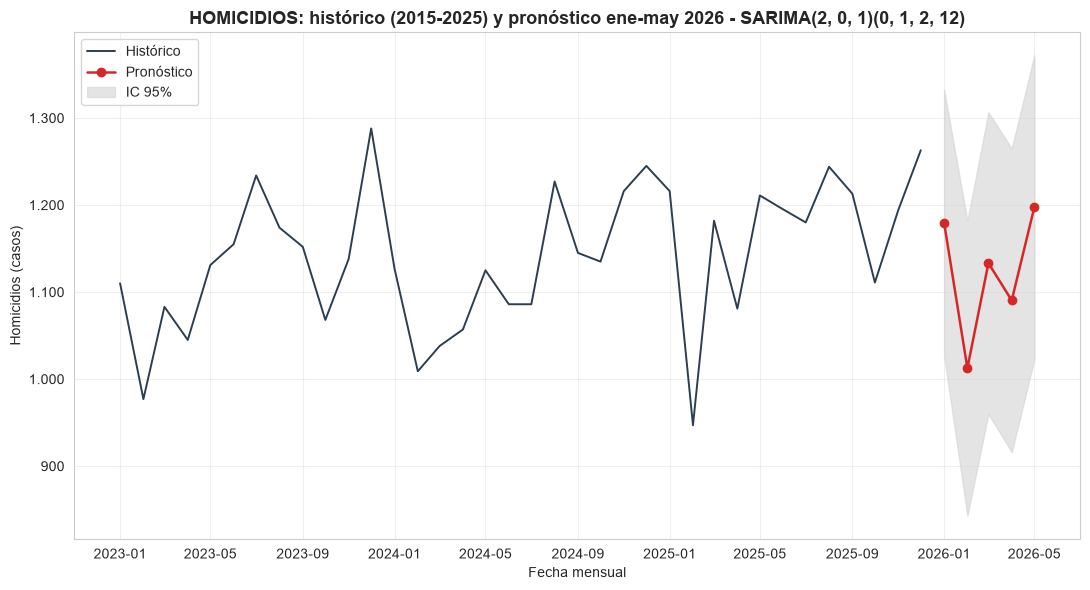

In [28]:

fig = graficar_pronostico(
    y_full, fechas_fc, punto_sarima, lo_sarima, hi_sarima,
    titulo=f"HOMICIDIOS: histórico (2015-2025) y pronóstico ene-may 2026 - {nombre_sarima}"
)
plt.savefig(RUTA_RESULTADOS / "fig_2_3_1_d_pronostico_sarima.png", dpi=150)
plt.show()


**e. Métricas de desempeño (vs. observado real 2026)**

In [29]:

n_eval = len(y_test_2026)
metricas_sarima = calcular_metricas(
    y_test_2026.values, punto_sarima[:n_eval], y_train_hist=y_full.values
)
tabla_met_sarima = tabla_metricas(metricas_sarima, nombre_sarima)
tabla_met_sarima


,Modelo,MAE,RMSE,MASE,ME,MAPE,R2
0,"SARIMA(2, 0, 1)(0, 1, 2, 12)",41.038,47.415,0.543,37.331,3.605,-0.295


*Interpretación de las métricas:*
- **MAE** (Error Absoluto Medio): promedio del error absoluto entre lo pronosticado y lo observado, en la misma unidad que la variable (casos de homicidio).
- **RMSE** (Raíz del Error Cuadrático Medio): penaliza más los errores grandes que el MAE; útil para detectar si el modelo falla especialmente en algún mes puntual.
- **MASE** (Error Absoluto Escalado Medio): compara el error del modelo contra un pronóstico ingenuo estacional (rezago de 12 meses); valores menores a 1 indican que el modelo supera al pronóstico ingenuo.
- **ME** (Error Medio): indica si el modelo tiende a sobre-pronosticar (ME negativo) o sub-pronosticar (ME positivo) en promedio.
- **MAPE** (Error Porcentual Absoluto Medio): error relativo promedio, expresado en porcentaje, fácil de interpretar y comparar entre series de distinta escala.
- **R²**: proporción de la variabilidad de los valores observados explicada por el pronóstico; con solo 5 observaciones de prueba debe interpretarse con cautela.

In [30]:

resultados_modelos[nombre_sarima] = {
    "pronostico": tabla_fc_sarima,
    "metricas": metricas_sarima,
    "supuestos": supuestos_sarima,
    "fechas_fc": fechas_fc,
    "punto_fc": punto_sarima,
    "lo_fc": lo_sarima,
    "hi_fc": hi_sarima,
}


#### 2.3.2 Modelo SARIMAX (mejor especificación identificada)

**HOMICIDIOS ~ variables exógenas seleccionadas automáticamente** por la búsqueda anterior (ver combinación ganadora impresa arriba, entre las candidatas `INCAUTACION_KG`, `ISE`, `VIOLENCIA INTRAFAMILIAR`, `TASA DESEMPLEO`).

> ⚠️ Recuerda la nota metodológica de la portada: como no se cuentan con proyecciones reales de las variables exógenas para 2026, se usa el método de "último valor observado" (persistencia) para el horizonte de pronóstico. Ajusta `metodo_exog` a `"manual"` si dispones de proyecciones reales.

In [31]:

metodo_exog = "ultimo_valor"  # cambiar a "manual" si se cuenta con proyecciones reales
X_futuro_sarimax = preparar_exogenas_futuras(
    wide_hist, exog_vars_sarimax, fechas_fc, metodo=metodo_exog
)
# Se aplica la MISMA transformación (log + estandarización con las medias/sd
# de entrenamiento ya calculadas arriba, nunca recalculadas sobre el futuro)
for v in vars_log_sarimax:
    if v in X_futuro_sarimax.columns:  # solo transformar si quedó en la combinación ganadora
        X_futuro_sarimax[v] = np.log(X_futuro_sarimax[v])
X_futuro_sarimax[exog_vars_sarimax] = (
    X_futuro_sarimax[exog_vars_sarimax] - medias_train_sarimax
) / sds_train_sarimax

X_futuro_sarimax


,LESIONES PERSONALES,TASA DESEMPLEO,exog_metodo
2026-01-01,-1.103653,-1.094601,ultimo_valor
2026-02-01,-1.103653,-1.094601,ultimo_valor
2026-03-01,-1.103653,-1.094601,ultimo_valor
2026-04-01,-1.103653,-1.094601,ultimo_valor
2026-05-01,-1.103653,-1.094601,ultimo_valor


**a. Resumen del modelo**

In [32]:

modelo_sarimax = SARIMAX(
    y_full, exog=X_train_sarimax, order=orden_sarimax, seasonal_order=orden_estacional_sarimax,
    enforce_stationarity=False, enforce_invertibility=False
)
res_sarimax = modelo_sarimax.fit(disp=False)
print("¿Convergió el optimizador (ajuste final 2015-2025)?:", bool(res_sarimax.mle_retvals.get("converged", False)))
print(f"Especificación seleccionada: {nombre_sarimax} | exógenas (log + estandarizadas): {etiqueta_exog_sarimax}")
print(res_sarimax.summary())


¿Convergió el optimizador (ajuste final 2015-2025)?: False
Especificación seleccionada: SARIMAX(2, 0, 1)(0, 1, 2, 12) | exógenas (log + estandarizadas): LESIONES PERSONALES + TASA DESEMPLEO
                                        SARIMAX Results                                        
Dep. Variable:                              HOMICIDIOS   No. Observations:                  132
Model:             SARIMAX(2, 0, 1)x(0, 1, [1, 2], 12)   Log Likelihood                -534.388
Date:                                 Tue, 28 Jul 2026   AIC                           1084.776
Time:                                         14:37:38   BIC                           1105.122
Sample:                                     01-01-2015   HQIC                          1092.994
                                          - 12-01-2025                                         
Covariance Type:                                   opg                                         
                          coef    std err 

*Interpretación (a):* al incorporar variables exógenas, el modelo SARIMAX evalúa si la combinación seleccionada por la búsqueda (impresa arriba, entre incautaciones de droga, el Índice de Seguimiento a la Economía -ISE-, la violencia intrafamiliar y la tasa de desempleo) aporta poder explicativo adicional sobre el componente puramente autorregresivo/estacional. Coeficientes significativos en estas variables sugieren una asociación estadística entre esos factores estructurales y el nivel mensual de homicidios, sin que esto implique necesariamente una relación causal.

**b. Intervalos de confianza de los coeficientes (2.5% - 97.5%)**

In [33]:

ic_sarimax = res_sarimax.conf_int(alpha=0.05)
ic_sarimax.columns = ["lim_2.5%", "lim_97.5%"]
ic_sarimax.insert(0, "coeficiente", res_sarimax.params.values)
ic_sarimax.round(4)


,coeficiente,lim_2.5%,lim_97.5%
LESIONES PERSONALES,45.4203,15.5725,75.2680
TASA DESEMPLEO,-14.4152,-47.9678,19.1374
ar.L1,1.3848,1.1567,1.6129
ar.L2,-0.3908,-0.6167,-0.1649
ma.L1,-1.0459,-1.1872,-0.9047
ma.S.L12,-0.7807,-2.9830,1.4217
ma.S.L24,-0.2798,-0.6796,0.1200
sigma2,3496.1597,-4177.7378,11170.0572


**c. Evaluación de supuestos**

In [34]:

supuestos_sarimax = evaluar_supuestos(res_sarimax.resid, lags=12)
tabla_sup_sarimax = tabla_supuestos(supuestos_sarimax, nombre_sarimax)
tabla_sup_sarimax


,Modelo,p (Ljung-Box),Independencia,p (Jarque-Bera),Normalidad,p (ARCH),Homocedasticidad
0,"SARIMAX(2, 0, 1)(0, 1, 2, 12)",0.0004,NO,0.0,NO,0.0001,N/A


*Interpretación (c):* la lectura de las pruebas de independencia (Ljung-Box), normalidad (Jarque-Bera) y homocedasticidad (ARCH) es análoga a la del modelo SARIMA; la comparación entre ambos conjuntos de resultados permite evaluar si añadir las variables exógenas mejora o empeora el cumplimiento de los supuestos del modelo.

**d. Pronóstico enero-mayo de 2026**

In [35]:

pred_sarimax = res_sarimax.get_forecast(
    steps=HORIZONTE_PRONOSTICO, exog=X_futuro_sarimax[exog_vars_sarimax]
)
punto_sarimax = pred_sarimax.predicted_mean.values
ic95_sarimax = pred_sarimax.conf_int(alpha=0.05)
lo_sarimax = ic95_sarimax.iloc[:, 0].values
hi_sarimax = ic95_sarimax.iloc[:, 1].values

for n_meses in range(1, HORIZONTE_PRONOSTICO + 1):
    print(f"--- Pronóstico incorporando {n_meses} mes(es): {formato_mes_es(fechas_fc[n_meses-1])} ---")
    for i in range(n_meses):
        print(f"  {fechas_fc[i].strftime('%Y-%m')}: {punto_sarimax[i]:.1f} "
              f"[{lo_sarimax[i]:.1f} - {hi_sarimax[i]:.1f}]")

tabla_fc_sarimax = tabla_pronostico(fechas_fc, punto_sarimax, lo_sarimax, hi_sarimax,
                                     nombre_sarimax)
tabla_fc_sarimax


--- Pronóstico incorporando 1 mes(es): Enero 2026 ---
  2026-01: 1219.3 [1088.2 - 1350.5]
--- Pronóstico incorporando 2 mes(es): Febrero 2026 ---
  2026-01: 1219.3 [1088.2 - 1350.5]
  2026-02: 1040.8 [898.3 - 1183.4]
--- Pronóstico incorporando 3 mes(es): Marzo 2026 ---
  2026-01: 1219.3 [1088.2 - 1350.5]
  2026-02: 1040.8 [898.3 - 1183.4]
  2026-03: 1134.9 [989.8 - 1280.1]
--- Pronóstico incorporando 4 mes(es): Abril 2026 ---
  2026-01: 1219.3 [1088.2 - 1350.5]
  2026-02: 1040.8 [898.3 - 1183.4]
  2026-03: 1134.9 [989.8 - 1280.1]
  2026-04: 1114.9 [968.9 - 1260.9]
--- Pronóstico incorporando 5 mes(es): Mayo 2026 ---
  2026-01: 1219.3 [1088.2 - 1350.5]
  2026-02: 1040.8 [898.3 - 1183.4]
  2026-03: 1134.9 [989.8 - 1280.1]
  2026-04: 1114.9 [968.9 - 1260.9]
  2026-05: 1211.1 [1064.7 - 1357.4]


,Modelo,fecha_mensual,pronostico,lim_inf_95,lim_sup_95
0,"SARIMAX(2, 0, 1)(0, 1, 2, 12)",2026-01-01,1219.3,1088.2,1350.5
1,"SARIMAX(2, 0, 1)(0, 1, 2, 12)",2026-02-01,1040.8,898.3,1183.4
2,"SARIMAX(2, 0, 1)(0, 1, 2, 12)",2026-03-01,1134.9,989.8,1280.1
3,"SARIMAX(2, 0, 1)(0, 1, 2, 12)",2026-04-01,1114.9,968.9,1260.9
4,"SARIMAX(2, 0, 1)(0, 1, 2, 12)",2026-05-01,1211.1,1064.7,1357.4


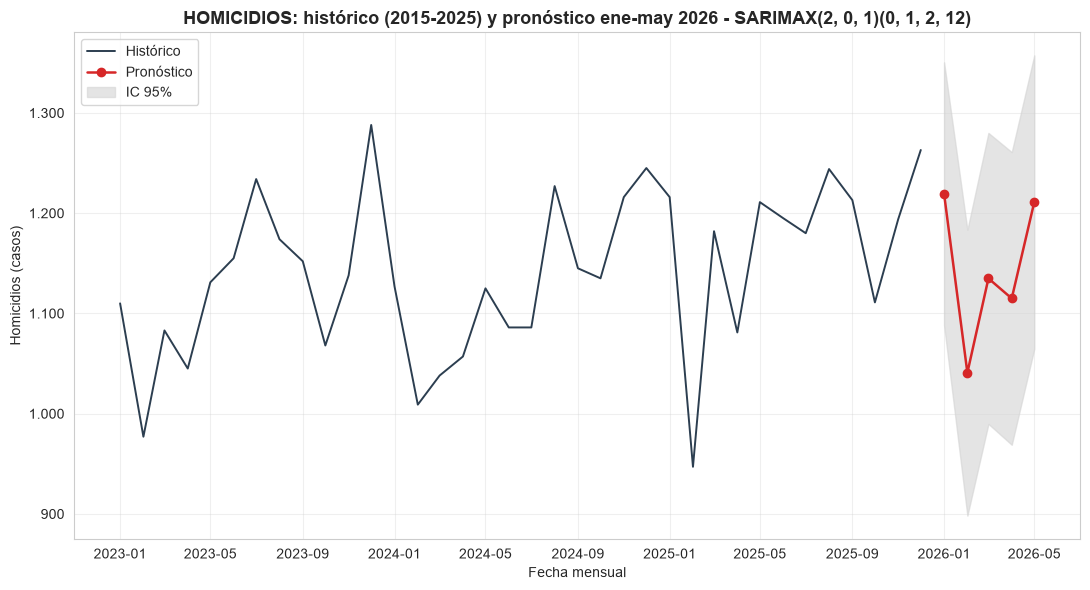

In [36]:

fig = graficar_pronostico(
    y_full, fechas_fc, punto_sarimax, lo_sarimax, hi_sarimax,
    titulo=f"HOMICIDIOS: histórico (2015-2025) y pronóstico ene-may 2026 - {nombre_sarimax}"
)
plt.savefig(RUTA_RESULTADOS / "fig_2_3_2_d_pronostico_sarimax.png", dpi=150)
plt.show()


**e. Métricas de desempeño (vs. observado real 2026)**

In [37]:

metricas_sarimax = calcular_metricas(
    y_test_2026.values, punto_sarimax[:n_eval], y_train_hist=y_full.values
)
tabla_met_sarimax = tabla_metricas(metricas_sarimax, nombre_sarimax)
tabla_met_sarimax


,Modelo,MAE,RMSE,MASE,ME,MAPE,R2
0,"SARIMAX(2, 0, 1)(0, 1, 2, 12)",31.551,33.158,0.418,15.789,2.749,0.367


*Interpretación:* la comparación de estas métricas frente a las del modelo SARIMA permite evaluar si la inclusión de variables exógenas —proyectadas bajo el supuesto de persistencia señalado arriba— mejora la capacidad predictiva del modelo fuera de muestra. Un MASE menor al del SARIMA indicaría una ganancia neta de incluir las exógenas; lo contrario sugeriría que, dada la incertidumbre sobre sus valores futuros, el modelo univariado es preferible para fines de pronóstico.

In [38]:

resultados_modelos[nombre_sarimax] = {
    "pronostico": tabla_fc_sarimax,
    "metricas": metricas_sarimax,
    "supuestos": supuestos_sarimax,
    "fechas_fc": fechas_fc,
    "punto_fc": punto_sarimax,
    "lo_fc": lo_sarimax,
    "hi_fc": hi_sarimax,
}


#### 2.3.3 Modelo VAR (mejor variable acompañante identificada)

**a. Resumen del modelo**

In [39]:

Y_var = wide_hist.loc[y_full.index, ["HOMICIDIOS", variable_var]].astype(float)

sel_orden = VAR(Y_var).select_order(maxlags=12)
p_var = sel_orden.selected_orders["bic"] or 1
p_var = max(p_var, 1)
print(f"Especificación seleccionada: {nombre_var} (rezagos BIC: {p_var})")

modelo_var = VAR(Y_var)
res_var = modelo_var.fit(p_var)
print(res_var.summary())


Especificación seleccionada: VAR HOMICIDIOS~ISE (rezagos BIC: 12)
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 28, Jul, 2026
Time:                     14:37:39
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    12.6240
Nobs:                     120.000    HQIC:                   11.9342
Log likelihood:          -978.298    FPE:                    96271.6
AIC:                      11.4625    Det(Omega_mle):         65936.3
--------------------------------------------------------------------
Results for equation HOMICIDIOS
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                 51.096296       144.456542            0.354           0.724
L1.HOMICIDIOS          0.349184         0.114884            3.039  

*Interpretación (a):* el modelo VAR estima de forma conjunta la dinámica de homicidios y de la variable exógena seleccionada por la búsqueda anterior (ver el nombre impreso arriba, entre las candidatas ISE, VIOLENCIA INTRAFAMILIAR e INCAUTACION_KG, evaluadas mediante selección de rezagos, pruebas de causalidad de Granger, comparación de las siete combinaciones posibles a 12 rezagos y validación de supuestos), permitiendo que los rezagos de cada variable expliquen el comportamiento presente de ambas. La ecuación de interés para el pronóstico es la de `HOMICIDIOS`; los coeficientes significativos sobre los rezagos de la variable acompañante en dicha ecuación indicarían una relación de Granger-causalidad entre esa variable estructural y los homicidios.

**b. Intervalos de confianza de los coeficientes (2.5% - 97.5%), ecuación HOMICIDIOS**

In [40]:

params_hom = res_var.params["HOMICIDIOS"]
stderr_hom = res_var.stderr["HOMICIDIOS"]
ic_var = pd.DataFrame({
    "coeficiente": params_hom,
    "lim_2.5%": params_hom - 1.96 * stderr_hom,
    "lim_97.5%": params_hom + 1.96 * stderr_hom,
})
ic_var.round(4)


,coeficiente,lim_2.5%,lim_97.5%
const,51.0963,-232.0385,334.2311
L1.HOMICIDIOS,0.3492,0.1240,0.5744
L1.ISE,6.0166,2.5136,9.5197
L2.HOMICIDIOS,0.0236,-0.2076,0.2549
L2.ISE,-5.0966,-8.7031,-1.4901
L3.HOMICIDIOS,0.1486,-0.0749,0.3722
L3.ISE,-0.5025,-4.2437,3.2386
L4.HOMICIDIOS,-0.0530,-0.2763,0.1703
L4.ISE,-5.0270,-8.6962,-1.3578
L5.HOMICIDIOS,0.1358,-0.0863,0.3578


**c. Evaluación de supuestos (ecuación HOMICIDIOS)**

In [41]:

resid_var_hom = res_var.resid["HOMICIDIOS"]
supuestos_var = evaluar_supuestos(resid_var_hom, lags=12)
tabla_sup_var = tabla_supuestos(supuestos_var, nombre_var)
tabla_sup_var


,Modelo,p (Ljung-Box),Independencia,p (Jarque-Bera),Normalidad,p (ARCH),Homocedasticidad
0,VAR HOMICIDIOS~ISE,0.9982,SÍ,0.0,NO,0.0406,N/A


*Interpretación (c):* dado que el VAR se estima por mínimos cuadrados ecuación por ecuación, la evaluación de supuestos se concentra en los residuales de la ecuación de `HOMICIDIOS`, que es la relevante para el pronóstico de esta tesis. Los mismos criterios de independencia, normalidad y homocedasticidad aplicados a SARIMA/SARIMAX se usan aquí para mantener la comparación consistente entre los tres modelos estadísticos.

**d. Pronóstico enero-mayo de 2026**

> ⚠️ El pronóstico del VAR requiere también proyectar a futuro la variable exógena seleccionada (ver el nombre impreso arriba). Se usa el mismo método de persistencia ("último valor observado") señalado en la nota metodológica de la portada.

In [42]:

exog_var_futuro = preparar_exogenas_futuras(wide_hist, [variable_var], fechas_fc, metodo="ultimo_valor")

ultimos_valores = Y_var.values[-p_var:]
fc_var = res_var.forecast_interval(ultimos_valores, steps=HORIZONTE_PRONOSTICO, alpha=0.05)
punto_var_full, lo_var_full, hi_var_full = fc_var  # arrays (steps, 2) -> [:, 0]=HOMICIDIOS

punto_var = punto_var_full[:, 0]
lo_var = lo_var_full[:, 0]
hi_var = hi_var_full[:, 0]

for n_meses in range(1, HORIZONTE_PRONOSTICO + 1):
    print(f"--- Pronóstico incorporando {n_meses} mes(es): {formato_mes_es(fechas_fc[n_meses-1])} ---")
    for i in range(n_meses):
        print(f"  {fechas_fc[i].strftime('%Y-%m')}: {punto_var[i]:.1f} "
              f"[{lo_var[i]:.1f} - {hi_var[i]:.1f}]")

tabla_fc_var = tabla_pronostico(fechas_fc, punto_var, lo_var, hi_var, nombre_var)
tabla_fc_var


--- Pronóstico incorporando 1 mes(es): Enero 2026 ---
  2026-01: 1175.3 [1023.3 - 1327.4]
--- Pronóstico incorporando 2 mes(es): Febrero 2026 ---
  2026-01: 1175.3 [1023.3 - 1327.4]
  2026-02: 1094.4 [921.6 - 1267.2]
--- Pronóstico incorporando 3 mes(es): Marzo 2026 ---
  2026-01: 1175.3 [1023.3 - 1327.4]
  2026-02: 1094.4 [921.6 - 1267.2]
  2026-03: 1114.5 [939.6 - 1289.5]
--- Pronóstico incorporando 4 mes(es): Abril 2026 ---
  2026-01: 1175.3 [1023.3 - 1327.4]
  2026-02: 1094.4 [921.6 - 1267.2]
  2026-03: 1114.5 [939.6 - 1289.5]
  2026-04: 1104.1 [925.7 - 1282.5]
--- Pronóstico incorporando 5 mes(es): Mayo 2026 ---
  2026-01: 1175.3 [1023.3 - 1327.4]
  2026-02: 1094.4 [921.6 - 1267.2]
  2026-03: 1114.5 [939.6 - 1289.5]
  2026-04: 1104.1 [925.7 - 1282.5]
  2026-05: 1205.6 [1024.8 - 1386.3]


,Modelo,fecha_mensual,pronostico,lim_inf_95,lim_sup_95
0,VAR HOMICIDIOS~ISE,2026-01-01,1175.3,1023.3,1327.4
1,VAR HOMICIDIOS~ISE,2026-02-01,1094.4,921.6,1267.2
2,VAR HOMICIDIOS~ISE,2026-03-01,1114.5,939.6,1289.5
3,VAR HOMICIDIOS~ISE,2026-04-01,1104.1,925.7,1282.5
4,VAR HOMICIDIOS~ISE,2026-05-01,1205.6,1024.8,1386.3


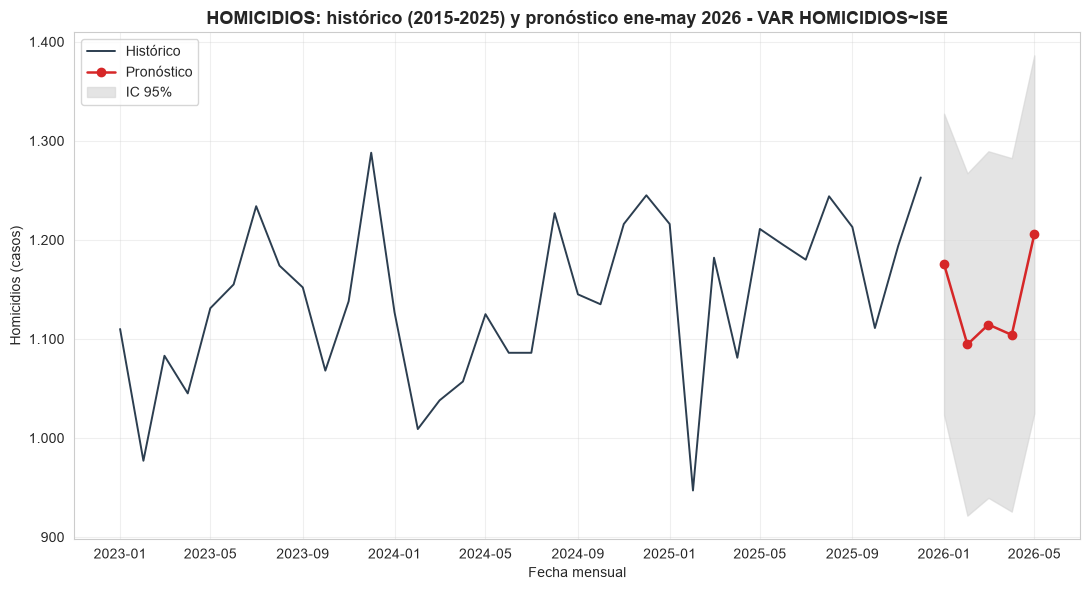

In [43]:

fig = graficar_pronostico(
    y_full, fechas_fc, punto_var, lo_var, hi_var,
    titulo=f"HOMICIDIOS: histórico (2015-2025) y pronóstico ene-may 2026 - {nombre_var}"
)
plt.savefig(RUTA_RESULTADOS / "fig_2_3_3_d_pronostico_var.png", dpi=150)
plt.show()


**e. Métricas de desempeño (vs. observado real 2026)**

In [44]:

metricas_var = calcular_metricas(
    y_test_2026.values, punto_var[:n_eval], y_train_hist=y_full.values
)
tabla_met_var = tabla_metricas(metricas_var, nombre_var)
tabla_met_var


,Modelo,MAE,RMSE,MASE,ME,MAPE,R2
0,VAR HOMICIDIOS~ISE,32.806,37.356,0.434,21.221,2.813,0.196


*Interpretación:* al tratarse de un modelo bivariado más simple que el SARIMAX, se espera comparar si la ganancia (o pérdida) de desempeño del VAR frente a los modelos SARIMA/SARIMAX está asociada al menor número de variables explicativas o a diferencias en la estructura de dependencia temporal que cada familia de modelos es capaz de capturar.

In [45]:

resultados_modelos[nombre_var] = {
    "pronostico": tabla_fc_var,
    "metricas": metricas_var,
    "supuestos": supuestos_var,
    "fechas_fc": fechas_fc,
    "punto_fc": punto_var,
    "lo_fc": lo_var,
    "hi_fc": hi_var,
}


### 2.4 Resumen pronósticos — Modelos de series de tiempo (SARIMA, VAR, SARIMAX)

In [46]:

modelos_estadisticos = [nombre_sarima, nombre_sarimax, nombre_var]

filas_resumen = []
for nombre in modelos_estadisticos:
    r = resultados_modelos[nombre]
    filas_resumen.append({
        "Modelo": nombre,
        **{f"Pronóstico {f.strftime('%Y-%m')}": v for f, v in zip(r["fechas_fc"], r["punto_fc"])},
        "MAE": r["metricas"]["MAE"], "RMSE": r["metricas"]["RMSE"],
        "MASE": r["metricas"]["MASE"], "ME": r["metricas"]["ME"],
        "MAPE": r["metricas"]["MAPE"], "R2": r["metricas"]["R2"],
        "Independencia": "SÍ" if r["supuestos"]["independencia_ok"] else "NO",
        "Normalidad": "SÍ" if r["supuestos"]["normalidad_ok"] else "NO",
        "Homocedasticidad": "SÍ" if r["supuestos"]["homocedasticidad_ok"] else "NO",
    })

tabla_resumen_estadisticos = pd.DataFrame(filas_resumen).round(2)
tabla_resumen_estadisticos


,Modelo,Pronóstico 2026-01,Pronóstico 2026-02,Pronóstico 2026-03,Pronóstico 2026-04,Pronóstico 2026-05,MAE,RMSE,MASE,ME,MAPE,R2,Independencia,Normalidad,Homocedasticidad
0,"SARIMA(2, 0, 1)(0, 1, 2, 12)",1179.91,1012.48,1133.24,1090.45,1197.27,41.04,47.41,0.54,37.33,3.60,-0.30,NO,NO,NO
1,"SARIMAX(2, 0, 1)(0, 1, 2, 12)",1219.33,1040.81,1134.91,1114.92,1211.08,31.55,33.16,0.42,15.79,2.75,0.37,NO,NO,NO
2,VAR HOMICIDIOS~ISE,1175.33,1094.41,1114.52,1104.08,1205.55,32.81,37.36,0.43,21.22,2.81,0.20,SÍ,NO,NO


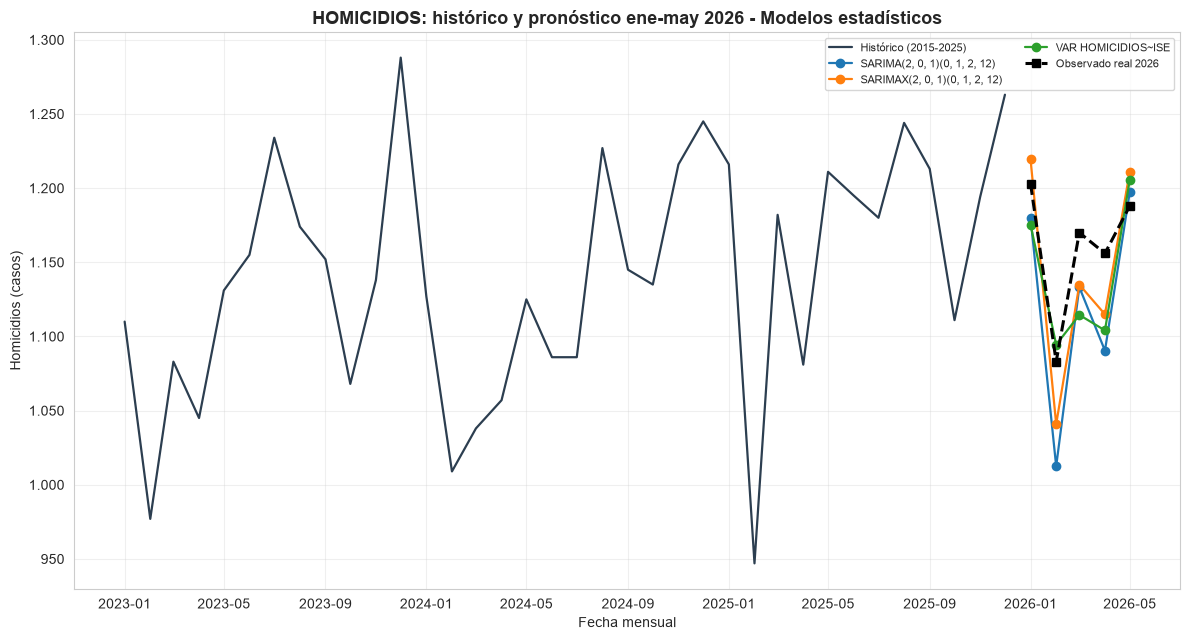

In [47]:

dict_pronosticos_estadisticos = {
    nombre: (resultados_modelos[nombre]["fechas_fc"], resultados_modelos[nombre]["punto_fc"])
    for nombre in modelos_estadisticos
}

fig = graficar_comparacion_modelos(
    y_full, dict_pronosticos_estadisticos,
    titulo="HOMICIDIOS: histórico y pronóstico ene-may 2026 - Modelos estadísticos"
)

ax = fig.axes[0]
ax.plot(y_test_2026.index, y_test_2026.values, color="black", linewidth=2.2,
        linestyle="--", marker="s", markersize=6, zorder=6, label="Observado real 2026")
ax.legend(loc="best", fontsize=8, ncol=2)

plt.savefig(RUTA_RESULTADOS / "fig_2_4_comparacion_estadisticos.png", dpi=150, bbox_inches="tight")
plt.show()



## 3. Modelos de Machine Learning

Se usan los datasets `ts_mensual_2005_2025.csv` (entrenamiento y validación, 2015-2025) y `ts_mensual_2026.csv` (prueba real, enero-mayo de 2026).

**Variables exógenas candidatas:** `HURTO A PERSONAS`, `LESIONES PERSONALES`, `INCAUTACION_KG`, `ISE`, `TASA DESEMPLEO`, `VIOLENCIA INTRAFAMILIAR`. Para cada modelo se evalúan **todas las combinaciones posibles** de estas variables (2⁶ - 1 = 63 combinaciones, más la combinación vacía = solo autorregresivo), cruzadas con una grilla de hiperparámetros.

> ⚠️ Evaluar las 64 combinaciones × grilla de hiperparámetros × 6 algoritmos puede tardar varios minutos localmente. Las grillas se dejaron deliberadamente moderadas para que el notebook sea ejecutable en un equipo estándar; amplíalas en `PARAM_GRID_*` si tu equipo lo permite y tu cronograma de tesis lo justifica.

> ⚠️ Al igual que en la Sección 2, los intervalos de predicción de los modelos de ML (que no generan intervalos nativos, a diferencia de SARIMA/SARIMAX/VAR) se **aproximan** con una distribución normal centrada en el pronóstico puntual, usando la desviación estándar de los residuales del conjunto de validación (`punto ± 1.96 × sd_residual_val`). Esta aproximación debe reportarse como tal en la tesis.

In [48]:

EXOG_CANDIDATAS = ["HURTO A PERSONAS", "LESIONES PERSONALES", "INCAUTACION_KG",
                    "ISE", "TASA DESEMPLEO", "VIOLENCIA INTRAFAMILIAR"]
N_LAGS = 12
FECHA_CORTE_VAL = "2024-01-01"  # a partir de esta fecha, datos de validación (2024-2025)
Z_95 = 1.959963985


def generar_combinaciones_exogenas(vars_candidatas):
    combos = [()]
    for k in range(1, len(vars_candidatas) + 1):
        combos += list(itertools.combinations(vars_candidatas, k))
    return combos


def construir_dataset_supervisado(wide_df, exog_vars, n_lags=N_LAGS, col_objetivo="HOMICIDIOS"):
    df = wide_df.copy()
    feature_cols = []
    for lag in range(1, n_lags + 1):
        col = f"lag_{lag}"
        df[col] = df[col_objetivo].shift(lag)
        feature_cols.append(col)
    for var in exog_vars:
        col = f"{var}_lag1"
        df[col] = df[var].shift(1)
        feature_cols.append(col)
    df["mes"] = df.index.month
    feature_cols.append("mes")

    df_sup = df.dropna(subset=feature_cols + [col_objetivo])
    X = df_sup[feature_cols]
    y = df_sup[col_objetivo]
    return X, y, feature_cols


def pronostico_recursivo_ml(predict_fn, wide_df_hist, exog_vars, feature_cols, n_lags,
                             fechas_fc, exog_futuro, col_objetivo="HOMICIDIOS"):
    """
    predict_fn: función que recibe un DataFrame de 1 fila (columnas=feature_cols) y retorna un escalar.
    """
    historia = wide_df_hist.copy()
    predicciones = []

    for fecha in fechas_fc:
        fila = {}
        for lag in range(1, n_lags + 1):
            fecha_lag = fecha - pd.DateOffset(months=lag)
            fila[f"lag_{lag}"] = historia[col_objetivo].get(fecha_lag, np.nan)
        for var in exog_vars:
            fecha_lag1 = fecha - pd.DateOffset(months=1)
            valor = historia[var].get(fecha_lag1, np.nan) if var in historia.columns else np.nan
            if pd.isna(valor):
                valor = exog_futuro[var].get(fecha_lag1, exog_futuro[var].iloc[-1])
            fila[f"{var}_lag1"] = valor
        fila["mes"] = fecha.month

        X_pred = pd.DataFrame([fila])[feature_cols]
        pred = np.asarray(predict_fn(X_pred)).reshape(-1)[0].item()
        predicciones.append(pred)

        if fecha not in historia.index:
            historia.loc[fecha] = np.nan
        historia.loc[fecha, col_objetivo] = pred
        for var in exog_vars:
            if fecha in exog_futuro.index:
                historia.loc[fecha, var] = exog_futuro[var].loc[fecha]

    return np.array(predicciones)


def buscar_mejor_modelo_supervisado(estimador_cls, param_grid, wide_df, exog_candidatas,
                                     n_lags=N_LAGS, fecha_corte_val=FECHA_CORTE_VAL):
    combinaciones_exog = generar_combinaciones_exogenas(exog_candidatas)
    filas = []

    for exog_vars in combinaciones_exog:
        X, y, feature_cols = construir_dataset_supervisado(wide_df, list(exog_vars), n_lags=n_lags)
        X_tr = X[X.index < fecha_corte_val]
        y_tr = y[y.index < fecha_corte_val]
        X_val = X[X.index >= fecha_corte_val]
        y_val = y[y.index >= fecha_corte_val]
        if len(X_val) == 0 or len(X_tr) == 0:
            continue

        for params in ParameterGrid(param_grid):
            modelo = estimador_cls(**params)
            modelo.fit(X_tr, y_tr)
            pred_val = modelo.predict(X_val)
            rmse_val = float(np.sqrt(mean_squared_error(y_val, pred_val)))
            std_resid_val = float(np.std(y_val.values - pred_val))
            filas.append({
                "exog_vars": exog_vars, "params": params,
                "rmse_val": rmse_val, "std_resid_val": std_resid_val,
                "feature_cols": feature_cols, "n_val": len(X_val)
            })

    tabla_busqueda = pd.DataFrame(filas)
    mejor = tabla_busqueda.loc[tabla_busqueda["rmse_val"].idxmin()].to_dict()
    return mejor, tabla_busqueda


def reportar_modelo_ml(nombre_modelo, punto_fc, std_resid_val, fechas_fc, y_full_serie,
                        n_meses_hist=36, guardar_prefijo=None):
    lo_fc = punto_fc - Z_95 * std_resid_val
    hi_fc = punto_fc + Z_95 * std_resid_val

    for n_meses in range(1, len(fechas_fc) + 1):
        print(f"--- Pronóstico incorporando {n_meses} mes(es): {formato_mes_es(fechas_fc[n_meses-1])} ---")
        for i in range(n_meses):
            print(f"  {fechas_fc[i].strftime('%Y-%m')}: {punto_fc[i]:.1f} "
                  f"[{lo_fc[i]:.1f} - {hi_fc[i]:.1f}]")

    tabla_fc = tabla_pronostico(fechas_fc, punto_fc, lo_fc, hi_fc, nombre_modelo)
    display(tabla_fc)

    fig = graficar_pronostico(
        y_full_serie, fechas_fc, punto_fc, lo_fc, hi_fc,
        titulo=f"HOMICIDIOS: histórico (2015-2025) y pronóstico ene-may 2026 - {nombre_modelo}",
        n_meses_hist=n_meses_hist
    )
    if guardar_prefijo:
        plt.savefig(RUTA_RESULTADOS / f"{guardar_prefijo}_pronostico.png", dpi=150)
    plt.show()

    n_eval = len(y_test_2026)
    metricas = calcular_metricas(y_test_2026.values, punto_fc[:n_eval], y_train_hist=y_full_serie.values)
    tabla_met = tabla_metricas(metricas, nombre_modelo)
    display(tabla_met)

    return tabla_fc, metricas, lo_fc, hi_fc


### 3.1 XGBoost

**Búsqueda de la mejor combinación de variables exógenas e hiperparámetros**

In [49]:

PARAM_GRID_XGB = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "random_state": [SEED],
}

mejor_xgb, tabla_busqueda_xgb = buscar_mejor_modelo_supervisado(
    xgb.XGBRegressor, PARAM_GRID_XGB, wide_hist.loc[:f"{AÑO_FIN}-12-01"], EXOG_CANDIDATAS
)

print("Mejores variables exógenas:", mejor_xgb["exog_vars"])
print("Mejores hiperparámetros:", mejor_xgb["params"])
print("RMSE de validación:", round(mejor_xgb["rmse_val"], 2))

tabla_busqueda_xgb.sort_values("rmse_val").head(10)


Mejores variables exógenas: ('LESIONES PERSONALES', 'TASA DESEMPLEO', 'VIOLENCIA INTRAFAMILIAR')
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'random_state': 42, 'subsample': 0.8}
RMSE de validación: 51.52


,exog_vars,params,rmse_val,std_resid_val,feature_cols,n_val
606,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCI...","{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",51.517415,49.954776,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
604,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCI...","{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",51.526747,49.930660,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
666,"(ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",55.928227,55.877235,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
664,"(ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",56.919054,56.914968,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
252,"(LESIONES PERSONALES, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",57.383984,56.570175,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
254,"(LESIONES PERSONALES, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",57.456725,56.642738,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
971,"(HURTO A PERSONAS, LESIONES PERSONALES, ISE, T...","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",57.843821,57.745543,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
883,"(LESIONES PERSONALES, ISE, TASA DESEMPLEO, VIO...","{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",58.191474,57.874109,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
510,"(HURTO A PERSONAS, TASA DESEMPLEO, VIOLENCIA I...","{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",58.705360,57.399485,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
508,"(HURTO A PERSONAS, TASA DESEMPLEO, VIOLENCIA I...","{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",58.709118,57.404526,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24


In [86]:
import pandas as pd
pd.set_option("display.max_colwidth", None)
tabla_busqueda_xgb.sort_values("rmse_val").head(10)[["exog_vars", "params", "rmse_val", "std_resid_val", "n_val"]]

,exog_vars,params,rmse_val,std_resid_val,n_val
606,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'random_state': 42, 'subsample': 0.8}",51.517415,49.954776,24
604,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'random_state': 42, 'subsample': 0.8}",51.526747,49.930660,24
666,"(ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'random_state': 42, 'subsample': 0.8}",55.928227,55.877235,24
664,"(ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'random_state': 42, 'subsample': 0.8}",56.919054,56.914968,24
252,"(LESIONES PERSONALES, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'random_state': 42, 'subsample': 0.8}",57.383984,56.570175,24
254,"(LESIONES PERSONALES, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'random_state': 42, 'subsample': 0.8}",57.456725,56.642738,24
971,"(HURTO A PERSONAS, LESIONES PERSONALES, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'random_state': 42, 'subsample': 1.0}",57.843821,57.745543,24
883,"(LESIONES PERSONALES, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400, 'random_state': 42, 'subsample': 1.0}",58.191474,57.874109,24
510,"(HURTO A PERSONAS, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'random_state': 42, 'subsample': 0.8}",58.705360,57.399485,24
508,"(HURTO A PERSONAS, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'random_state': 42, 'subsample': 0.8}",58.709118,57.404526,24


**Tabla resumen de hiperparámetros evaluados y seleccionados**

In [50]:

tabla_hiperparametros_xgb = pd.DataFrame([{
    "Modelo": "XGBoost",
    "Variables exógenas seleccionadas": ", ".join(mejor_xgb["exog_vars"]) if mejor_xgb["exog_vars"] else "(ninguna, solo autorregresivo)",
    **mejor_xgb["params"],
    "RMSE validación": round(mejor_xgb["rmse_val"], 3),
    "N combinaciones evaluadas": len(tabla_busqueda_xgb),
}])
tabla_hiperparametros_xgb


,Modelo,Variables exógenas seleccionadas,learning_rate,max_depth,n_estimators,random_state,subsample,RMSE validación,N combinaciones evaluadas
0,XGBoost,"LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCIA...",0.1,5,400,42,0.8,51.517,1024


**Ajuste del modelo final (2015-2025) y gráfico SHAP**

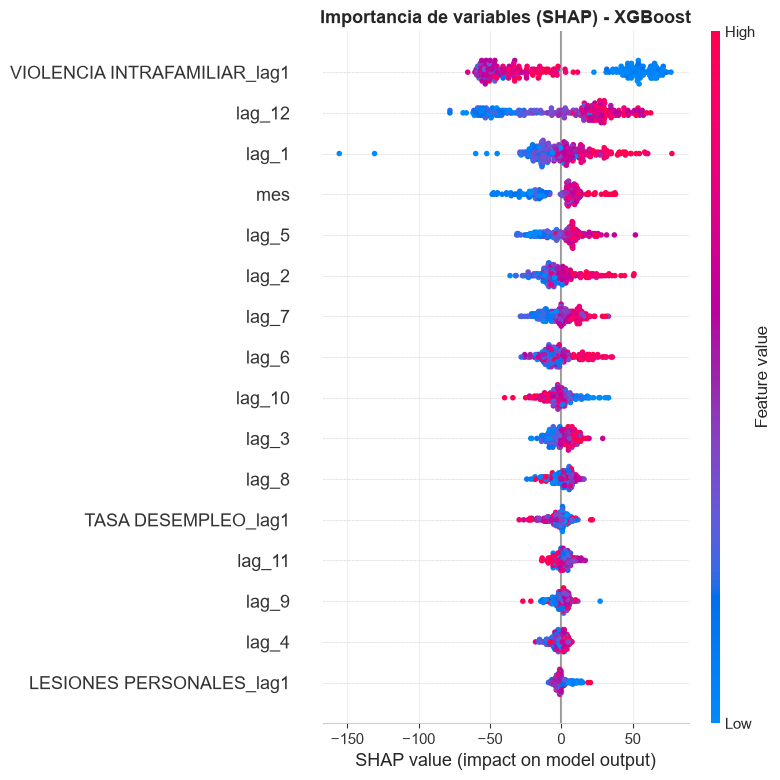

In [51]:

exog_xgb = list(mejor_xgb["exog_vars"])
feature_cols_xgb = mejor_xgb["feature_cols"]

X_full_xgb, y_full_sup_xgb, _ = construir_dataset_supervisado(
    wide_hist.loc[:f"{AÑO_FIN}-12-01"], exog_xgb
)

modelo_final_xgb = xgb.XGBRegressor(**mejor_xgb["params"])
modelo_final_xgb.fit(X_full_xgb, y_full_sup_xgb)

explainer_xgb = shap.TreeExplainer(modelo_final_xgb)
shap_values_xgb = explainer_xgb(X_full_xgb)

shap.summary_plot(shap_values_xgb, X_full_xgb, show=False)
plt.title("Importancia de variables (SHAP) - XGBoost")
plt.tight_layout()
plt.savefig(RUTA_RESULTADOS / "fig_3_1_xgboost_shap.png", dpi=150, bbox_inches="tight")
plt.show()


*Interpretación (SHAP):* el gráfico SHAP ordena las variables según su contribución promedio (en valor absoluto) al pronóstico del modelo. Los rezagos de `HOMICIDIOS` más cercanos (`lag_1`, `lag_12`) suelen concentrar el mayor poder explicativo por la naturaleza autorregresiva y estacional de la serie; las variables exógenas seleccionadas indican qué factores estructurales aportan información adicional una vez controlado por la propia historia de la serie.

**a. Pronóstico enero-mayo de 2026**

--- Pronóstico incorporando 1 mes(es): Enero 2026 ---
  2026-01: 1146.0 [1048.1 - 1243.9]
--- Pronóstico incorporando 2 mes(es): Febrero 2026 ---
  2026-01: 1146.0 [1048.1 - 1243.9]
  2026-02: 1055.2 [957.3 - 1153.1]
--- Pronóstico incorporando 3 mes(es): Marzo 2026 ---
  2026-01: 1146.0 [1048.1 - 1243.9]
  2026-02: 1055.2 [957.3 - 1153.1]
  2026-03: 1120.7 [1022.8 - 1218.6]
--- Pronóstico incorporando 4 mes(es): Abril 2026 ---
  2026-01: 1146.0 [1048.1 - 1243.9]
  2026-02: 1055.2 [957.3 - 1153.1]
  2026-03: 1120.7 [1022.8 - 1218.6]
  2026-04: 1084.0 [986.1 - 1181.9]
--- Pronóstico incorporando 5 mes(es): Mayo 2026 ---
  2026-01: 1146.0 [1048.1 - 1243.9]
  2026-02: 1055.2 [957.3 - 1153.1]
  2026-03: 1120.7 [1022.8 - 1218.6]
  2026-04: 1084.0 [986.1 - 1181.9]
  2026-05: 1127.7 [1029.8 - 1225.6]


,Modelo,fecha_mensual,pronostico,lim_inf_95,lim_sup_95
0,XGBoost,2026-01-01,1146.0,1048.1,1243.9
1,XGBoost,2026-02-01,1055.2,957.3,1153.1
2,XGBoost,2026-03-01,1120.7,1022.8,1218.6
3,XGBoost,2026-04-01,1084.0,986.1,1181.9
4,XGBoost,2026-05-01,1127.7,1029.8,1225.6


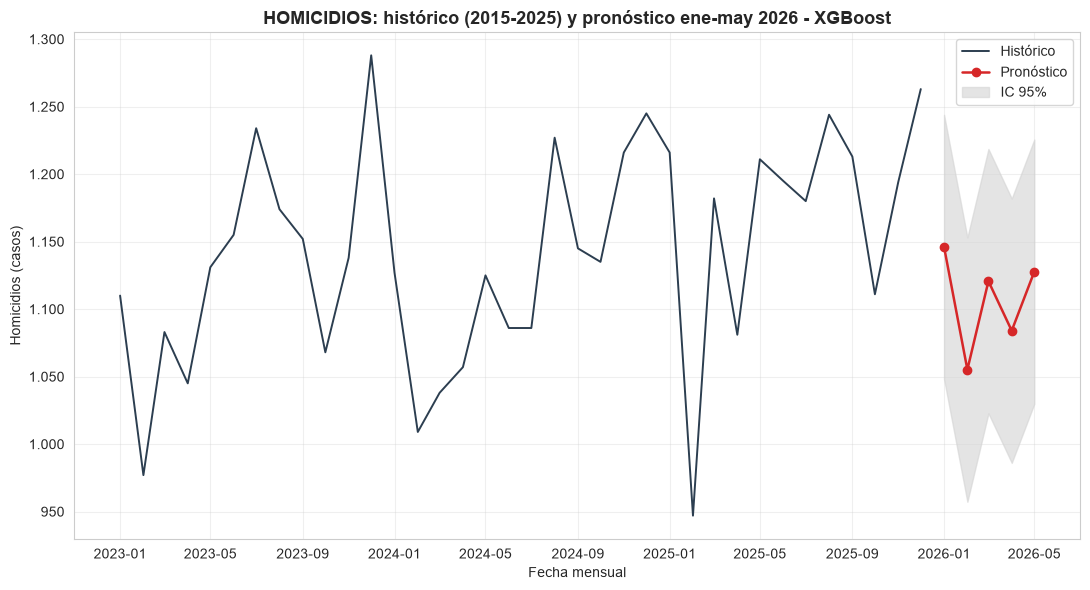

,Modelo,MAE,RMSE,MASE,ME,MAPE,R2
0,XGBoost,53.278,55.262,0.705,53.278,4.564,-0.76


In [52]:

exog_futuro_xgb = preparar_exogenas_futuras(
    wide_hist, exog_xgb, fechas_fc, metodo="ultimo_valor"
) if exog_xgb else pd.DataFrame(index=fechas_fc)

punto_xgb = pronostico_recursivo_ml(
    lambda X: modelo_final_xgb.predict(X)[0],
    wide_hist.loc[:f"{AÑO_FIN}-12-01"], exog_xgb, feature_cols_xgb, N_LAGS,
    fechas_fc, exog_futuro_xgb
)

tabla_fc_xgb, metricas_xgb, lo_xgb, hi_xgb = reportar_modelo_ml(
    "XGBoost", punto_xgb, mejor_xgb["std_resid_val"], fechas_fc, y_full,
    guardar_prefijo="fig_3_1_xgboost"
)


**b. Métricas de desempeño e interpretación**

*Interpretación:* al igual que en los modelos estadísticos, MAE/RMSE cuantifican el error en la escala original (casos), MASE lo compara contra un pronóstico ingenuo estacional, ME indica el sesgo del pronóstico (sobre- o sub-estimación sistemática), MAPE expresa el error en términos porcentuales, y R² resume qué proporción de la variabilidad observada en los 5 meses de prueba logra explicar el modelo (con la cautela habitual dado el tamaño reducido de la muestra de prueba).

In [53]:

resultados_modelos["XGBoost"] = {
    "pronostico": tabla_fc_xgb,
    "metricas": metricas_xgb,
    "fechas_fc": fechas_fc,
    "punto_fc": punto_xgb,
    "lo_fc": lo_xgb,
    "hi_fc": hi_xgb,
    "hiperparametros": tabla_hiperparametros_xgb,
}


### 3.2 LightGBM

**Búsqueda de la mejor combinación de variables exógenas e hiperparámetros**

In [54]:

PARAM_GRID_LGB = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [15, 31],
    "random_state": [SEED],
    "verbosity": [-1],
}

mejor_lgb, tabla_busqueda_lgb = buscar_mejor_modelo_supervisado(
    lgb.LGBMRegressor, PARAM_GRID_LGB, wide_hist.loc[:f"{AÑO_FIN}-12-01"], EXOG_CANDIDATAS
)

print("Mejores variables exógenas:", mejor_lgb["exog_vars"])
print("Mejores hiperparámetros:", mejor_lgb["params"])
print("RMSE de validación:", round(mejor_lgb["rmse_val"], 2))

tabla_busqueda_lgb.sort_values("rmse_val").head(10)


Mejores variables exógenas: ('HURTO A PERSONAS', 'ISE', 'TASA DESEMPLEO', 'VIOLENCIA INTRAFAMILIAR')
Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15, 'random_state': 42, 'verbosity': -1}
RMSE de validación: 60.43


,exog_vars,params,rmse_val,std_resid_val,feature_cols,n_val
817,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",60.434667,60.370290,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
816,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",60.434667,60.370290,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
824,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",60.476911,60.049112,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
825,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",60.476911,60.049112,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
865,"(LESIONES PERSONALES, INCAUTACION_KG, TASA DES...","{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",60.492375,60.467669,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
864,"(LESIONES PERSONALES, INCAUTACION_KG, TASA DES...","{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",60.492375,60.467669,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
475,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO)","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",60.895908,60.746457,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
474,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO)","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",60.895908,60.746457,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
961,"(HURTO A PERSONAS, LESIONES PERSONALES, ISE, T...","{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",60.947578,60.822686,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
960,"(HURTO A PERSONAS, LESIONES PERSONALES, ISE, T...","{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",60.947578,60.822686,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24


**Tabla resumen de hiperparámetros evaluados y seleccionados**

In [55]:

tabla_hiperparametros_lgb = pd.DataFrame([{
    "Modelo": "LightGBM",
    "Variables exógenas seleccionadas": ", ".join(mejor_lgb["exog_vars"]) if mejor_lgb["exog_vars"] else "(ninguna, solo autorregresivo)",
    **mejor_lgb["params"],
    "RMSE validación": round(mejor_lgb["rmse_val"], 3),
    "N combinaciones evaluadas": len(tabla_busqueda_lgb),
}])
tabla_hiperparametros_lgb


,Modelo,Variables exógenas seleccionadas,learning_rate,max_depth,n_estimators,num_leaves,random_state,verbosity,RMSE validación,N combinaciones evaluadas
0,LightGBM,"HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENC...",0.05,3,200,15,42,-1,60.435,1024


In [87]:
import pandas as pd
pd.set_option("display.max_colwidth", None)
tabla_busqueda_lgb.sort_values("rmse_val").head(10)[["exog_vars", "params", "rmse_val", "std_resid_val", "n_val"]]

,exog_vars,params,rmse_val,std_resid_val,n_val
817,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 31, 'random_state': 42, 'verbosity': -1}",60.434667,60.370290,24
816,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15, 'random_state': 42, 'verbosity': -1}",60.434667,60.370290,24
824,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15, 'random_state': 42, 'verbosity': -1}",60.476911,60.049112,24
825,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 31, 'random_state': 42, 'verbosity': -1}",60.476911,60.049112,24
865,"(LESIONES PERSONALES, INCAUTACION_KG, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 31, 'random_state': 42, 'verbosity': -1}",60.492375,60.467669,24
864,"(LESIONES PERSONALES, INCAUTACION_KG, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15, 'random_state': 42, 'verbosity': -1}",60.492375,60.467669,24
475,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO)","{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'num_leaves': 31, 'random_state': 42, 'verbosity': -1}",60.895908,60.746457,24
474,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO)","{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'num_leaves': 15, 'random_state': 42, 'verbosity': -1}",60.895908,60.746457,24
961,"(HURTO A PERSONAS, LESIONES PERSONALES, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 31, 'random_state': 42, 'verbosity': -1}",60.947578,60.822686,24
960,"(HURTO A PERSONAS, LESIONES PERSONALES, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15, 'random_state': 42, 'verbosity': -1}",60.947578,60.822686,24


**Ajuste del modelo final (2015-2025) y gráfico SHAP**

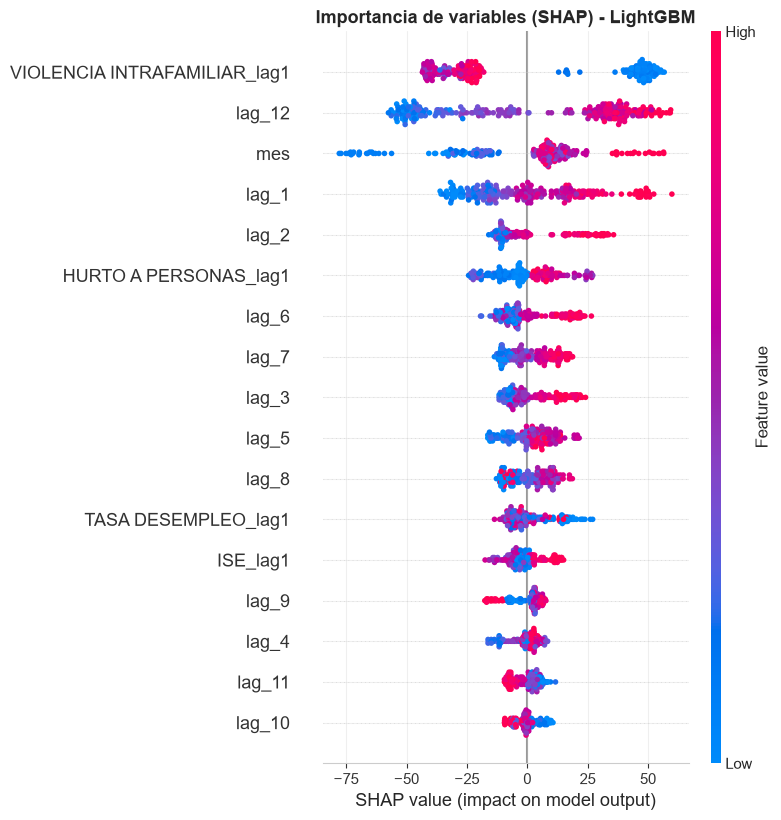

In [56]:

exog_lgb = list(mejor_lgb["exog_vars"])
feature_cols_lgb = mejor_lgb["feature_cols"]

X_full_lgb, y_full_sup_lgb, _ = construir_dataset_supervisado(
    wide_hist.loc[:f"{AÑO_FIN}-12-01"], exog_lgb
)

modelo_final_lgb = lgb.LGBMRegressor(**mejor_lgb["params"])
modelo_final_lgb.fit(X_full_lgb, y_full_sup_lgb)

explainer_lgb = shap.TreeExplainer(modelo_final_lgb)
shap_values_lgb = explainer_lgb(X_full_lgb)

shap.summary_plot(shap_values_lgb, X_full_lgb, show=False)
plt.title("Importancia de variables (SHAP) - LightGBM")
plt.tight_layout()
plt.savefig(RUTA_RESULTADOS / "fig_3_2_lightgbm_shap.png", dpi=150, bbox_inches="tight")
plt.show()


*Interpretación (SHAP):* el gráfico SHAP ordena las variables según su contribución promedio (en valor absoluto) al pronóstico del modelo. Los rezagos de `HOMICIDIOS` más cercanos (`lag_1`, `lag_12`) suelen concentrar el mayor poder explicativo por la naturaleza autorregresiva y estacional de la serie; las variables exógenas seleccionadas indican qué factores estructurales aportan información adicional una vez controlado por la propia historia de la serie.

**a. Pronóstico enero-mayo de 2026**

--- Pronóstico incorporando 1 mes(es): Enero 2026 ---
  2026-01: 1183.2 [1064.8 - 1301.5]
--- Pronóstico incorporando 2 mes(es): Febrero 2026 ---
  2026-01: 1183.2 [1064.8 - 1301.5]
  2026-02: 1074.6 [956.3 - 1193.0]
--- Pronóstico incorporando 3 mes(es): Marzo 2026 ---
  2026-01: 1183.2 [1064.8 - 1301.5]
  2026-02: 1074.6 [956.3 - 1193.0]
  2026-03: 1197.3 [1078.9 - 1315.6]
--- Pronóstico incorporando 4 mes(es): Abril 2026 ---
  2026-01: 1183.2 [1064.8 - 1301.5]
  2026-02: 1074.6 [956.3 - 1193.0]
  2026-03: 1197.3 [1078.9 - 1315.6]
  2026-04: 1144.3 [1026.0 - 1262.6]
--- Pronóstico incorporando 5 mes(es): Mayo 2026 ---
  2026-01: 1183.2 [1064.8 - 1301.5]
  2026-02: 1074.6 [956.3 - 1193.0]
  2026-03: 1197.3 [1078.9 - 1315.6]
  2026-04: 1144.3 [1026.0 - 1262.6]
  2026-05: 1193.9 [1075.6 - 1312.2]


,Modelo,fecha_mensual,pronostico,lim_inf_95,lim_sup_95
0,LightGBM,2026-01-01,1183.2,1064.8,1301.5
1,LightGBM,2026-02-01,1074.6,956.3,1193.0
2,LightGBM,2026-03-01,1197.3,1078.9,1315.6
3,LightGBM,2026-04-01,1144.3,1026.0,1262.6
4,LightGBM,2026-05-01,1193.9,1075.6,1312.2


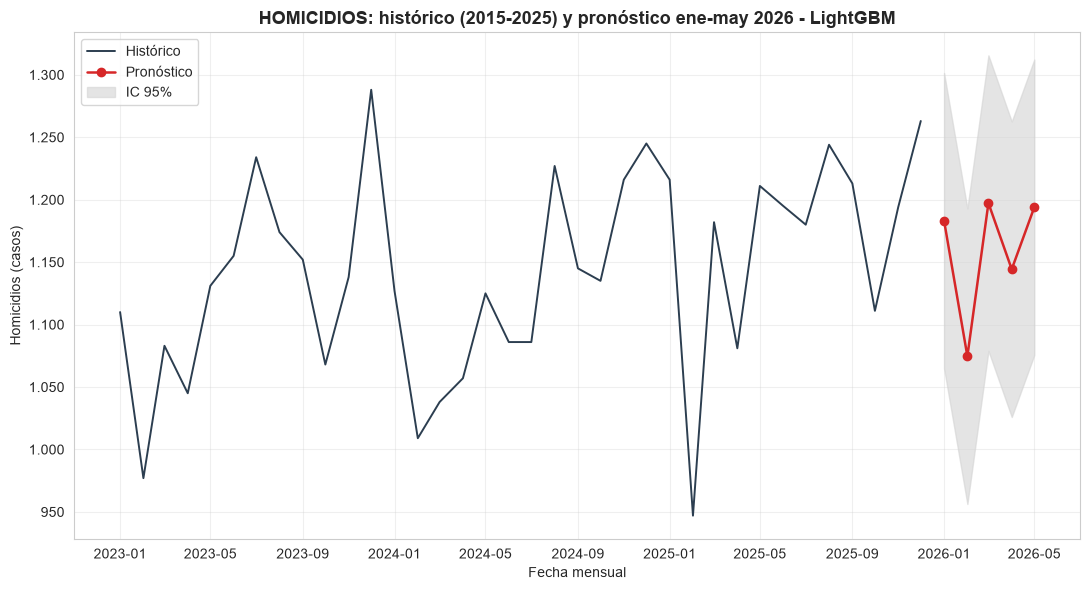

,Modelo,MAE,RMSE,MASE,ME,MAPE,R2
0,LightGBM,14.615,16.605,0.194,1.348,1.252,0.841


In [57]:

exog_futuro_lgb = preparar_exogenas_futuras(
    wide_hist, exog_lgb, fechas_fc, metodo="ultimo_valor"
) if exog_lgb else pd.DataFrame(index=fechas_fc)

punto_lgb = pronostico_recursivo_ml(
    lambda X: modelo_final_lgb.predict(X)[0],
    wide_hist.loc[:f"{AÑO_FIN}-12-01"], exog_lgb, feature_cols_lgb, N_LAGS,
    fechas_fc, exog_futuro_lgb
)

tabla_fc_lgb, metricas_lgb, lo_lgb, hi_lgb = reportar_modelo_ml(
    "LightGBM", punto_lgb, mejor_lgb["std_resid_val"], fechas_fc, y_full,
    guardar_prefijo="fig_3_2_lightgbm"
)


**b. Métricas de desempeño e interpretación**

*Interpretación:* al igual que en los modelos estadísticos, MAE/RMSE cuantifican el error en la escala original (casos), MASE lo compara contra un pronóstico ingenuo estacional, ME indica el sesgo del pronóstico (sobre- o sub-estimación sistemática), MAPE expresa el error en términos porcentuales, y R² resume qué proporción de la variabilidad observada en los 5 meses de prueba logra explicar el modelo (con la cautela habitual dado el tamaño reducido de la muestra de prueba).

In [58]:

resultados_modelos["LightGBM"] = {
    "pronostico": tabla_fc_lgb,
    "metricas": metricas_lgb,
    "fechas_fc": fechas_fc,
    "punto_fc": punto_lgb,
    "lo_fc": lo_lgb,
    "hi_fc": hi_lgb,
    "hiperparametros": tabla_hiperparametros_lgb,
}


### 3.3 Random Forest

**Búsqueda de la mejor combinación de variables exógenas e hiperparámetros**

In [59]:

PARAM_GRID_RF = {
    "n_estimators": [300, 500],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 3],
    "random_state": [SEED],
}

mejor_rf, tabla_busqueda_rf = buscar_mejor_modelo_supervisado(
    RandomForestRegressor, PARAM_GRID_RF, wide_hist.loc[:f"{AÑO_FIN}-12-01"], EXOG_CANDIDATAS
)

print("Mejores variables exógenas:", mejor_rf["exog_vars"])
print("Mejores hiperparámetros:", mejor_rf["params"])
print("RMSE de validación:", round(mejor_rf["rmse_val"], 2))

tabla_busqueda_rf.sort_values("rmse_val").head(10)


Mejores variables exógenas: ('INCAUTACION_KG', 'ISE', 'VIOLENCIA INTRAFAMILIAR')
Mejores hiperparámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300, 'random_state': 42}
RMSE de validación: 66.8


,exog_vars,params,rmse_val,std_resid_val,feature_cols,n_val
472,"(INCAUTACION_KG, ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",66.799589,64.751255,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
473,"(INCAUTACION_KG, ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",66.941167,64.526795,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
500,"(ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'max_depth': None, 'min_samples_leaf': 1, 'n_...",66.949433,64.359831,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
680,"(INCAUTACION_KG, ISE, TASA DESEMPLEO, VIOLENCI...","{'max_depth': None, 'min_samples_leaf': 1, 'n_...",66.984132,64.444245,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
476,"(INCAUTACION_KG, ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': None, 'min_samples_leaf': 1, 'n_...",67.062689,64.988438,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
676,"(INCAUTACION_KG, ISE, TASA DESEMPLEO, VIOLENCI...","{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",67.317045,64.731185,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
477,"(INCAUTACION_KG, ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': None, 'min_samples_leaf': 1, 'n_...",67.355145,64.984005,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
245,"(ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",67.371740,64.957276,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
249,"(ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': None, 'min_samples_leaf': 1, 'n_...",67.380443,64.920494,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24
244,"(ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",67.405450,65.266430,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",24


In [88]:
import pandas as pd
pd.set_option("display.max_colwidth", None)
tabla_busqueda_rf.sort_values("rmse_val").head(10)[["exog_vars", "params", "rmse_val", "std_resid_val", "n_val"]]

,exog_vars,params,rmse_val,std_resid_val,n_val
472,"(INCAUTACION_KG, ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300, 'random_state': 42}",66.799589,64.751255,24
473,"(INCAUTACION_KG, ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 500, 'random_state': 42}",66.941167,64.526795,24
500,"(ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300, 'random_state': 42}",66.949433,64.359831,24
680,"(INCAUTACION_KG, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300, 'random_state': 42}",66.984132,64.444245,24
476,"(INCAUTACION_KG, ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300, 'random_state': 42}",67.062689,64.988438,24
676,"(INCAUTACION_KG, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300, 'random_state': 42}",67.317045,64.731185,24
477,"(INCAUTACION_KG, ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 500, 'random_state': 42}",67.355145,64.984005,24
245,"(ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 500, 'random_state': 42}",67.371740,64.957276,24
249,"(ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 500, 'random_state': 42}",67.380443,64.920494,24
244,"(ISE, VIOLENCIA INTRAFAMILIAR)","{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300, 'random_state': 42}",67.405450,65.266430,24


**Tabla resumen de hiperparámetros evaluados y seleccionados**

In [60]:

tabla_hiperparametros_rf = pd.DataFrame([{
    "Modelo": "Random Forest",
    "Variables exógenas seleccionadas": ", ".join(mejor_rf["exog_vars"]) if mejor_rf["exog_vars"] else "(ninguna, solo autorregresivo)",
    **mejor_rf["params"],
    "RMSE validación": round(mejor_rf["rmse_val"], 3),
    "N combinaciones evaluadas": len(tabla_busqueda_rf),
}])
tabla_hiperparametros_rf


,Modelo,Variables exógenas seleccionadas,max_depth,min_samples_leaf,n_estimators,random_state,RMSE validación,N combinaciones evaluadas
0,Random Forest,"INCAUTACION_KG, ISE, VIOLENCIA INTRAFAMILIAR",10,1,300,42,66.8,768


**Ajuste del modelo final (2015-2025) y gráfico SHAP**

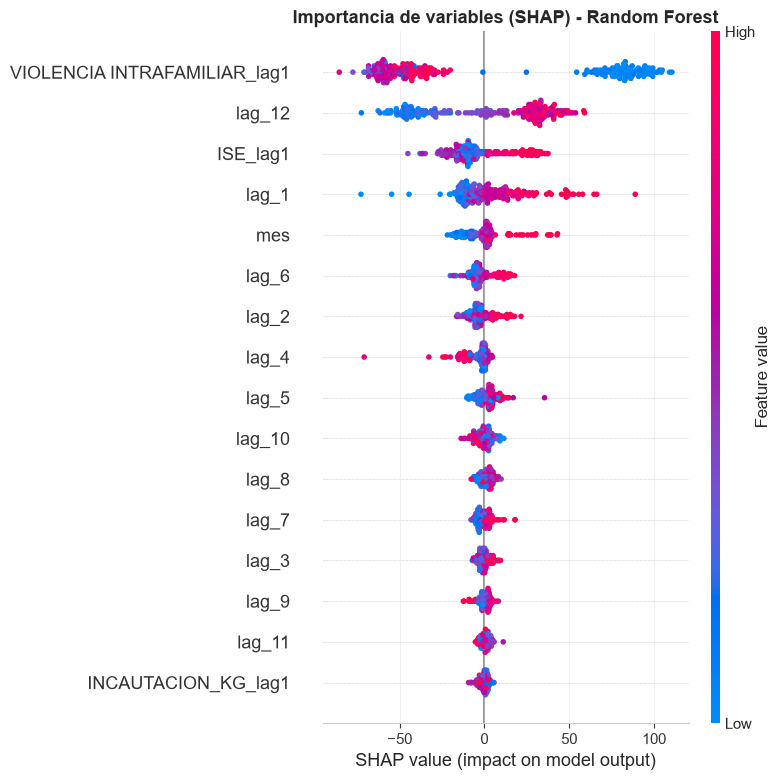

In [61]:

exog_rf = list(mejor_rf["exog_vars"])
feature_cols_rf = mejor_rf["feature_cols"]

X_full_rf, y_full_sup_rf, _ = construir_dataset_supervisado(
    wide_hist.loc[:f"{AÑO_FIN}-12-01"], exog_rf
)

modelo_final_rf = RandomForestRegressor(**mejor_rf["params"])
modelo_final_rf.fit(X_full_rf, y_full_sup_rf)

explainer_rf = shap.TreeExplainer(modelo_final_rf)
shap_values_rf = explainer_rf(X_full_rf)

shap.summary_plot(shap_values_rf, X_full_rf, show=False)
plt.title("Importancia de variables (SHAP) - Random Forest")
plt.tight_layout()
plt.savefig(RUTA_RESULTADOS / "fig_3_3_randomforest_shap.png", dpi=150, bbox_inches="tight")
plt.show()


*Interpretación (SHAP):* el gráfico SHAP ordena las variables según su contribución promedio (en valor absoluto) al pronóstico del modelo. Los rezagos de `HOMICIDIOS` más cercanos (`lag_1`, `lag_12`) suelen concentrar el mayor poder explicativo por la naturaleza autorregresiva y estacional de la serie; las variables exógenas seleccionadas indican qué factores estructurales aportan información adicional una vez controlado por la propia historia de la serie.

**a. Pronóstico enero-mayo de 2026**

--- Pronóstico incorporando 1 mes(es): Enero 2026 ---
  2026-01: 1160.7 [1033.8 - 1287.6]
--- Pronóstico incorporando 2 mes(es): Febrero 2026 ---
  2026-01: 1160.7 [1033.8 - 1287.6]
  2026-02: 1089.1 [962.2 - 1216.0]
--- Pronóstico incorporando 3 mes(es): Marzo 2026 ---
  2026-01: 1160.7 [1033.8 - 1287.6]
  2026-02: 1089.1 [962.2 - 1216.0]
  2026-03: 1153.9 [1027.0 - 1280.8]
--- Pronóstico incorporando 4 mes(es): Abril 2026 ---
  2026-01: 1160.7 [1033.8 - 1287.6]
  2026-02: 1089.1 [962.2 - 1216.0]
  2026-03: 1153.9 [1027.0 - 1280.8]
  2026-04: 1102.8 [975.9 - 1229.7]
--- Pronóstico incorporando 5 mes(es): Mayo 2026 ---
  2026-01: 1160.7 [1033.8 - 1287.6]
  2026-02: 1089.1 [962.2 - 1216.0]
  2026-03: 1153.9 [1027.0 - 1280.8]
  2026-04: 1102.8 [975.9 - 1229.7]
  2026-05: 1149.2 [1022.3 - 1276.1]


,Modelo,fecha_mensual,pronostico,lim_inf_95,lim_sup_95
0,Random Forest,2026-01-01,1160.7,1033.8,1287.6
1,Random Forest,2026-02-01,1089.1,962.2,1216.0
2,Random Forest,2026-03-01,1153.9,1027.0,1280.8
3,Random Forest,2026-04-01,1102.8,975.9,1229.7
4,Random Forest,2026-05-01,1149.2,1022.3,1276.1


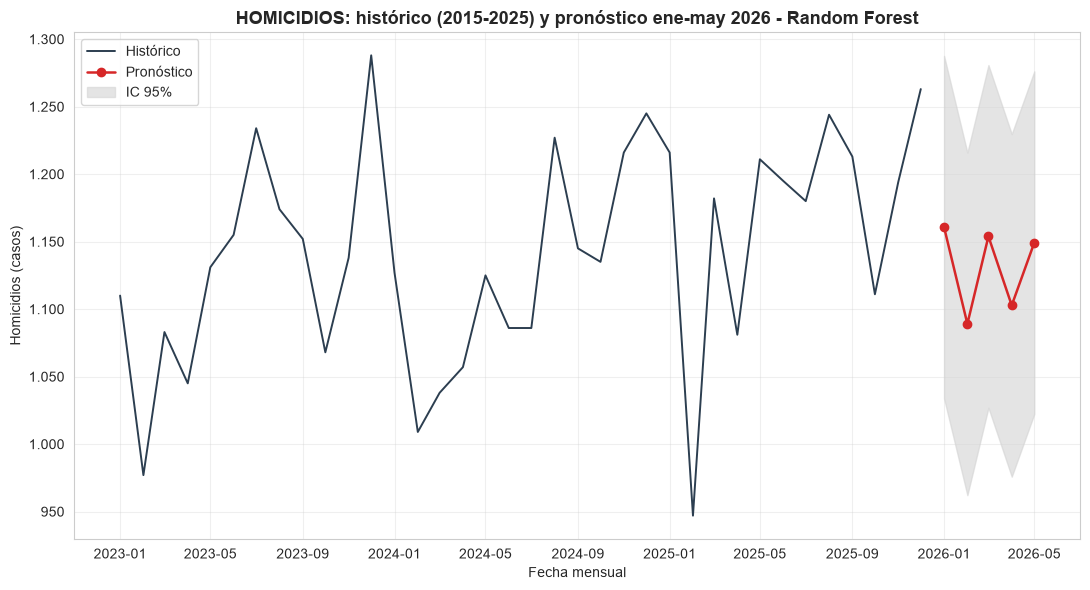

,Modelo,MAE,RMSE,MASE,ME,MAPE,R2
0,Random Forest,31.303,35.843,0.414,28.878,2.665,0.26


In [62]:

exog_futuro_rf = preparar_exogenas_futuras(
    wide_hist, exog_rf, fechas_fc, metodo="ultimo_valor"
) if exog_rf else pd.DataFrame(index=fechas_fc)

punto_rf = pronostico_recursivo_ml(
    lambda X: modelo_final_rf.predict(X)[0],
    wide_hist.loc[:f"{AÑO_FIN}-12-01"], exog_rf, feature_cols_rf, N_LAGS,
    fechas_fc, exog_futuro_rf
)

tabla_fc_rf, metricas_rf, lo_rf, hi_rf = reportar_modelo_ml(
    "Random Forest", punto_rf, mejor_rf["std_resid_val"], fechas_fc, y_full,
    guardar_prefijo="fig_3_3_randomforest"
)


**b. Métricas de desempeño e interpretación**

*Interpretación:* al igual que en los modelos estadísticos, MAE/RMSE cuantifican el error en la escala original (casos), MASE lo compara contra un pronóstico ingenuo estacional, ME indica el sesgo del pronóstico (sobre- o sub-estimación sistemática), MAPE expresa el error en términos porcentuales, y R² resume qué proporción de la variabilidad observada en los 5 meses de prueba logra explicar el modelo (con la cautela habitual dado el tamaño reducido de la muestra de prueba).

In [63]:

resultados_modelos["Random Forest"] = {
    "pronostico": tabla_fc_rf,
    "metricas": metricas_rf,
    "fechas_fc": fechas_fc,
    "punto_fc": punto_rf,
    "lo_fc": lo_rf,
    "hi_fc": hi_rf,
    "hiperparametros": tabla_hiperparametros_rf,
}


### Funciones auxiliares para los modelos recurrentes (LSTM / GRU)

Ambos modelos comparten la misma arquitectura (una rama recurrente sobre los 12 rezagos de `HOMICIDIOS` + una rama densa sobre las variables exógenas y el mes), por lo que se define una única función constructora parametrizada por el tipo de celda.

> ⚠️ Por el costo computacional de entrenar redes recurrentes, la búsqueda de variables exógenas para LSTM/GRU no evalúa las 64 combinaciones posibles, sino un subconjunto informado: sin exógenas, con todas las exógenas, y con las combinaciones ya identificadas como mejores por XGBoost, LightGBM y Random Forest. Amplía `combos_dl` si tu equipo tiene capacidad para una búsqueda más exhaustiva.

In [64]:

def construir_arrays_secuencia(X, feature_cols, n_lags, exog_vars):
    lag_cols = [f"lag_{i}" for i in range(1, n_lags + 1)]
    lag_cols_ordenados = list(reversed(lag_cols))  # cronológico: más antiguo -> más reciente
    X_seq = X[lag_cols_ordenados].values.reshape(-1, n_lags, 1).astype("float32")
    otras_cols = [c for c in feature_cols if c not in lag_cols]
    X_otras = X[otras_cols].values.astype("float32")
    return X_seq, X_otras, otras_cols


def construir_modelo_rnn(tipo_celda, n_lags, n_otras, unidades=32, dropout=0.1, learning_rate=1e-3):
    entrada_seq = layers.Input(shape=(n_lags, 1), name="secuencia_lags")
    capa_rnn = layers.LSTM if tipo_celda == "LSTM" else layers.GRU
    x = capa_rnn(unidades, dropout=dropout)(entrada_seq)

    entrada_otras = layers.Input(shape=(n_otras,), name="exogenas_mes")
    y_ = layers.Dense(8, activation="relu")(entrada_otras)

    concat = layers.Concatenate()([x, y_])
    salida = layers.Dense(1, name="pronostico")(concat)

    modelo = keras.Model(inputs=[entrada_seq, entrada_otras], outputs=salida)
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate), loss="mse")
    return modelo


def buscar_mejor_modelo_rnn(tipo_celda, combos_exog, param_grid, wide_df,
                             n_lags=N_LAGS, fecha_corte_val=FECHA_CORTE_VAL, verbose=0):
    filas = []
    for exog_vars in combos_exog:
        X, y, feature_cols = construir_dataset_supervisado(wide_df, list(exog_vars), n_lags=n_lags)
        X_seq, X_otras, otras_cols = construir_arrays_secuencia(X, feature_cols, n_lags, list(exog_vars))

        idx_tr = np.asarray(X.index < fecha_corte_val)
        idx_val = ~idx_tr
        if idx_val.sum() == 0 or idx_tr.sum() == 0:
            continue

        for params in ParameterGrid(param_grid):
            keras.backend.clear_session()
            modelo = construir_modelo_rnn(
                tipo_celda, n_lags, X_otras.shape[1],
                unidades=params["unidades"], dropout=params["dropout"],
                learning_rate=params.get("learning_rate", 1e-3)
            )
            modelo.fit(
                [X_seq[idx_tr], X_otras[idx_tr]], y.values[idx_tr],
                epochs=params.get("epochs", 60), batch_size=params.get("batch_size", 8),
                verbose=verbose
            )
            pred_val = modelo.predict([X_seq[idx_val], X_otras[idx_val]], verbose=0).flatten()
            rmse_val = float(np.sqrt(mean_squared_error(y.values[idx_val], pred_val)))
            std_resid_val = float(np.std(y.values[idx_val] - pred_val))
            filas.append({
                "exog_vars": exog_vars, "params": params,
                "rmse_val": rmse_val, "std_resid_val": std_resid_val,
                "feature_cols": feature_cols, "otras_cols": otras_cols, "n_val": int(idx_val.sum())
            })

    tabla = pd.DataFrame(filas)
    mejor = tabla.loc[tabla["rmse_val"].idxmin()].to_dict()
    return mejor, tabla


def predict_fn_rnn(modelo, feature_cols, n_lags, otras_cols):
    lag_cols_ordenados = list(reversed([f"lag_{i}" for i in range(1, n_lags + 1)]))

    def _predict(X_df_or_array):
        if isinstance(X_df_or_array, np.ndarray):
            X_df_or_array = pd.DataFrame(X_df_or_array, columns=feature_cols)
        X_seq = X_df_or_array[lag_cols_ordenados].values.reshape(-1, n_lags, 1).astype("float32")
        X_otras = X_df_or_array[otras_cols].values.astype("float32")
        return modelo.predict([X_seq, X_otras], verbose=0).flatten()

    return _predict


### 3.4 LSTM

**Búsqueda de la mejor combinación de variables exógenas e hiperparámetros**

In [65]:

combos_dl = sorted(set([
    tuple(), tuple(EXOG_CANDIDATAS),
    tuple(mejor_xgb["exog_vars"]), tuple(mejor_lgb["exog_vars"]), tuple(mejor_rf["exog_vars"]),
]), key=len)

PARAM_GRID_LSTM = {
    "unidades": [16, 32],
    "dropout": [0.0, 0.2],
    "epochs": [60],
    "batch_size": [8],
    "learning_rate": [0.01],
}

mejor_lstm, tabla_busqueda_lstm = buscar_mejor_modelo_rnn(
    "LSTM", combos_dl, PARAM_GRID_LSTM, wide_hist.loc[:f"{AÑO_FIN}-12-01"]
)

print("Mejores variables exógenas:", mejor_lstm["exog_vars"])
print("Mejores hiperparámetros:", mejor_lstm["params"])
print("RMSE de validación:", round(mejor_lstm["rmse_val"], 2))

tabla_busqueda_lstm.sort_values("rmse_val")



Mejores variables exógenas: ('HURTO A PERSONAS', 'ISE', 'TASA DESEMPLEO', 'VIOLENCIA INTRAFAMILIAR')
Mejores hiperparámetros: {'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 32}
RMSE de validación: 117.7


,exog_vars,params,rmse_val,std_resid_val,feature_cols,otras_cols,n_val
13,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60...",117.703351,113.564809,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[HURTO A PERSONAS_lag1, ISE_lag1, TASA DESEMPL...",24
8,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCI...","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60...",133.233915,120.631238,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[LESIONES PERSONALES_lag1, TASA DESEMPLEO_lag1...",24
16,"(HURTO A PERSONAS, LESIONES PERSONALES, INCAUT...","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60...",182.999423,181.462434,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[HURTO A PERSONAS_lag1, LESIONES PERSONALES_la...",24
12,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60...",203.282981,100.578258,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[HURTO A PERSONAS_lag1, ISE_lag1, TASA DESEMPL...",24
15,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60...",207.411537,103.827362,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[HURTO A PERSONAS_lag1, ISE_lag1, TASA DESEMPL...",24
14,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60...",219.017217,98.774113,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[HURTO A PERSONAS_lag1, ISE_lag1, TASA DESEMPL...",24
11,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCI...","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60...",224.062250,141.030708,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[LESIONES PERSONALES_lag1, TASA DESEMPLEO_lag1...",24
9,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCI...","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60...",263.436159,136.665040,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[LESIONES PERSONALES_lag1, TASA DESEMPLEO_lag1...",24
0,(),"{'batch_size': 8, 'dropout': 0.0, 'epochs': 60...",286.496280,263.730372,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",[mes],24
2,(),"{'batch_size': 8, 'dropout': 0.2, 'epochs': 60...",304.418232,277.105669,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",[mes],24


In [89]:
import pandas as pd
pd.set_option("display.max_colwidth", None)
tabla_busqueda_lstm.sort_values("rmse_val").head(10)[["exog_vars", "params", "rmse_val", "std_resid_val", "n_val"]]

,exog_vars,params,rmse_val,std_resid_val,n_val
13,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 32}",117.703351,113.564809,24
8,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 16}",133.233915,120.631238,24
16,"(HURTO A PERSONAS, LESIONES PERSONALES, INCAUTACION_KG, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 16}",182.999423,181.462434,24
12,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 16}",203.282981,100.578258,24
15,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 32}",207.411537,103.827362,24
14,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 16}",219.017217,98.774113,24
11,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 32}",224.062250,141.030708,24
9,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 32}",263.436159,136.665040,24
0,(),"{'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 16}",286.496280,263.730372,24
2,(),"{'batch_size': 8, 'dropout': 0.2, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 16}",304.418232,277.105669,24


**Tabla resumen de hiperparámetros seleccionados**

In [66]:

tabla_hiperparametros_lstm = pd.DataFrame([{
    "Modelo": "LSTM",
    "Variables exógenas seleccionadas": ", ".join(mejor_lstm["exog_vars"]) if mejor_lstm["exog_vars"] else "(ninguna, solo autorregresivo)",
    **mejor_lstm["params"],
    "RMSE validación": round(mejor_lstm["rmse_val"], 3),
    "N combinaciones evaluadas": len(tabla_busqueda_lstm),
}])
tabla_hiperparametros_lstm


,Modelo,Variables exógenas seleccionadas,batch_size,dropout,epochs,learning_rate,unidades,RMSE validación,N combinaciones evaluadas
0,LSTM,"HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENC...",8,0.0,60,0.01,32,117.703,20


**Ajuste del modelo final (2015-2025) y gráfico SHAP**

> El cálculo de SHAP para redes recurrentes usa `KernelExplainer` sobre una muestra reducida de fondo, dado que es agnóstico al tipo de modelo (a diferencia de `TreeExplainer`); por eso puede tardar más que en los modelos de árboles.

  0%|          | 0/40 [00:00<?, ?it/s]

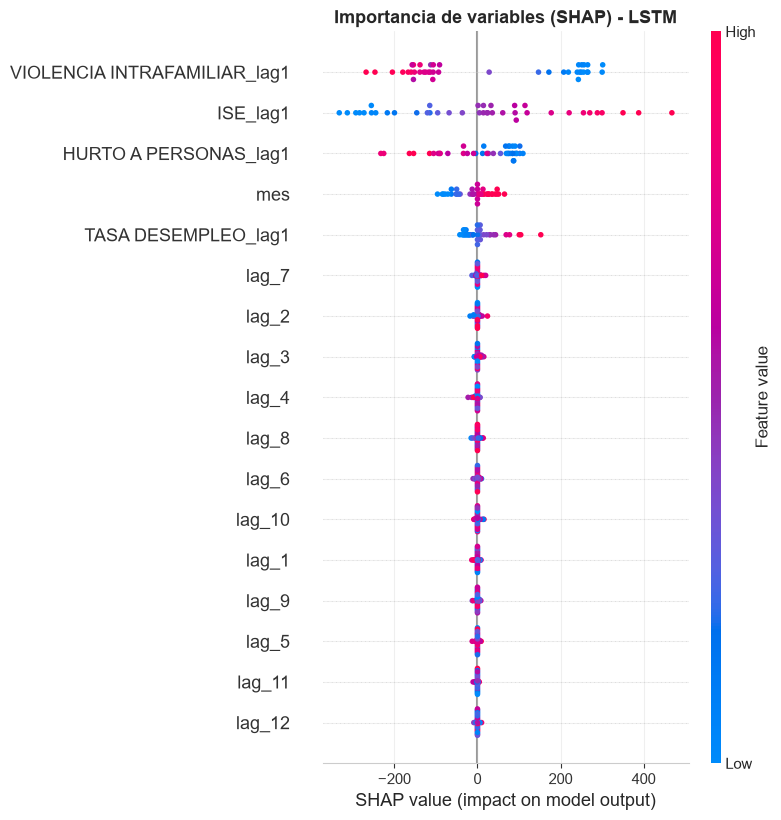

In [67]:

exog_lstm = list(mejor_lstm["exog_vars"])
feature_cols_lstm = mejor_lstm["feature_cols"]
otras_cols_lstm = mejor_lstm["otras_cols"]

X_full_lstm, y_full_sup_lstm, _ = construir_dataset_supervisado(
    wide_hist.loc[:f"{AÑO_FIN}-12-01"], exog_lstm
)
X_seq_full_lstm, X_otras_full_lstm, _ = construir_arrays_secuencia(
    X_full_lstm, feature_cols_lstm, N_LAGS, exog_lstm
)

keras.backend.clear_session()
modelo_final_lstm = construir_modelo_rnn(
    "LSTM", N_LAGS, X_otras_full_lstm.shape[1],
    unidades=mejor_lstm["params"]["unidades"], dropout=mejor_lstm["params"]["dropout"],
    learning_rate=mejor_lstm["params"].get("learning_rate", 1e-3)
)
modelo_final_lstm.fit(
    [X_seq_full_lstm, X_otras_full_lstm], y_full_sup_lstm.values,
    epochs=mejor_lstm["params"].get("epochs", 60),
    batch_size=mejor_lstm["params"].get("batch_size", 8), verbose=0
)

fn_predict_lstm = predict_fn_rnn(modelo_final_lstm, feature_cols_lstm, N_LAGS, otras_cols_lstm)
fondo_lstm = shap.sample(X_full_lstm, min(30, len(X_full_lstm)), random_state=SEED)
muestra_lstm = X_full_lstm.sample(min(40, len(X_full_lstm)), random_state=SEED)

explainer_lstm = shap.KernelExplainer(fn_predict_lstm, fondo_lstm)
shap_values_lstm = explainer_lstm.shap_values(muestra_lstm, nsamples=100)

shap.summary_plot(shap_values_lstm, muestra_lstm, show=False)
plt.title("Importancia de variables (SHAP) - LSTM")
plt.tight_layout()
plt.savefig(RUTA_RESULTADOS / "fig_3_4_lstm_shap.png", dpi=150, bbox_inches="tight")
plt.show()


*Interpretación (SHAP):* al igual que en los modelos de árboles, las variables con mayor dispersión de valores SHAP son las que más influyen en el pronóstico de la red. En modelos recurrentes es esperable que los rezagos recientes de `HOMICIDIOS` (capturados por la rama LSTM/GRU) dominen la importancia, mientras que las variables exógenas aportan ajustes adicionales sobre esa señal autorregresiva de base.

**a. Pronóstico enero-mayo de 2026**

--- Pronóstico incorporando 1 mes(es): Enero 2026 ---
  2026-01: 1371.8 [1149.2 - 1594.4]
--- Pronóstico incorporando 2 mes(es): Febrero 2026 ---
  2026-01: 1371.8 [1149.2 - 1594.4]
  2026-02: 1385.9 [1163.3 - 1608.4]
--- Pronóstico incorporando 3 mes(es): Marzo 2026 ---
  2026-01: 1371.8 [1149.2 - 1594.4]
  2026-02: 1385.9 [1163.3 - 1608.4]
  2026-03: 1399.9 [1177.3 - 1622.5]
--- Pronóstico incorporando 4 mes(es): Abril 2026 ---
  2026-01: 1371.8 [1149.2 - 1594.4]
  2026-02: 1385.9 [1163.3 - 1608.4]
  2026-03: 1399.9 [1177.3 - 1622.5]
  2026-04: 1414.0 [1191.4 - 1636.6]
--- Pronóstico incorporando 5 mes(es): Mayo 2026 ---
  2026-01: 1371.8 [1149.2 - 1594.4]
  2026-02: 1385.9 [1163.3 - 1608.4]
  2026-03: 1399.9 [1177.3 - 1622.5]
  2026-04: 1414.0 [1191.4 - 1636.6]
  2026-05: 1428.0 [1205.4 - 1650.6]


,Modelo,fecha_mensual,pronostico,lim_inf_95,lim_sup_95
0,LSTM,2026-01-01,1371.8,1149.2,1594.4
1,LSTM,2026-02-01,1385.9,1163.3,1608.4
2,LSTM,2026-03-01,1399.9,1177.3,1622.5
3,LSTM,2026-04-01,1414.0,1191.4,1636.6
4,LSTM,2026-05-01,1428.0,1205.4,1650.6


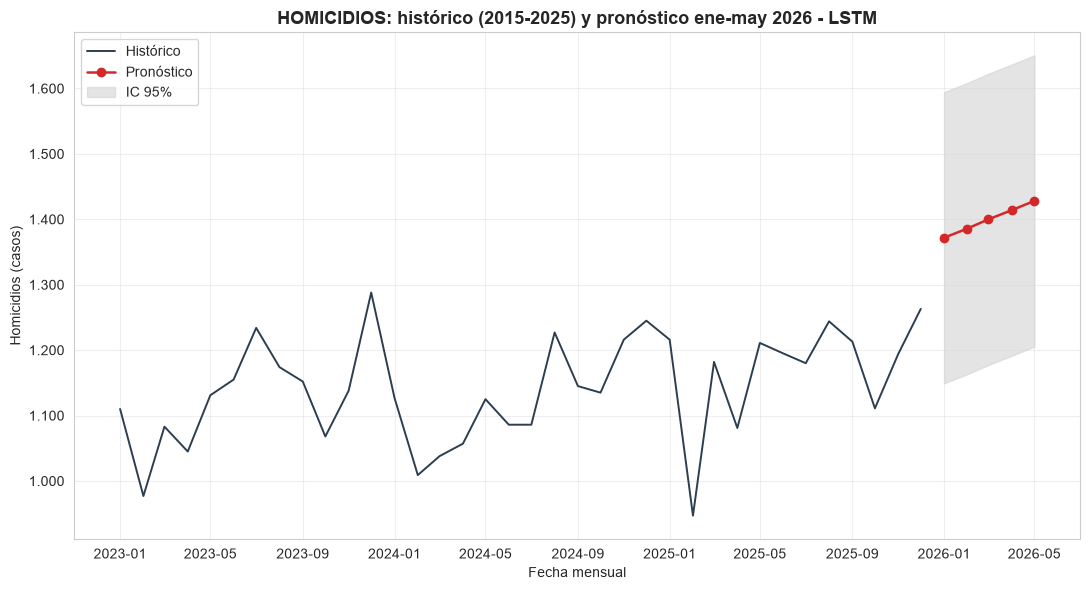

,Modelo,MAE,RMSE,MASE,ME,MAPE,R2
0,LSTM,239.92,243.824,3.177,-239.92,20.834,-33.253


In [68]:

exog_futuro_lstm = preparar_exogenas_futuras(
    wide_hist, exog_lstm, fechas_fc, metodo="ultimo_valor"
) if exog_lstm else pd.DataFrame(index=fechas_fc)

punto_lstm = pronostico_recursivo_ml(
    fn_predict_lstm, wide_hist.loc[:f"{AÑO_FIN}-12-01"], exog_lstm, feature_cols_lstm, N_LAGS,
    fechas_fc, exog_futuro_lstm
)

tabla_fc_lstm, metricas_lstm, lo_lstm, hi_lstm = reportar_modelo_ml(
    "LSTM", punto_lstm, mejor_lstm["std_resid_val"], fechas_fc, y_full,
    guardar_prefijo="fig_3_4_lstm"
)


**b. Métricas de desempeño e interpretación**

*Interpretación:* la lectura de MAE, RMSE, MASE, ME, MAPE y R² es la misma que en los modelos anteriores; su comparación frente a XGBoost/LightGBM/Random Forest permite evaluar si la capacidad de las redes recurrentes para capturar dependencias secuenciales no lineales se traduce en una mejora efectiva del pronóstico fuera de muestra, o si el tamaño reducido de la serie mensual (132 observaciones de entrenamiento) limita su ventaja frente a los modelos de árboles.

In [69]:

resultados_modelos["LSTM"] = {
    "pronostico": tabla_fc_lstm,
    "metricas": metricas_lstm,
    "fechas_fc": fechas_fc,
    "punto_fc": punto_lstm,
    "lo_fc": lo_lstm,
    "hi_fc": hi_lstm,
    "hiperparametros": tabla_hiperparametros_lstm,
}


### 3.5 GRU

**Búsqueda de la mejor combinación de variables exógenas e hiperparámetros**

In [70]:

combos_dl = sorted(set([
    tuple(), tuple(EXOG_CANDIDATAS),
    tuple(mejor_xgb["exog_vars"]), tuple(mejor_lgb["exog_vars"]), tuple(mejor_rf["exog_vars"]),
]), key=len)

PARAM_GRID_GRU = {
    "unidades": [16, 32],
    "dropout": [0.0, 0.2],
    "epochs": [60],
    "batch_size": [8],
    "learning_rate": [0.01],
}

mejor_gru, tabla_busqueda_gru = buscar_mejor_modelo_rnn(
    "GRU", combos_dl, PARAM_GRID_GRU, wide_hist.loc[:f"{AÑO_FIN}-12-01"]
)

print("Mejores variables exógenas:", mejor_gru["exog_vars"])
print("Mejores hiperparámetros:", mejor_gru["params"])
print("RMSE de validación:", round(mejor_gru["rmse_val"], 2))

tabla_busqueda_gru.sort_values("rmse_val")


Mejores variables exógenas: ('HURTO A PERSONAS', 'LESIONES PERSONALES', 'INCAUTACION_KG', 'ISE', 'TASA DESEMPLEO', 'VIOLENCIA INTRAFAMILIAR')
Mejores hiperparámetros: {'batch_size': 8, 'dropout': 0.2, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 32}
RMSE de validación: 141.56


,exog_vars,params,rmse_val,std_resid_val,feature_cols,otras_cols,n_val
19,"(HURTO A PERSONAS, LESIONES PERSONALES, INCAUT...","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60...",141.557972,141.473228,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[HURTO A PERSONAS_lag1, LESIONES PERSONALES_la...",24
12,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60...",166.595917,64.658978,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[HURTO A PERSONAS_lag1, ISE_lag1, TASA DESEMPL...",24
13,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60...",168.711221,105.775116,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[HURTO A PERSONAS_lag1, ISE_lag1, TASA DESEMPL...",24
9,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCI...","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60...",174.824174,124.943964,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[LESIONES PERSONALES_lag1, TASA DESEMPLEO_lag1...",24
11,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCI...","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60...",195.010114,129.297995,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[LESIONES PERSONALES_lag1, TASA DESEMPLEO_lag1...",24
15,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60...",206.445167,101.647319,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[HURTO A PERSONAS_lag1, ISE_lag1, TASA DESEMPL...",24
14,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60...",221.220746,119.634954,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[HURTO A PERSONAS_lag1, ISE_lag1, TASA DESEMPL...",24
8,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCI...","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60...",245.527352,139.124556,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[LESIONES PERSONALES_lag1, TASA DESEMPLEO_lag1...",24
1,(),"{'batch_size': 8, 'dropout': 0.0, 'epochs': 60...",277.608306,256.338746,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...",[mes],24
16,"(HURTO A PERSONAS, LESIONES PERSONALES, INCAUT...","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60...",283.027296,153.216372,"[lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag...","[HURTO A PERSONAS_lag1, LESIONES PERSONALES_la...",24


In [90]:
import pandas as pd
pd.set_option("display.max_colwidth", None)
tabla_busqueda_gru.sort_values("rmse_val").head(10)[["exog_vars", "params", "rmse_val", "std_resid_val", "n_val"]]

,exog_vars,params,rmse_val,std_resid_val,n_val
19,"(HURTO A PERSONAS, LESIONES PERSONALES, INCAUTACION_KG, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 32}",141.557972,141.473228,24
12,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 16}",166.595917,64.658978,24
13,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 32}",168.711221,105.775116,24
9,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 32}",174.824174,124.943964,24
11,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 32}",195.010114,129.297995,24
15,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 32}",206.445167,101.647319,24
14,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.2, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 16}",221.220746,119.634954,24
8,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 16}",245.527352,139.124556,24
1,(),"{'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 32}",277.608306,256.338746,24
16,"(HURTO A PERSONAS, LESIONES PERSONALES, INCAUTACION_KG, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'batch_size': 8, 'dropout': 0.0, 'epochs': 60, 'learning_rate': 0.01, 'unidades': 16}",283.027296,153.216372,24


**Tabla resumen de hiperparámetros seleccionados**

In [71]:

tabla_hiperparametros_gru = pd.DataFrame([{
    "Modelo": "GRU",
    "Variables exógenas seleccionadas": ", ".join(mejor_gru["exog_vars"]) if mejor_gru["exog_vars"] else "(ninguna, solo autorregresivo)",
    **mejor_gru["params"],
    "RMSE validación": round(mejor_gru["rmse_val"], 3),
    "N combinaciones evaluadas": len(tabla_busqueda_gru),
}])
tabla_hiperparametros_gru


,Modelo,Variables exógenas seleccionadas,batch_size,dropout,epochs,learning_rate,unidades,RMSE validación,N combinaciones evaluadas
0,GRU,"HURTO A PERSONAS, LESIONES PERSONALES, INCAUTA...",8,0.2,60,0.01,32,141.558,20


**Ajuste del modelo final (2015-2025) y gráfico SHAP**

> El cálculo de SHAP para redes recurrentes usa `KernelExplainer` sobre una muestra reducida de fondo, dado que es agnóstico al tipo de modelo (a diferencia de `TreeExplainer`); por eso puede tardar más que en los modelos de árboles.

  0%|          | 0/40 [00:00<?, ?it/s]

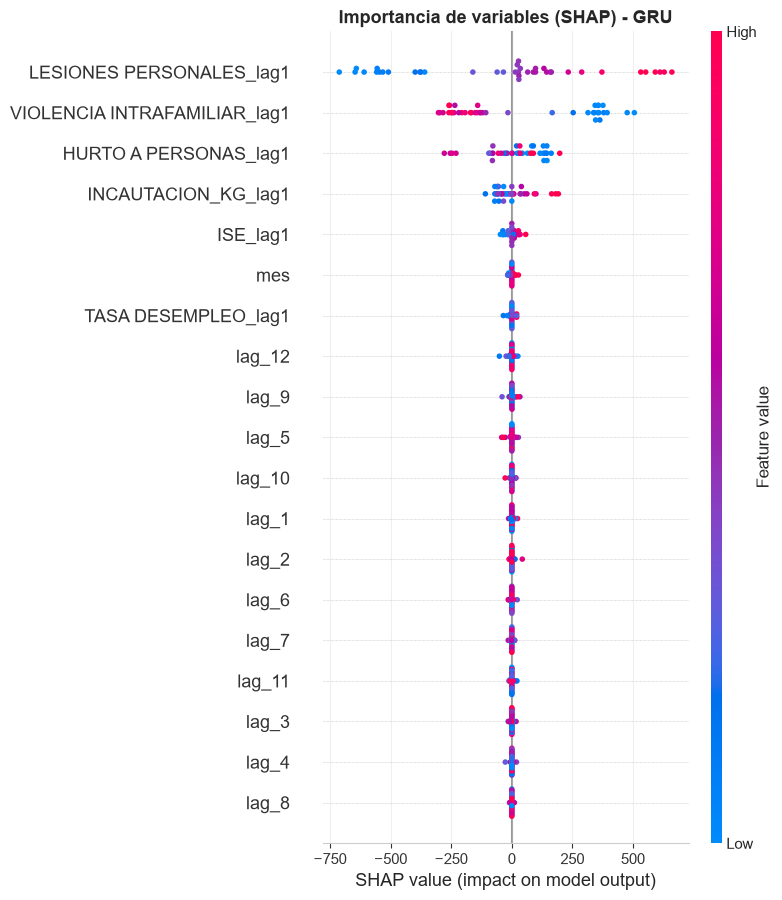

In [72]:

exog_gru = list(mejor_gru["exog_vars"])
feature_cols_gru = mejor_gru["feature_cols"]
otras_cols_gru = mejor_gru["otras_cols"]

X_full_gru, y_full_sup_gru, _ = construir_dataset_supervisado(
    wide_hist.loc[:f"{AÑO_FIN}-12-01"], exog_gru
)
X_seq_full_gru, X_otras_full_gru, _ = construir_arrays_secuencia(
    X_full_gru, feature_cols_gru, N_LAGS, exog_gru
)

keras.backend.clear_session()
modelo_final_gru = construir_modelo_rnn(
    "GRU", N_LAGS, X_otras_full_gru.shape[1],
    unidades=mejor_gru["params"]["unidades"], dropout=mejor_gru["params"]["dropout"],
    learning_rate=mejor_gru["params"].get("learning_rate", 1e-3)
)
modelo_final_gru.fit(
    [X_seq_full_gru, X_otras_full_gru], y_full_sup_gru.values,
    epochs=mejor_gru["params"].get("epochs", 60),
    batch_size=mejor_gru["params"].get("batch_size", 8), verbose=0
)

fn_predict_gru = predict_fn_rnn(modelo_final_gru, feature_cols_gru, N_LAGS, otras_cols_gru)
fondo_gru = shap.sample(X_full_gru, min(30, len(X_full_gru)), random_state=SEED)
muestra_gru = X_full_gru.sample(min(40, len(X_full_gru)), random_state=SEED)

explainer_gru = shap.KernelExplainer(fn_predict_gru, fondo_gru)
shap_values_gru = explainer_gru.shap_values(muestra_gru, nsamples=100)

shap.summary_plot(shap_values_gru, muestra_gru, show=False)
plt.title("Importancia de variables (SHAP) - GRU")
plt.tight_layout()
plt.savefig(RUTA_RESULTADOS / "fig_3_5_gru_shap.png", dpi=150, bbox_inches="tight")
plt.show()


*Interpretación (SHAP):* al igual que en los modelos de árboles, las variables con mayor dispersión de valores SHAP son las que más influyen en el pronóstico de la red. En modelos recurrentes es esperable que los rezagos recientes de `HOMICIDIOS` (capturados por la rama LSTM/GRU) dominen la importancia, mientras que las variables exógenas aportan ajustes adicionales sobre esa señal autorregresiva de base.

**a. Pronóstico enero-mayo de 2026**

--- Pronóstico incorporando 1 mes(es): Enero 2026 ---
  2026-01: 861.2 [583.9 - 1138.4]
--- Pronóstico incorporando 2 mes(es): Febrero 2026 ---
  2026-01: 861.2 [583.9 - 1138.4]
  2026-02: 863.0 [585.7 - 1140.3]
--- Pronóstico incorporando 3 mes(es): Marzo 2026 ---
  2026-01: 861.2 [583.9 - 1138.4]
  2026-02: 863.0 [585.7 - 1140.3]
  2026-03: 864.9 [587.6 - 1142.1]
--- Pronóstico incorporando 4 mes(es): Abril 2026 ---
  2026-01: 861.2 [583.9 - 1138.4]
  2026-02: 863.0 [585.7 - 1140.3]
  2026-03: 864.9 [587.6 - 1142.1]
  2026-04: 866.7 [589.4 - 1144.0]
--- Pronóstico incorporando 5 mes(es): Mayo 2026 ---
  2026-01: 861.2 [583.9 - 1138.4]
  2026-02: 863.0 [585.7 - 1140.3]
  2026-03: 864.9 [587.6 - 1142.1]
  2026-04: 866.7 [589.4 - 1144.0]
  2026-05: 868.6 [591.3 - 1145.8]


,Modelo,fecha_mensual,pronostico,lim_inf_95,lim_sup_95
0,GRU,2026-01-01,861.2,583.9,1138.4
1,GRU,2026-02-01,863.0,585.7,1140.3
2,GRU,2026-03-01,864.9,587.6,1142.1
3,GRU,2026-04-01,866.7,589.4,1144.0
4,GRU,2026-05-01,868.6,591.3,1145.8


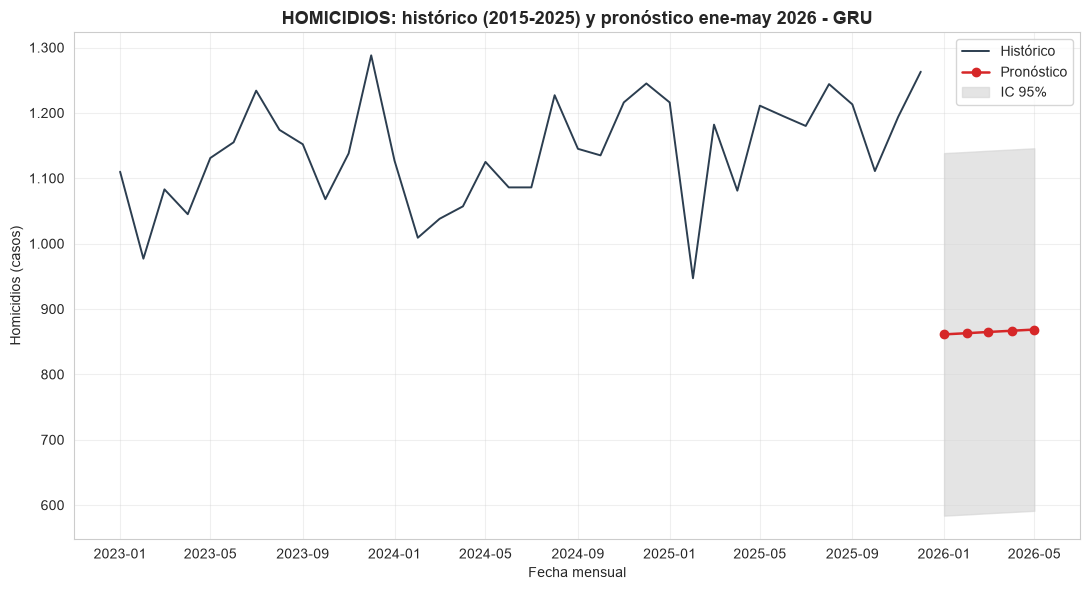

,Modelo,MAE,RMSE,MASE,ME,MAPE,R2
0,GRU,295.141,298.025,3.908,295.141,25.345,-50.175


In [73]:

exog_futuro_gru = preparar_exogenas_futuras(
    wide_hist, exog_gru, fechas_fc, metodo="ultimo_valor"
) if exog_gru else pd.DataFrame(index=fechas_fc)

punto_gru = pronostico_recursivo_ml(
    fn_predict_gru, wide_hist.loc[:f"{AÑO_FIN}-12-01"], exog_gru, feature_cols_gru, N_LAGS,
    fechas_fc, exog_futuro_gru
)

tabla_fc_gru, metricas_gru, lo_gru, hi_gru = reportar_modelo_ml(
    "GRU", punto_gru, mejor_gru["std_resid_val"], fechas_fc, y_full,
    guardar_prefijo="fig_3_5_gru"
)


**b. Métricas de desempeño e interpretación**

*Interpretación:* la lectura de MAE, RMSE, MASE, ME, MAPE y R² es la misma que en los modelos anteriores; su comparación frente a XGBoost/LightGBM/Random Forest permite evaluar si la capacidad de las redes recurrentes para capturar dependencias secuenciales no lineales se traduce en una mejora efectiva del pronóstico fuera de muestra, o si el tamaño reducido de la serie mensual (132 observaciones de entrenamiento) limita su ventaja frente a los modelos de árboles.

In [74]:

resultados_modelos["GRU"] = {
    "pronostico": tabla_fc_gru,
    "metricas": metricas_gru,
    "fechas_fc": fechas_fc,
    "punto_fc": punto_gru,
    "lo_fc": lo_gru,
    "hi_fc": hi_gru,
    "hiperparametros": tabla_hiperparametros_gru,
}


### 3.6 Prophet

Prophet es un modelo aditivo (tendencia + estacionalidad + regresores exógenos) que, a diferencia de los modelos anteriores, entrega intervalos de predicción nativos y no requiere ingeniería manual de rezagos. Por su naturaleza aditiva y lineal en los regresores, **SHAP no aplica de la misma manera** que en modelos de árboles o redes: en su lugar se reporta la **importancia de las variables exógenas a partir de sus coeficientes** (`regressor_coefficients`), que cuantifican el efecto marginal de cada regresor sobre el pronóstico — el análogo más directo y honesto a una medida de importancia en un modelo aditivo lineal como Prophet.

> ⚠️ Al igual que en los demás modelos con exógenas, para el horizonte de pronóstico (enero-mayo 2026) se usa el método de persistencia ("último valor observado") para las variables exógenas futuras.

**Búsqueda de la mejor combinación de variables exógenas e hiperparámetros**

In [75]:

PARAM_GRID_PROPHET = {
    "changepoint_prior_scale": [0.01, 0.1, 0.5],
    "seasonality_prior_scale": [1.0, 10.0],
}

# Igual que en LSTM/GRU, se usa un subconjunto informado de combinaciones de exógenas
# (evaluar las 64 combinaciones completas resulta poco práctico con Prophet + grilla de hiperparámetros)
combos_prophet = sorted(set([
    tuple(), tuple(EXOG_CANDIDATAS),
    tuple(mejor_xgb["exog_vars"]), tuple(mejor_lgb["exog_vars"]),
    tuple(mejor_rf["exog_vars"]), tuple(mejor_lstm["exog_vars"]),
]), key=len)


def preparar_df_prophet(wide_df, exog_vars):
    df = wide_df[["HOMICIDIOS"] + list(exog_vars)].reset_index()
    df.columns = ["ds", "y"] + list(exog_vars)
    return df.dropna()


filas_prophet = []
df_hist_prophet_completo = wide_hist.loc[:f"{AÑO_FIN}-12-01"]

for exog_vars in combos_prophet:
    df_p = preparar_df_prophet(df_hist_prophet_completo, exog_vars)
    df_tr = df_p[df_p["ds"] < FECHA_CORTE_VAL]
    df_val = df_p[df_p["ds"] >= FECHA_CORTE_VAL]
    if len(df_val) == 0 or len(df_tr) == 0:
        continue

    for params in ParameterGrid(PARAM_GRID_PROPHET):
        modelo_p = Prophet(
            yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
            changepoint_prior_scale=params["changepoint_prior_scale"],
            seasonality_prior_scale=params["seasonality_prior_scale"],
        )
        for var in exog_vars:
            modelo_p.add_regressor(var)
        modelo_p.fit(df_tr)

        pred_val = modelo_p.predict(df_val[["ds"] + list(exog_vars)])["yhat"].values
        rmse_val = float(np.sqrt(mean_squared_error(df_val["y"].values, pred_val)))
        filas_prophet.append({
            "exog_vars": exog_vars, "params": params, "rmse_val": rmse_val,
            "n_val": len(df_val)
        })

tabla_busqueda_prophet = pd.DataFrame(filas_prophet)
mejor_prophet = tabla_busqueda_prophet.loc[tabla_busqueda_prophet["rmse_val"].idxmin()].to_dict()

print("Mejores variables exógenas:", mejor_prophet["exog_vars"])
print("Mejores hiperparámetros:", mejor_prophet["params"])
print("RMSE de validación:", round(mejor_prophet["rmse_val"], 2))

tabla_busqueda_prophet.sort_values("rmse_val")


14:50:14 - cmdstanpy - INFO - Chain [1] start processing
14:50:14 - cmdstanpy - INFO - Chain [1] done processing
14:50:14 - cmdstanpy - INFO - Chain [1] start processing
14:50:14 - cmdstanpy - INFO - Chain [1] done processing
14:50:14 - cmdstanpy - INFO - Chain [1] start processing
14:50:14 - cmdstanpy - INFO - Chain [1] done processing
14:50:14 - cmdstanpy - INFO - Chain [1] start processing
14:50:14 - cmdstanpy - INFO - Chain [1] done processing
14:50:14 - cmdstanpy - INFO - Chain [1] start processing
14:50:15 - cmdstanpy - INFO - Chain [1] done processing
14:50:15 - cmdstanpy - INFO - Chain [1] start processing
14:50:15 - cmdstanpy - INFO - Chain [1] done processing
14:50:15 - cmdstanpy - INFO - Chain [1] start processing
14:50:15 - cmdstanpy - INFO - Chain [1] done processing
14:50:15 - cmdstanpy - INFO - Chain [1] start processing
14:50:15 - cmdstanpy - INFO - Chain [1] done processing
14:50:15 - cmdstanpy - INFO - Chain [1] start processing
14:50:15 - cmdstanpy - INFO - Chain [1]

Mejores variables exógenas: ('HURTO A PERSONAS', 'LESIONES PERSONALES', 'INCAUTACION_KG', 'ISE', 'TASA DESEMPLEO', 'VIOLENCIA INTRAFAMILIAR')
Mejores hiperparámetros: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}
RMSE de validación: 53.88


,exog_vars,params,rmse_val,n_val
27,"(HURTO A PERSONAS, LESIONES PERSONALES, INCAUT...","{'changepoint_prior_scale': 0.1, 'seasonality_...",53.882863,24
26,"(HURTO A PERSONAS, LESIONES PERSONALES, INCAUT...","{'changepoint_prior_scale': 0.1, 'seasonality_...",54.082886,24
20,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'changepoint_prior_scale': 0.1, 'seasonality_...",58.431756,24
21,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'changepoint_prior_scale': 0.1, 'seasonality_...",58.715520,24
15,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCI...","{'changepoint_prior_scale': 0.1, 'seasonality_...",59.034956,24
14,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCI...","{'changepoint_prior_scale': 0.1, 'seasonality_...",59.299932,24
3,(),"{'changepoint_prior_scale': 0.1, 'seasonality_...",60.189339,24
2,(),"{'changepoint_prior_scale': 0.1, 'seasonality_...",60.311164,24
9,"(INCAUTACION_KG, ISE, VIOLENCIA INTRAFAMILIAR)","{'changepoint_prior_scale': 0.1, 'seasonality_...",61.070446,24
23,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLEN...","{'changepoint_prior_scale': 0.5, 'seasonality_...",61.619547,24


In [92]:
import pandas as pd
pd.set_option("display.max_colwidth", None)
tabla_busqueda_prophet.sort_values("rmse_val").head(10)[["exog_vars", "params", "rmse_val", "n_val"]]

,exog_vars,params,rmse_val,n_val
27,"(HURTO A PERSONAS, LESIONES PERSONALES, INCAUTACION_KG, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}",53.882863,24
26,"(HURTO A PERSONAS, LESIONES PERSONALES, INCAUTACION_KG, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0}",54.082886,24
20,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0}",58.431756,24
21,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}",58.715520,24
15,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}",59.034956,24
14,"(LESIONES PERSONALES, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0}",59.299932,24
3,(),"{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}",60.189339,24
2,(),"{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0}",60.311164,24
9,"(INCAUTACION_KG, ISE, VIOLENCIA INTRAFAMILIAR)","{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}",61.070446,24
23,"(HURTO A PERSONAS, ISE, TASA DESEMPLEO, VIOLENCIA INTRAFAMILIAR)","{'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0}",61.619547,24


**Tabla resumen de hiperparámetros seleccionados**

In [76]:

tabla_hiperparametros_prophet = pd.DataFrame([{
    "Modelo": "Prophet",
    "Variables exógenas seleccionadas": ", ".join(mejor_prophet["exog_vars"]) if mejor_prophet["exog_vars"] else "(ninguna, solo tendencia + estacionalidad)",
    **mejor_prophet["params"],
    "RMSE validación": round(mejor_prophet["rmse_val"], 3),
    "N combinaciones evaluadas": len(tabla_busqueda_prophet),
}])
tabla_hiperparametros_prophet


,Modelo,Variables exógenas seleccionadas,changepoint_prior_scale,seasonality_prior_scale,RMSE validación,N combinaciones evaluadas
0,Prophet,"HURTO A PERSONAS, LESIONES PERSONALES, INCAUTA...",0.1,10.0,53.883,30


**Ajuste del modelo final (2015-2025) e importancia de variables**

14:50:19 - cmdstanpy - INFO - Chain [1] start processing
14:50:19 - cmdstanpy - INFO - Chain [1] done processing


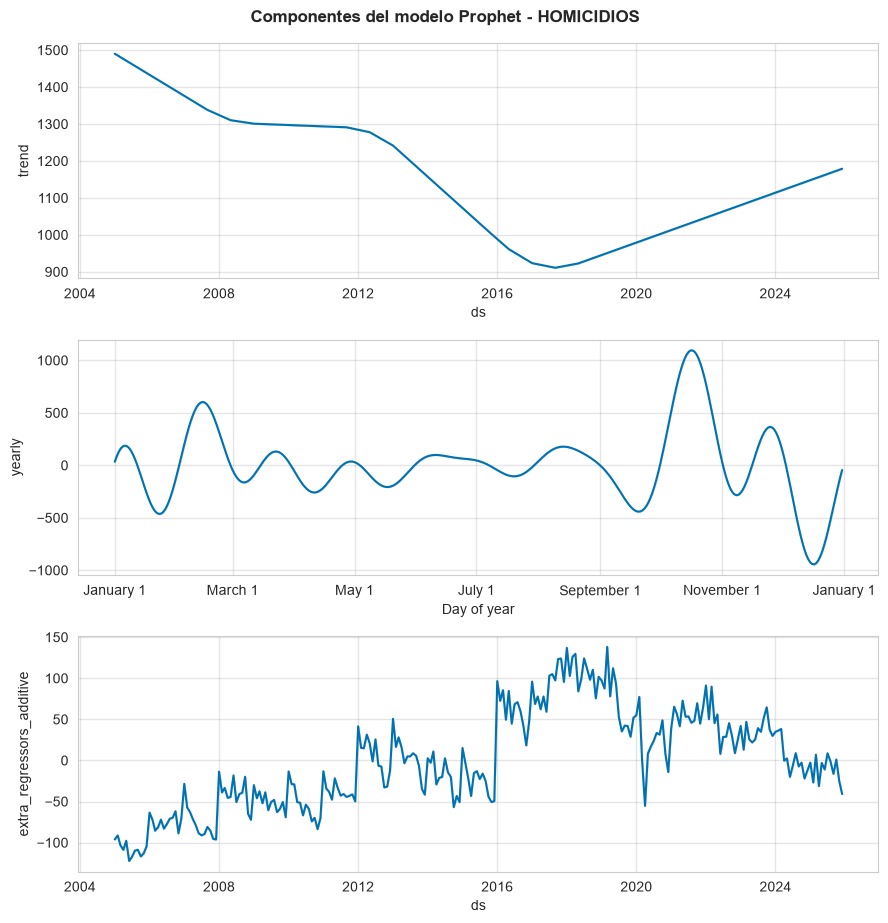

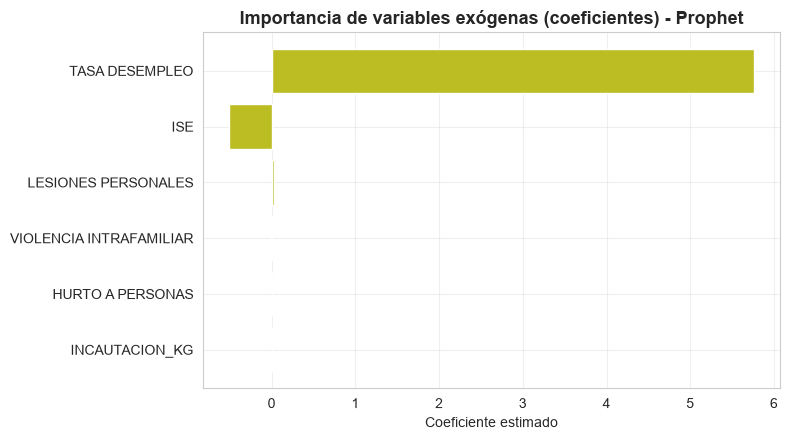

,regressor,regressor_mode,center,coef_lower,coef,coef_upper
0,HURTO A PERSONAS,additive,13955.460317,0.001788,0.001788,0.001788
1,LESIONES PERSONALES,additive,7044.738095,0.027095,0.027095,0.027095
2,INCAUTACION_KG,additive,40870.402063,0.000854,0.000854,0.000854
3,ISE,additive,96.375397,-0.504869,-0.504869,-0.504869
4,TASA DESEMPLEO,additive,11.047302,5.758552,5.758552,5.758552
5,VIOLENCIA INTRAFAMILIAR,additive,5993.551587,-0.007100,-0.007100,-0.007100


In [77]:

from prophet.utilities import regressor_coefficients

exog_prophet = list(mejor_prophet["exog_vars"])
df_full_prophet = preparar_df_prophet(df_hist_prophet_completo, exog_prophet)

modelo_final_prophet = Prophet(
    yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
    changepoint_prior_scale=mejor_prophet["params"]["changepoint_prior_scale"],
    seasonality_prior_scale=mejor_prophet["params"]["seasonality_prior_scale"],
    interval_width=0.95,
)
for var in exog_prophet:
    modelo_final_prophet.add_regressor(var)
modelo_final_prophet.fit(df_full_prophet)

fig_comp = modelo_final_prophet.plot_components(
    modelo_final_prophet.predict(df_full_prophet)
)
fig_comp.suptitle("Componentes del modelo Prophet - HOMICIDIOS", y=1.02, fontweight="bold")
plt.savefig(RUTA_RESULTADOS / "fig_3_6_prophet_componentes.png", dpi=150, bbox_inches="tight")
plt.show()

if exog_prophet:
    coefs_prophet = regressor_coefficients(modelo_final_prophet)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    coefs_ord = coefs_prophet.reindex(coefs_prophet["coef"].abs().sort_values().index)
    ax.barh(coefs_ord["regressor"], coefs_ord["coef"], color="#bcbd22")
    ax.set_title("Importancia de variables exógenas (coeficientes) - Prophet")
    ax.set_xlabel("Coeficiente estimado")
    fig.tight_layout()
    plt.savefig(RUTA_RESULTADOS / "fig_3_6_prophet_coeficientes.png", dpi=150)
    plt.show()
    display(coefs_prophet)
else:
    print("El mejor modelo Prophet no seleccionó variables exógenas: no hay coeficientes que mostrar.")


*Interpretación (importancia de variables):* el signo y la magnitud de cada coeficiente indican, respectivamente, si un aumento en la variable exógena se asocia con un incremento o una disminución del número de homicidios pronosticado, y qué tan grande es ese efecto marginal dentro de la estructura aditiva del modelo. A diferencia de los valores SHAP, estos coeficientes son globales (no varían observación a observación), lo cual es consistente con la naturaleza lineal de los regresores en Prophet.

**a. Pronóstico enero-mayo de 2026**

In [78]:

exog_futuro_prophet = preparar_exogenas_futuras(
    wide_hist, exog_prophet, fechas_fc, metodo="ultimo_valor"
) if exog_prophet else pd.DataFrame(index=fechas_fc)

df_futuro_prophet = pd.DataFrame({"ds": fechas_fc})
for var in exog_prophet:
    df_futuro_prophet[var] = exog_futuro_prophet[var].values

pred_prophet = modelo_final_prophet.predict(df_futuro_prophet)
punto_prophet = pred_prophet["yhat"].values
lo_prophet = pred_prophet["yhat_lower"].values
hi_prophet = pred_prophet["yhat_upper"].values

for n_meses in range(1, HORIZONTE_PRONOSTICO + 1):
    print(f"--- Pronóstico incorporando {n_meses} mes(es): {formato_mes_es(fechas_fc[n_meses-1])} ---")
    for i in range(n_meses):
        print(f"  {fechas_fc[i].strftime('%Y-%m')}: {punto_prophet[i]:.1f} "
              f"[{lo_prophet[i]:.1f} - {hi_prophet[i]:.1f}]")

tabla_fc_prophet = tabla_pronostico(fechas_fc, punto_prophet, lo_prophet, hi_prophet, "Prophet")
tabla_fc_prophet


--- Pronóstico incorporando 1 mes(es): Enero 2026 ---
  2026-01: 1160.2 [1035.0 - 1298.6]
--- Pronóstico incorporando 2 mes(es): Febrero 2026 ---
  2026-01: 1160.2 [1035.0 - 1298.6]
  2026-02: 1031.1 [892.2 - 1157.4]
--- Pronóstico incorporando 3 mes(es): Marzo 2026 ---
  2026-01: 1160.2 [1035.0 - 1298.6]
  2026-02: 1031.1 [892.2 - 1157.4]
  2026-03: 1109.5 [982.3 - 1245.2]
--- Pronóstico incorporando 4 mes(es): Abril 2026 ---
  2026-01: 1160.2 [1035.0 - 1298.6]
  2026-02: 1031.1 [892.2 - 1157.4]
  2026-03: 1109.5 [982.3 - 1245.2]
  2026-04: 1097.3 [964.7 - 1224.2]
--- Pronóstico incorporando 5 mes(es): Mayo 2026 ---
  2026-01: 1160.2 [1035.0 - 1298.6]
  2026-02: 1031.1 [892.2 - 1157.4]
  2026-03: 1109.5 [982.3 - 1245.2]
  2026-04: 1097.3 [964.7 - 1224.2]
  2026-05: 1183.7 [1050.5 - 1312.6]


,Modelo,fecha_mensual,pronostico,lim_inf_95,lim_sup_95
0,Prophet,2026-01-01,1160.2,1035.0,1298.6
1,Prophet,2026-02-01,1031.1,892.2,1157.4
2,Prophet,2026-03-01,1109.5,982.3,1245.2
3,Prophet,2026-04-01,1097.3,964.7,1224.2
4,Prophet,2026-05-01,1183.7,1050.5,1312.6


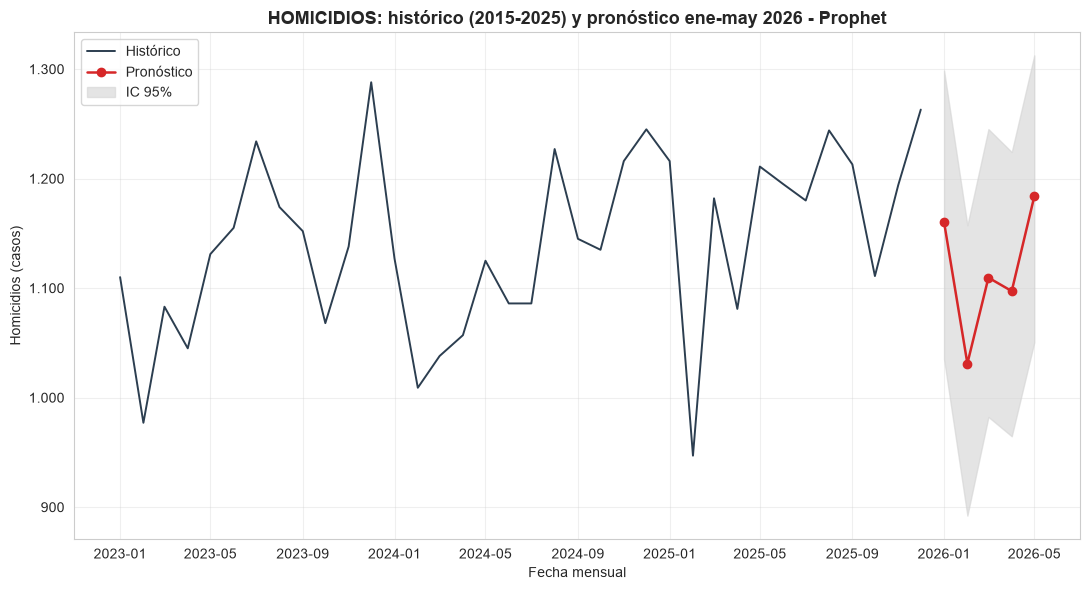

In [79]:

fig = graficar_pronostico(
    y_full, fechas_fc, punto_prophet, lo_prophet, hi_prophet,
    titulo="HOMICIDIOS: histórico (2015-2025) y pronóstico ene-may 2026 - Prophet"
)
plt.savefig(RUTA_RESULTADOS / "fig_3_6_prophet_pronostico.png", dpi=150)
plt.show()


**b. Métricas de desempeño e interpretación**

In [93]:

metricas_prophet = calcular_metricas(y_test_2026.values, punto_prophet[:n_eval], y_train_hist=y_full.values)
tabla_met_prophet = tabla_metricas(metricas_prophet, "Prophet")
tabla_met_prophet


,Modelo,MAE,RMSE,MASE,ME,MAPE,R2
0,Prophet,43.633,48.263,0.578,43.633,3.792,-0.342


*Interpretación:* al ser Prophet un modelo diseñado para descomponer explícitamente tendencia y estacionalidad, sus métricas de error permiten evaluar si esa estructura aditiva —más rígida que la de los modelos de árboles o redes, pero más interpretable— captura adecuadamente el comportamiento de los homicidios frente a los meses efectivamente observados en 2026, en comparación con los demás modelos estadísticos y de ML de este documento.

In [81]:

resultados_modelos["Prophet"] = {
    "pronostico": tabla_fc_prophet,
    "metricas": metricas_prophet,
    "fechas_fc": fechas_fc,
    "punto_fc": punto_prophet,
    "lo_fc": lo_prophet,
    "hi_fc": hi_prophet,
    "hiperparametros": tabla_hiperparametros_prophet,
}


## 4. Comparación de modelos estadísticos y de Machine Learning

Se consolidan los resultados de los 3 modelos estadísticos (Sección 2) y los 6 modelos de Machine Learning (Sección 3), todos evaluados contra el mismo conjunto de prueba real: `ts_mensual_2026.csv` (homicidios observados de enero a mayo de 2026).

### 4.1 Tabla resumen de pronósticos y métricas

In [82]:

TODOS_LOS_MODELOS = [
    nombre_sarima, nombre_sarimax, nombre_var,
    "XGBoost", "LightGBM", "Random Forest", "LSTM", "GRU", "Prophet",
]

filas_comparacion = []
for nombre in TODOS_LOS_MODELOS:
    r = resultados_modelos[nombre]
    supuestos = r.get("supuestos")
    filas_comparacion.append({
        "Modelo": nombre,
        **{f"Pronóstico {f.strftime('%Y-%m')}": round(v, 1) for f, v in zip(r["fechas_fc"], r["punto_fc"])},
        "MAE": r["metricas"]["MAE"], "RMSE": r["metricas"]["RMSE"],
        "MASE": r["metricas"]["MASE"], "ME": r["metricas"]["ME"],
        "MAPE": r["metricas"]["MAPE"], "R2": r["metricas"]["R2"],
        "Independencia": ("SÍ" if supuestos["independencia_ok"] else "NO") if supuestos else "N/A",
        "Normalidad": ("SÍ" if supuestos["normalidad_ok"] else "NO") if supuestos else "N/A",
        "Homocedasticidad": ("SÍ" if supuestos["homocedasticidad_ok"] else "NO") if supuestos else "N/A",
    })

tabla_comparacion_final = pd.DataFrame(filas_comparacion).round(2)
tabla_comparacion_final = tabla_comparacion_final.sort_values("RMSE")
tabla_comparacion_final


,Modelo,Pronóstico 2026-01,Pronóstico 2026-02,Pronóstico 2026-03,Pronóstico 2026-04,Pronóstico 2026-05,MAE,RMSE,MASE,ME,MAPE,R2,Independencia,Normalidad,Homocedasticidad
4,LightGBM,1183.2,1074.6,1197.3,1144.3,1193.9,14.62,16.61,0.19,1.35,1.25,0.84,N/A,N/A,N/A
1,"SARIMAX(2, 0, 1)(0, 1, 2, 12)",1219.3,1040.8,1134.9,1114.9,1211.1,31.55,33.16,0.42,15.79,2.75,0.37,NO,NO,NO
5,Random Forest,1160.7,1089.1,1153.9,1102.8,1149.2,31.30,35.84,0.41,28.88,2.66,0.26,N/A,N/A,N/A
2,VAR HOMICIDIOS~ISE,1175.3,1094.4,1114.5,1104.1,1205.6,32.81,37.36,0.43,21.22,2.81,0.20,SÍ,NO,NO
0,"SARIMA(2, 0, 1)(0, 1, 2, 12)",1179.9,1012.5,1133.2,1090.5,1197.3,41.04,47.41,0.54,37.33,3.60,-0.30,NO,NO,NO
8,Prophet,1160.2,1031.1,1109.5,1097.3,1183.7,43.63,48.26,0.58,43.63,3.79,-0.34,N/A,N/A,N/A
3,XGBoost,1146.0,1055.2,1120.7,1084.0,1127.7,53.28,55.26,0.71,53.28,4.56,-0.76,N/A,N/A,N/A
6,LSTM,1371.8,1385.9,1399.9,1414.0,1428.0,239.92,243.82,3.18,-239.92,20.83,-33.25,N/A,N/A,N/A
7,GRU,861.2,863.0,864.9,866.7,868.6,295.14,298.03,3.91,295.14,25.34,-50.17,N/A,N/A,N/A


*Nota:* la evaluación de supuestos (independencia, normalidad, homocedasticidad) solo es aplicable, en sentido estricto, a los modelos estadísticos (SARIMA, SARIMAX, VAR), que modelan explícitamente los residuales bajo una estructura probabilística. Para los modelos de Machine Learning se reporta "N/A" en esas columnas.

### 4.2 Gráfico comparativo: histórico y pronóstico ene-may 2026, todos los modelos

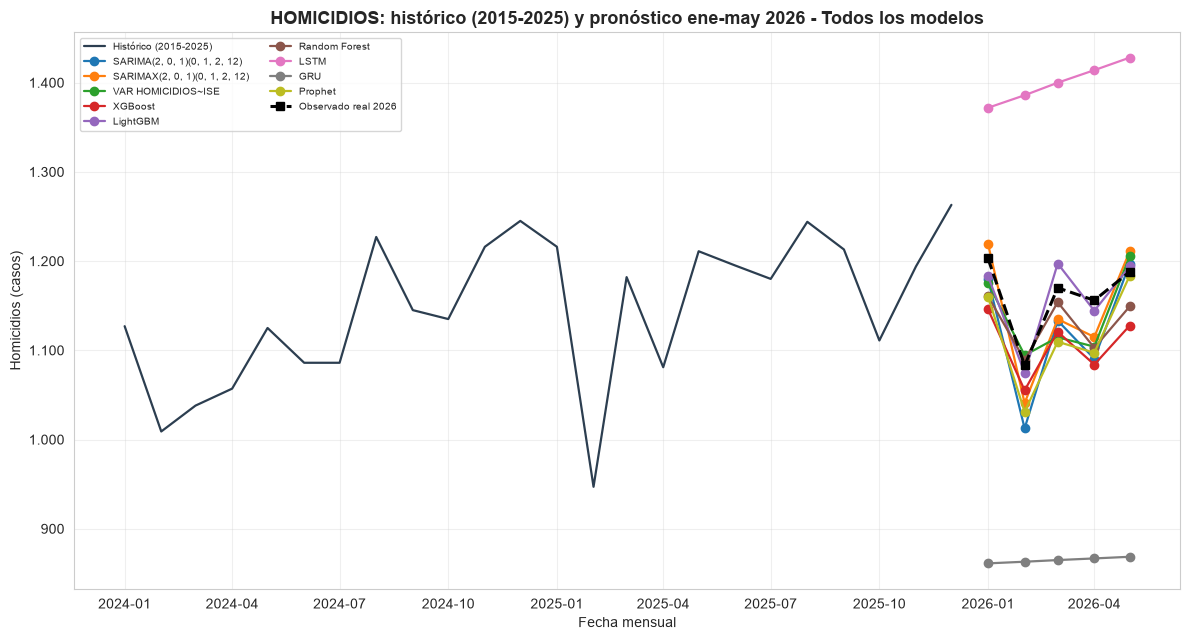

In [83]:

dict_pronosticos_todos = {
    nombre: (resultados_modelos[nombre]["fechas_fc"], resultados_modelos[nombre]["punto_fc"])
    for nombre in TODOS_LOS_MODELOS
}

fig = graficar_comparacion_modelos(
    y_full, dict_pronosticos_todos,
    titulo="HOMICIDIOS: histórico (2015-2025) y pronóstico ene-may 2026 - Todos los modelos",
    n_meses_hist=24
)
# Se añade también el valor observado real de 2026 para referencia visual
ax = fig.axes[0]
ax.plot(y_test_2026.index, y_test_2026.values, color="black", linewidth=2.2,
        linestyle="--", marker="s", label="Observado real 2026")
ax.legend(loc="best", fontsize=7.5, ncol=2)
plt.savefig(RUTA_RESULTADOS / "fig_4_2_comparacion_todos_los_modelos.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.3 Ranking de modelos por desempeño

In [84]:

ranking = tabla_comparacion_final[["Modelo", "MAE", "RMSE", "MASE", "MAPE", "R2"]].reset_index(drop=True)
ranking.index = ranking.index + 1
ranking.index.name = "Ranking (por RMSE)"
ranking


,Modelo,MAE,RMSE,MASE,MAPE,R2
Ranking (por RMSE),,,,,,
1,LightGBM,14.62,16.61,0.19,1.25,0.84
2,"SARIMAX(2, 0, 1)(0, 1, 2, 12)",31.55,33.16,0.42,2.75,0.37
3,Random Forest,31.30,35.84,0.41,2.66,0.26
4,VAR HOMICIDIOS~ISE,32.81,37.36,0.43,2.81,0.20
5,"SARIMA(2, 0, 1)(0, 1, 2, 12)",41.04,47.41,0.54,3.60,-0.30
6,Prophet,43.63,48.26,0.58,3.79,-0.34
7,XGBoost,53.28,55.26,0.71,4.56,-0.76
8,LSTM,239.92,243.82,3.18,20.83,-33.25
9,GRU,295.14,298.03,3.91,25.34,-50.17


*Interpretación general:* la tabla y el ranking anteriores permiten identificar, de forma directa, qué modelo —estadístico o de Machine Learning— logró el menor error de pronóstico frente a los homicidios efectivamente observados entre enero y mayo de 2026. Es importante leer estos resultados considerando explícitamente las limitaciones señaladas a lo largo del notebook: (i) el uso de persistencia para proyectar variables exógenas futuras en los modelos multivariados, (ii) el tamaño reducido del conjunto de prueba (5 meses), que hace que el R² y otras métricas relativas sean poco estables, y (iii) las grillas de hiperparámetros moderadas usadas en los modelos de ML por razones de tiempo de cómputo. Para la versión final de la tesis se recomienda documentar estas decisiones metodológicas junto con los resultados de esta sección.

### 4.4 Exportar resultados consolidados

In [85]:

tabla_comparacion_final.to_csv(RUTA_RESULTADOS / "tabla_comparacion_final_modelos.csv", index=False)

with pd.ExcelWriter(RUTA_RESULTADOS / "resultados_pronosticos_2026.xlsx") as writer:
    tabla_comparacion_final.to_excel(writer, sheet_name="Comparacion_final", index=False)
    for nombre in TODOS_LOS_MODELOS:
        hoja = nombre.replace("/", "-")[:31]
        resultados_modelos[nombre]["pronostico"].to_excel(writer, sheet_name=hoja, index=False)

print("Resultados exportados a:", RUTA_RESULTADOS)


Resultados exportados a: C:\Users\ASUS\OneDrive\Desktop\Maestria en Ciencia de datos\Monografia maestria\TS_model\Resultados


---
## Exportar este notebook a HTML

Para generar el archivo HTML solicitado con todos los cuadros, gráficos y explicaciones, ejecuta en una terminal (con el entorno `.venv` activado) **después** de correr todas las celdas de este notebook:

```bash
jupyter nbconvert --to html --output "Comparacion_Modelos_Homicidios.html" ^
  --output-dir "C:\Users\ASUS\OneDrive\Desktop\Maestria en Ciencia de datos\Monografia maestria\TS_model\Resultados" ^
  "Comparacion_Modelos_Homicidios.ipynb"
```

(En PowerShell, reemplaza el símbolo de continuación de línea `^` por el backtick `` ` ``, o escribe el comando en una sola línea.)